In [1]:
#All libraries import here
import torch
import torch.nn as nn
import torch.optim as optim
import requests
import json
import pandas as pd
import datetime as dt
import seaborn as sns
import time
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import matplotlib.pyplot as plt
import ray
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import copy
from ray import tune
from ray.tune import CLIReporter
from ray.tune.schedulers import ASHAScheduler
from sklearn.model_selection import train_test_split
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from scipy.stats import shapiro, normaltest, jarque_bera
from hurst import compute_Hc
from functools import partial
import statsmodels.api as sm
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from scipy.stats import normaltest
import optuna
from optuna.samplers import TPESampler
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import random
import time
from scipy.optimize import curve_fit
from scipy.special import expit

import matplotlib.dates as mdates
from matplotlib.patches import Patch
from matplotlib.lines import Line2D


## Data loading

In [3]:
df = pd.read_csv('BTCUSDT_full_features.csv', index_col='Date', parse_dates=True)
df

,log_return,ETH_LogReturns,Volatility,RSI_14,ATR_14,blocksize,cost_per_transaction,difficulty,hash_rate,n_payments_per_block,n_transactions_per_block,n_transactions_total,avgblocksize
Date,,,,,,,,,,,,,
2018-01-16,-0.216880,0.425497,0.468509,0.305204,0.316867,0.000000,0.301796,0.000000,0.001913,0.262038,0.229748,0.000000,0.295511
2018-01-17,0.008113,0.716421,0.188175,0.295717,0.334373,0.000286,0.264873,0.000000,0.002600,0.253494,0.225611,0.000288,0.301318
2018-01-18,-0.002444,0.709120,0.047973,0.286157,0.335334,0.000590,0.306980,0.000000,0.003115,0.233811,0.203865,0.000588,0.295890
2018-01-19,0.045737,0.762522,0.048095,0.186188,0.321884,0.000902,0.364494,0.000000,0.002428,0.158291,0.137143,0.000882,0.294700
2018-01-20,0.109271,0.850073,0.054298,0.275093,0.328421,0.001198,0.423503,0.000000,0.003544,0.129746,0.110513,0.001112,0.322508
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-04-22,0.023845,0.740642,0.005239,0.676593,0.409602,0.998542,0.147500,0.867455,0.672572,0.540845,0.706638,0.997949,0.551124
2026-04-23,0.001013,0.693824,0.001336,0.665020,0.398095,0.998898,0.169929,0.867455,0.620335,0.510756,0.617384,0.998461,0.533958
2026-04-24,-0.010538,0.708445,0.000785,0.609541,0.389963,0.999219,0.157646,0.867455,0.766599,0.525360,0.666746,0.998889,0.543127


## Data split - train val test

In [5]:
# Train/Val/Test split 70/15/15
train_size = int(len(df) * 0.70)
val_size = int(len(df) * 0.15)
test_size = len(df) - train_size - val_size

train_df = df.iloc[:train_size]
val_df = df.iloc[train_size:train_size + val_size]
test_df = df.iloc[train_size + val_size:]

print(f"Train: {train_df.index[0].date()} to {train_df.index[-1].date()} ({len(train_df)} rows)")
print(f"Val:   {val_df.index[0].date()} to {val_df.index[-1].date()} ({len(val_df)} rows)")
print(f"Test:  {test_df.index[0].date()} to {test_df.index[-1].date()} ({len(test_df)} rows)")


Train: 2018-01-16 to 2023-11-01 (2116 rows)
Val:   2023-11-02 to 2025-01-27 (453 rows)
Test:  2025-01-28 to 2026-04-26 (454 rows)


## Loss and function define

\begin{equation}
\ell_{\alpha\mathrm{AL}}(\boldsymbol{\Theta}^*)
= \sum_{t=1}^{n} \Bigg[
    - \log\!\big(\alpha(1-\alpha)\big)
  + \log\!\big(\sigma_{\mathrm{AL}}\big)
  + \frac{1}{\sigma_{\mathrm{AL}}} \rho_\alpha\!\big(y_t - q_{t;\alpha}(\boldsymbol{\Theta})\big)
\Bigg],
\label{eq:ald_nll}
\end{equation}

In [7]:
def hybrid_qrnn_loss(y, q_hybrid, sigma_al, alpha):
    """
    Hybrid QRNN ALD NLL Loss
    y        : observed returns (tensor), shape (T,)
    q_hybrid : hybrid quantile estimate (tensor), shape (T,)
    sigma_al : scale parameter (scalar tensor)
    alpha    : quantile level in (0,1)
    """
    # Residual
    u = y - q_hybrid

    # Quantile check (pinball) loss
    indicator = (u < 0).float()
    rho_alpha = u * (alpha - indicator)

    # ALD NLL
    nll = (- torch.log(torch.tensor(alpha * (1 - alpha), dtype=torch.float32))
           + torch.log(sigma_al)          # sigma_al is already a tensor — no wrapping needed
           + rho_alpha / sigma_al)

    return nll.mean()

\begin{equation}
q_{t;\alpha}^{\text{CaViaR}} = \beta_1 q_{t-1;\alpha} + \beta_2 |y_{t-1}|
\end{equation}

In [9]:
def compute_hybrid_quantile_location(y, X, beta1, beta2, fnn_model, psi):
    """
    Hybrid QRNN location parameter — equation (2) from your paper
    y      : raw log returns (T,)
    X      : normalised features (T, input_dim)
    beta1  : quantile persistence, constrained to (0,1)
    beta2  : magnitude impact, constrained to >=0
    psi    : mixing weight, constrained to (0,1)
    fnn_model : FNN correction network
    """
    T = len(y)

    # FNN output for all timesteps at once
    fnn_out = fnn_model(X).squeeze(-1)  # shape (T,)

    q_caviar_list  = [torch.zeros(1)]
    q_hybrid_list  = [torch.zeros(1)]

    for t in range(1, T):
        # CaViaR component — symmetric absolute value form
        # q^CaViaR_{t;alpha} = beta1 * q_{t-1;alpha} + beta2 * |y_{t-1}|
        caviar_t = beta1 * q_hybrid_list[t-1] + beta2 * torch.abs(y[t-1])
        q_caviar_list.append(caviar_t)

        # Hybrid combination — equation (2)
        # q_{t;alpha} = psi * CaViaR + (1-psi) * FNN
        # Cross lagged function - use previous hybrid result
        hybrid_t = psi * caviar_t + (1 - psi) * fnn_out[t]
        q_hybrid_list.append(hybrid_t)

    # Stack into tensors
    q_caviar = torch.stack(q_caviar_list).squeeze(-1)
    q_hybrid = torch.stack(q_hybrid_list).squeeze(-1)

    return q_hybrid, q_caviar

Split to torch

In [11]:
# Feature columns for FNN input
feature_cols = ['Volatility', 'RSI_14', 'ATR_14', 'ETH_LogReturns',
                'blocksize', 'cost_per_transaction', 'difficulty',
                'hash_rate', 'n_payments_per_block',
                'n_transactions_per_block', 'n_transactions_total',
                'avgblocksize']

# Convert to tensors
y_train = torch.tensor(train_df['log_return'].values, dtype=torch.float32)
y_val = torch.tensor(val_df['log_return'].values, dtype=torch.float32)
X_train = torch.tensor(train_df[feature_cols].values, dtype=torch.float32)
X_val = torch.tensor(val_df[feature_cols].values, dtype=torch.float32)

## Hyperparemter tuning

In [127]:
class HybridQRNN(nn.Module):
    def __init__(self, input_dim, config):
        super().__init__()

        # Learnable CaViaR parameters
        self.beta1_raw = nn.Parameter(torch.tensor(float(config['beta1_init'])))
        self.beta2_raw = nn.Parameter(torch.tensor(float(config['beta2_init'])))

        # Learnable mixing weight psi
        self.psi_raw = nn.Parameter(torch.tensor(0.5))

        # Learnable sigma
        self.sigma_raw = nn.Parameter(torch.tensor(0.5))

        # Build FNN
        layers = []
        prev_dim = input_dim
        n_hidden = config['n_hidden_layers']

        for i in range(n_hidden):
            hidden_dim = config[f'hidden_dim_{i}']
            layers.append(nn.Linear(prev_dim, hidden_dim))
            if config['layernorm']:
                layers.append(nn.LayerNorm(hidden_dim))
            layers.append(self._get_activation(config['activation']))
            if config['dropout'] > 0:
                layers.append(nn.Dropout(config['dropout']))
            prev_dim = hidden_dim

        layers.append(nn.Linear(prev_dim, 1))
        self.fnn = nn.Sequential(*layers)

        # Weight initialisation
        for m in self.fnn.modules():
            if isinstance(m, nn.Linear):
                if config['weight_init'] == 'glorot':
                    nn.init.xavier_uniform_(m.weight)
                elif config['weight_init'] == 'he':
                    nn.init.kaiming_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def _get_activation(self, name):
        return {
            'relu': nn.ReLU(),
            'elu': nn.ELU(),
            'gelu': nn.GELU(),
            'tanh': nn.Tanh()
        }.get(name, nn.ReLU())

    def forward(self, y, X):
        # Constrained parameters
        beta1 = torch.sigmoid(self.beta1_raw)
        beta2 = torch.nn.functional.softplus(self.beta2_raw)
        psi   = torch.sigmoid(self.psi_raw)
        sigma = torch.nn.functional.softplus(self.sigma_raw)

        q_hybrid, q_caviar = compute_hybrid_quantile_location(
            y, X, beta1, beta2, self.fnn, psi
        )

        return q_hybrid, sigma


def objective_qrnn(trial, alpha):
    config = {
        'n_hidden_layers': trial.suggest_int('n_hidden_layers', 1, 3),
        'activation':      trial.suggest_categorical('activation', ['relu', 'elu', 'gelu', 'tanh']),
        'dropout':         trial.suggest_float('dropout', 0.0, 0.5),
        'layernorm':       trial.suggest_categorical('layernorm', [True, False]),
        'weight_init':     trial.suggest_categorical('weight_init', ['glorot', 'he']),
        'lr':              trial.suggest_float('lr', 1e-4, 1e-2, log=True),
        'optimizer':       trial.suggest_categorical('optimizer', ['adam', 'adamw']),
        'batch_size':      trial.suggest_categorical('batch_size', [32, 64, 128]),
        'weight_decay':    trial.suggest_float('weight_decay', 0.0, 1e-4),
        'gradient_clip':   trial.suggest_categorical('gradient_clip', [0.1, 1.0, 5.0]),
        'beta1_init':      trial.suggest_categorical('beta1_init', [0.1, 0.5, 0.9]),
        'beta2_init':      trial.suggest_categorical('beta2_init', [0.1, 0.3, 0.5]),
        'patience':        trial.suggest_categorical('patience', [10, 20, 30]),
    }
    for i in range(config['n_hidden_layers']):
        config[f'hidden_dim_{i}'] = trial.suggest_int(f'hidden_dim_{i}', 32, 256)

    input_dim = X_train.shape[1]
    torch.manual_seed(3000)
    model = HybridQRNN(input_dim, config)

    if config['optimizer'] == 'adam':
        optimizer = torch.optim.Adam(model.parameters(), lr=config['lr'],
                                     weight_decay=config['weight_decay'])
    else:
        optimizer = torch.optim.AdamW(model.parameters(), lr=config['lr'],
                                      weight_decay=config['weight_decay'])

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', patience=10, factor=0.5, min_lr=1e-6)

    best_val_loss    = float('inf')
    patience_counter = 0
    patience         = config['patience']
    max_epochs       = 200
    best_model_state = None

    for epoch in range(max_epochs):
        model.train()
        optimizer.zero_grad()
        q_hybrid, sigma = model(y_train, X_train)
        loss = hybrid_qrnn_loss(y_train, q_hybrid, sigma, alpha)

        if torch.isnan(loss) or torch.isinf(loss):
            return float('inf')

        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), config['gradient_clip'])
        optimizer.step()

        model.eval()
        with torch.no_grad():
            q_val, sigma_val = model(y_val, X_val)
            val_loss = hybrid_qrnn_loss(y_val, q_val, sigma_val, alpha)

        scheduler.step(val_loss)

        if val_loss < best_val_loss:
            best_val_loss    = val_loss.item()
            patience_counter = 0
            best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            patience_counter += 1
            if patience_counter >= patience:
                break

    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    with torch.no_grad():
        beta1 = torch.sigmoid(model.beta1_raw).item()
        beta2 = torch.nn.functional.softplus(model.beta2_raw).item()
        psi   = torch.sigmoid(model.psi_raw).item()
        sigma = torch.nn.functional.softplus(model.sigma_raw).item()

    print(f"  Trial {trial.number}: val_loss={best_val_loss:.4f} | "
          f"alpha={alpha} | lr={config['lr']:.5f} | "
          f"layers={config['n_hidden_layers']} | "
          f"activation={config['activation']} | "
          f"dropout={config['dropout']:.3f} | "
          f"psi={psi:.4f} | sigma={sigma:.4f} | "
          f"beta1={beta1:.4f} | beta2={beta2:.4f}")

    return best_val_loss


# -------------------------
# Run tuning for each alpha level
# -------------------------
alpha_levels      = [0.025, 0.050, 0.250, 0.500, 0.750, 0.950, 0.975]
base_seed         = 3000
best_configs_qrnn = {}

for i, alpha in enumerate(alpha_levels):
    print(f"\n{'='*60}")
    print(f"Tuning for alpha = {alpha} (seed = {base_seed + i})")
    print(f"{'='*60}")

    sampler = TPESampler(seed=base_seed + i)
    study   = optuna.create_study(direction='minimize', sampler=sampler)
    study.optimize(lambda trial, a=alpha: objective_qrnn(trial, alpha=a),
                   n_trials=400, show_progress_bar=True)

    best_trial = study.best_trial
    best_configs_qrnn[alpha] = best_trial.params.copy()
    best_configs_qrnn[alpha]['alpha'] = alpha

    # Re-run best config to extract estimated parameters
    torch.manual_seed(3000)
    best_model = HybridQRNN(X_train.shape[1], best_configs_qrnn[alpha])

    if best_configs_qrnn[alpha]['optimizer'] == 'adam':
        optimizer = torch.optim.Adam(best_model.parameters(),
                                     lr=best_configs_qrnn[alpha]['lr'],
                                     weight_decay=best_configs_qrnn[alpha]['weight_decay'])
    else:
        optimizer = torch.optim.AdamW(best_model.parameters(),
                                      lr=best_configs_qrnn[alpha]['lr'],
                                      weight_decay=best_configs_qrnn[alpha]['weight_decay'])

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', patience=10, factor=0.5, min_lr=1e-6)

    best_val_loss    = float('inf')
    patience_counter = 0
    best_model_state = None

    for epoch in range(200):
        best_model.train()
        optimizer.zero_grad()
        q_hybrid, sigma = best_model(y_train, X_train)
        loss = hybrid_qrnn_loss(y_train, q_hybrid, sigma, alpha)
        if torch.isnan(loss) or torch.isinf(loss):
            break
        loss.backward()
        nn.utils.clip_grad_norm_(best_model.parameters(),
                                  best_configs_qrnn[alpha]['gradient_clip'])
        optimizer.step()

        best_model.eval()
        with torch.no_grad():
            q_val, sigma_val = best_model(y_val, X_val)
            val_loss = hybrid_qrnn_loss(y_val, q_val, sigma_val, alpha)
        scheduler.step(val_loss)

        if val_loss < best_val_loss:
            best_val_loss    = val_loss.item()
            patience_counter = 0
            best_model_state = {k: v.clone() for k, v in best_model.state_dict().items()}
        else:
            patience_counter += 1
            if patience_counter >= best_configs_qrnn[alpha].get('patience', 30):
                break

    if best_model_state is not None:
        best_model.load_state_dict(best_model_state)

    with torch.no_grad():
        est_beta1 = torch.sigmoid(best_model.beta1_raw).item()
        est_beta2 = torch.nn.functional.softplus(best_model.beta2_raw).item()
        est_psi   = torch.sigmoid(best_model.psi_raw).item()
        est_sigma = torch.nn.functional.softplus(best_model.sigma_raw).item()

    best_configs_qrnn[alpha]['est_psi']   = est_psi
    best_configs_qrnn[alpha]['est_sigma'] = est_sigma
    best_configs_qrnn[alpha]['est_beta1'] = est_beta1
    best_configs_qrnn[alpha]['est_beta2'] = est_beta2

    print(f"\nBest trial: #{best_trial.number}")
    print(f"Best val loss: {best_trial.value:.4f}")
    print(f"Best params: {best_trial.params}")
    print(f"Estimated psi:   {est_psi:.4f}")
    print(f"Estimated sigma: {est_sigma:.4f}")
    print(f"Estimated beta1: {est_beta1:.4f}")
    print(f"Estimated beta2: {est_beta2:.4f}")

print("\n" + "="*60)
print("TUNING COMPLETE — BEST CONFIGS PER ALPHA")
print("="*60)
for alpha, config in best_configs_qrnn.items():
    print(f"alpha={alpha}: {config}")

[I 2026-05-15 20:44:05,686] A new study created in memory with name: no-name-5184b733-0d6c-4543-ba42-5805883e8fcf



Tuning for alpha = 0.025 (seed = 3000)


  0%|          | 0/400 [00:00<?, ?it/s]

  Trial 0: val_loss=3.5827 | alpha=0.025 | lr=0.00084 | layers=2 | activation=elu | dropout=0.370 | psi=0.6454 | sigma=0.8715 | beta1=0.6066 | beta2=0.8900
[I 2026-05-15 20:44:21,420] Trial 0 finished with value: 3.582745313644409 and parameters: {'n_hidden_layers': 2, 'activation': 'elu', 'dropout': 0.3697909662052731, 'layernorm': True, 'weight_init': 'glorot', 'lr': 0.0008385660759263002, 'optimizer': 'adam', 'batch_size': 32, 'weight_decay': 9.279137733658014e-05, 'gradient_clip': 0.1, 'beta1_init': 0.5, 'beta2_init': 0.5, 'patience': 10, 'hidden_dim_0': 196, 'hidden_dim_1': 202}. Best is trial 0 with value: 3.582745313644409.
  Trial 1: val_loss=3.6960 | alpha=0.025 | lr=0.00059 | layers=2 | activation=elu | dropout=0.152 | psi=0.6230 | sigma=0.9745 | beta1=0.7105 | beta2=0.8530
[I 2026-05-15 20:44:22,414] Trial 1 finished with value: 3.6959519386291504 and parameters: {'n_hidden_layers': 2, 'activation': 'elu', 'dropout': 0.15188491252649083, 'layernorm': True, 'weight_init': 'gl

[I 2026-05-15 22:20:44,999] A new study created in memory with name: no-name-a7476e41-5eed-4408-b150-32dd0a945c30


...

  Trial 0: val_loss=3.0234 | alpha=0.95 | lr=0.00116 | layers=1 | activation=relu | dropout=0.411 | psi=0.6243 | sigma=0.9690 | beta1=0.7095 | beta2=0.7485
[I 2026-05-16 15:59:43,912] Trial 0 finished with value: 3.0234310626983643 and parameters: {'n_hidden_layers': 1, 'activation': 'relu', 'dropout': 0.41067501817998214, 'layernorm': False, 'weight_init': 'he', 'lr': 0.00115817810965943, 'optimizer': 'adamw', 'batch_size': 32, 'weight_decay': 2.6284797584782116e-05, 'gradient_clip': 0.1, 'beta1_init': 0.9, 'beta2_init': 0.1, 'patience': 10, 'hidden_dim_0': 188}. Best is trial 0 with value: 3.0234310626983643.
  Trial 1: val_loss=3.0315 | alpha=0.95 | lr=0.00065 | layers=2 | activation=relu | dropout=0.483 | psi=0.6229 | sigma=0.9729 | beta1=0.6220 | beta2=0.9753
[I 2026-05-16 15:59:46,397] Trial 1 finished with value: 3.031540870666504 and parameters: {'n_hidden_layers': 2, 'activation': 'relu', 'dropout': 0.4833664025468944, 'layernorm': True, 'weight_init': 'he', 'lr': 0.0006464604

[I 2026-05-16 17:30:37,461] A new study created in memory with name: no-name-511601a0-ea15-447d-af8c-c8b58c820f67



Best trial: #310
Best val loss: 1.2372
Best params: {'n_hidden_layers': 2, 'activation': 'elu', 'dropout': 0.1510426875336502, 'layernorm': False, 'weight_init': 'he', 'lr': 0.009998477600893901, 'optimizer': 'adam', 'batch_size': 64, 'weight_decay': 4.006490551213416e-05, 'gradient_clip': 5.0, 'beta1_init': 0.9, 'beta2_init': 0.5, 'patience': 20, 'hidden_dim_0': 125, 'hidden_dim_1': 243}
Estimated psi:   0.7295
Estimated sigma: 0.1609
Estimated beta1: 0.6124
Estimated beta2: 0.7177

Tuning for alpha = 0.975 (seed = 3006)


  0%|          | 0/400 [00:00<?, ?it/s]

  Trial 0: val_loss=3.6876 | alpha=0.975 | lr=0.00110 | layers=1 | activation=tanh | dropout=0.423 | psi=0.6242 | sigma=0.9692 | beta1=0.6209 | beta2=0.9787
[I 2026-05-16 17:30:40,033] Trial 0 finished with value: 3.6876304149627686 and parameters: {'n_hidden_layers': 1, 'activation': 'tanh', 'dropout': 0.42304948833272416, 'layernorm': True, 'weight_init': 'glorot', 'lr': 0.0011029779355394367, 'optimizer': 'adam', 'batch_size': 128, 'weight_decay': 2.041320376740551e-05, 'gradient_clip': 5.0, 'beta1_init': 0.5, 'beta2_init': 0.5, 'patience': 30, 'hidden_dim_0': 46}. Best is trial 0 with value: 3.6876304149627686.
  Trial 1: val_loss=3.6894 | alpha=0.975 | lr=0.00027 | layers=1 | activation=elu | dropout=0.021 | psi=0.6238 | sigma=0.9700 | beta1=0.6212 | beta2=0.8579
[I 2026-05-16 17:30:43,140] Trial 1 finished with value: 3.6893727779388428 and parameters: {'n_hidden_layers': 1, 'activation': 'elu', 'dropout': 0.021076945526142254, 'layernorm': True, 'weight_init': 'he', 'lr': 0.0002

In [135]:
class HybridQRNN(nn.Module):
    def __init__(self, input_dim, config):
        super().__init__()

        # Learnable CaViaR parameters (raw, constrained via sigmoid/softplus)
        self.beta1_raw = nn.Parameter(torch.tensor(float(config['beta1_init'])))
        self.beta2_raw = nn.Parameter(torch.tensor(float(config['beta2_init'])))

        # Learnable mixing weight psi (bigger = more CaViaR)
        self.psi_raw = nn.Parameter(torch.tensor(float(config['psi_init'])))

        # Learnable sigma
        self.sigma_raw = nn.Parameter(torch.tensor(0.5))

        # Build FNN
        layers = []
        prev_dim = input_dim
        n_hidden = config['n_hidden_layers']

        for i in range(n_hidden):
            hidden_dim = config[f'hidden_dim_{i}']
            layers.append(nn.Linear(prev_dim, hidden_dim))
            if config['layernorm']:
                layers.append(nn.LayerNorm(hidden_dim))
            layers.append(self._get_activation(config['activation']))
            if config['dropout'] > 0:
                layers.append(nn.Dropout(config['dropout']))
            prev_dim = hidden_dim

        layers.append(nn.Linear(prev_dim, 1))
        self.fnn = nn.Sequential(*layers)

        # Weight initialisation
        for m in self.fnn.modules():
            if isinstance(m, nn.Linear):
                if config['weight_init'] == 'glorot':
                    nn.init.xavier_uniform_(m.weight)
                elif config['weight_init'] == 'he':
                    nn.init.kaiming_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def _get_activation(self, name):
        return {
            'relu': nn.ReLU(),
            'elu': nn.ELU(),
            'gelu': nn.GELU(),
            'tanh': nn.Tanh()
        }.get(name, nn.ReLU())

    def forward(self, y, X):
        beta1 = torch.sigmoid(self.beta1_raw)
        beta2 = torch.nn.functional.softplus(self.beta2_raw)
        psi   = torch.sigmoid(self.psi_raw)
        sigma = torch.nn.functional.softplus(self.sigma_raw)

        q_hybrid, q_caviar = compute_hybrid_quantile_location(
            y, X, beta1, beta2, self.fnn, psi
        )

        return q_hybrid, sigma


def objective_qrnn(trial, alpha):
    config = {
        'n_hidden_layers': trial.suggest_int('n_hidden_layers', 1, 3),
        'activation':      trial.suggest_categorical('activation', ['relu', 'elu', 'gelu', 'tanh']),
        'dropout':         trial.suggest_float('dropout', 0.0, 0.5),
        'layernorm':       trial.suggest_categorical('layernorm', [True, False]),
        'weight_init':     trial.suggest_categorical('weight_init', ['glorot', 'he']),
        'lr':              trial.suggest_float('lr', 1e-4, 1e-2, log=True),
        'optimizer':       trial.suggest_categorical('optimizer', ['adam', 'adamw']),
        'batch_size':      trial.suggest_categorical('batch_size', [32, 64, 128]),
        'weight_decay':    trial.suggest_float('weight_decay', 0.0, 1e-4),
        'gradient_clip':   trial.suggest_categorical('gradient_clip', [0.1, 1.0, 5.0]),
        # corrected: these are raw values, sigmoid gives ≈ 0.70, 0.80, 0.90
        'beta1_init':      trial.suggest_categorical('beta1_init', [0.847, 1.386, 2.197]),
        'beta2_init':      trial.suggest_categorical('beta2_init', [0.1, 0.3, 0.5]),
        # psi_init: bigger = more CaViaR, sigmoid gives ≈ 0.50, 0.62, 0.73
        'psi_init':        trial.suggest_categorical('psi_init', [0.0, 0.5, 1.0]),
        'patience':        trial.suggest_categorical('patience', [10, 20, 30]),
    }
    for i in range(config['n_hidden_layers']):
        config[f'hidden_dim_{i}'] = trial.suggest_int(f'hidden_dim_{i}', 32, 256)

    input_dim = X_train.shape[1]
    torch.manual_seed(3000)
    model = HybridQRNN(input_dim, config)

    if config['optimizer'] == 'adam':
        optimizer = torch.optim.Adam(model.parameters(), lr=config['lr'],
                                     weight_decay=config['weight_decay'])
    else:
        optimizer = torch.optim.AdamW(model.parameters(), lr=config['lr'],
                                      weight_decay=config['weight_decay'])

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', patience=10, factor=0.5, min_lr=1e-6)

    best_val_loss    = float('inf')
    patience_counter = 0
    patience         = config['patience']
    max_epochs       = 200
    best_model_state = None

    for epoch in range(max_epochs):
        model.train()
        optimizer.zero_grad()
        q_hybrid, sigma = model(y_train, X_train)
        loss = hybrid_qrnn_loss(y_train, q_hybrid, sigma, alpha)

        if torch.isnan(loss) or torch.isinf(loss):
            return float('inf')

        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), config['gradient_clip'])
        optimizer.step()

        model.eval()
        with torch.no_grad():
            q_val, sigma_val = model(y_val, X_val)
            val_loss = hybrid_qrnn_loss(y_val, q_val, sigma_val, alpha)

        scheduler.step(val_loss)

        if val_loss < best_val_loss:
            best_val_loss    = val_loss.item()
            patience_counter = 0
            best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            patience_counter += 1
            if patience_counter >= patience:
                break

    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    with torch.no_grad():
        beta1 = torch.sigmoid(model.beta1_raw).item()
        beta2 = torch.nn.functional.softplus(model.beta2_raw).item()
        psi   = torch.sigmoid(model.psi_raw).item()
        sigma = torch.nn.functional.softplus(model.sigma_raw).item()

    print(f"  Trial {trial.number}: val_loss={best_val_loss:.4f} | "
          f"alpha={alpha} | lr={config['lr']:.5f} | "
          f"layers={config['n_hidden_layers']} | "
          f"activation={config['activation']} | "
          f"dropout={config['dropout']:.3f} | "
          f"psi={psi:.4f} | sigma={sigma:.4f} | "
          f"beta1={beta1:.4f} | beta2={beta2:.4f}")

    return best_val_loss

# -------------------------
# Run tuning for each alpha level
# -------------------------
alpha_levels      = [0.025, 0.050, 0.250, 0.500, 0.750, 0.950, 0.975]
base_seed         = 3000
best_configs_qrnn = {}

for i, alpha in enumerate(alpha_levels):
    print(f"\n{'='*60}")
    print(f"Tuning for alpha = {alpha} (seed = {base_seed + i})")
    print(f"{'='*60}")

    sampler = TPESampler(seed=base_seed + i)
    study   = optuna.create_study(direction='minimize', sampler=sampler)
    study.optimize(lambda trial, a=alpha: objective_qrnn(trial, alpha=a),
                   n_trials=50, show_progress_bar=True)

    best_trial = study.best_trial
    best_configs_qrnn[alpha] = best_trial.params.copy()
    best_configs_qrnn[alpha]['alpha'] = alpha

    # Re-run best config to extract estimated parameters
    torch.manual_seed(3000)
    best_model = HybridQRNN(X_train.shape[1], best_configs_qrnn[alpha])

    if best_configs_qrnn[alpha]['optimizer'] == 'adam':
        optimizer = torch.optim.Adam(best_model.parameters(),
                                     lr=best_configs_qrnn[alpha]['lr'],
                                     weight_decay=best_configs_qrnn[alpha]['weight_decay'])
    else:
        optimizer = torch.optim.AdamW(best_model.parameters(),
                                      lr=best_configs_qrnn[alpha]['lr'],
                                      weight_decay=best_configs_qrnn[alpha]['weight_decay'])

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', patience=10, factor=0.5, min_lr=1e-6)

    best_val_loss    = float('inf')
    patience_counter = 0
    best_model_state = None

    for epoch in range(200):
        best_model.train()
        optimizer.zero_grad()
        q_hybrid, sigma = best_model(y_train, X_train)
        loss = hybrid_qrnn_loss(y_train, q_hybrid, sigma, alpha)
        if torch.isnan(loss) or torch.isinf(loss):
            break
        loss.backward()
        nn.utils.clip_grad_norm_(best_model.parameters(),
                                  best_configs_qrnn[alpha]['gradient_clip'])
        optimizer.step()

        best_model.eval()
        with torch.no_grad():
            q_val, sigma_val = best_model(y_val, X_val)
            val_loss = hybrid_qrnn_loss(y_val, q_val, sigma_val, alpha)
        scheduler.step(val_loss)

        if val_loss < best_val_loss:
            best_val_loss    = val_loss.item()
            patience_counter = 0
            best_model_state = {k: v.clone() for k, v in best_model.state_dict().items()}
        else:
            patience_counter += 1
            if patience_counter >= best_configs_qrnn[alpha].get('patience', 30):
                break

    if best_model_state is not None:
        best_model.load_state_dict(best_model_state)

    with torch.no_grad():
        est_beta1 = torch.sigmoid(best_model.beta1_raw).item()
        est_beta2 = torch.nn.functional.softplus(best_model.beta2_raw).item()
        est_psi   = torch.sigmoid(best_model.psi_raw).item()
        est_sigma = torch.nn.functional.softplus(best_model.sigma_raw).item()

    best_configs_qrnn[alpha]['est_psi']   = est_psi
    best_configs_qrnn[alpha]['est_sigma'] = est_sigma
    best_configs_qrnn[alpha]['est_beta1'] = est_beta1
    best_configs_qrnn[alpha]['est_beta2'] = est_beta2

    print(f"\nBest trial: #{best_trial.number}")
    print(f"Best val loss: {best_trial.value:.4f}")
    print(f"Best params: {best_trial.params}")
    print(f"Estimated psi:   {est_psi:.4f}")
    print(f"Estimated sigma: {est_sigma:.4f}")
    print(f"Estimated beta1: {est_beta1:.4f}")
    print(f"Estimated beta2: {est_beta2:.4f}")

print("\n" + "="*60)
print("TUNING COMPLETE — BEST CONFIGS PER ALPHA")
print("="*60)
for alpha, config in best_configs_qrnn.items():
    print(f"alpha={alpha}: {config}")

[I 2026-05-17 01:25:21,798] A new study created in memory with name: no-name-e3f5ffb2-7cee-4e32-95c0-65222780e563



Tuning for alpha = 0.025 (seed = 3000)


  0%|          | 0/50 [00:00<?, ?it/s]

  Trial 0: val_loss=3.5829 | alpha=0.025 | lr=0.00084 | layers=2 | activation=elu | dropout=0.370 | psi=0.5299 | sigma=0.8709 | beta1=0.7831 | beta2=0.8960
[I 2026-05-17 01:25:35,689] Trial 0 finished with value: 3.5828776359558105 and parameters: {'n_hidden_layers': 2, 'activation': 'elu', 'dropout': 0.3697909662052731, 'layernorm': True, 'weight_init': 'glorot', 'lr': 0.0008385660759263002, 'optimizer': 'adam', 'batch_size': 32, 'weight_decay': 9.279137733658014e-05, 'gradient_clip': 0.1, 'beta1_init': 1.386, 'beta2_init': 0.5, 'psi_init': 0.0, 'patience': 20, 'hidden_dim_0': 51, 'hidden_dim_1': 249}. Best is trial 0 with value: 3.5828776359558105.
  Trial 1: val_loss=2.1256 | alpha=0.025 | lr=0.00932 | layers=3 | activation=gelu | dropout=0.329 | psi=0.5254 | sigma=0.1986 | beta1=0.7382 | beta2=0.5354
[I 2026-05-17 01:25:50,502] Trial 1 finished with value: 2.1255767345428467 and parameters: {'n_hidden_layers': 3, 'activation': 'gelu', 'dropout': 0.32879428861804527, 'layernorm': Fa

[I 2026-05-17 01:35:13,462] A new study created in memory with name: no-name-df608d65-a207-47ba-a63b-c34dd8b252a8


...

  Trial 0: val_loss=3.0440 | alpha=0.95 | lr=0.00116 | layers=1 | activation=relu | dropout=0.411 | psi=0.5003 | sigma=0.9734 | beta1=0.8999 | beta2=0.7450
[I 2026-05-17 02:19:28,545] Trial 0 finished with value: 3.0439867973327637 and parameters: {'n_hidden_layers': 1, 'activation': 'relu', 'dropout': 0.41067501817998214, 'layernorm': False, 'weight_init': 'he', 'lr': 0.00115817810965943, 'optimizer': 'adamw', 'batch_size': 32, 'weight_decay': 2.6284797584782116e-05, 'gradient_clip': 0.1, 'beta1_init': 2.197, 'beta2_init': 0.1, 'psi_init': 0.0, 'patience': 30, 'hidden_dim_0': 145}. Best is trial 0 with value: 3.0439867973327637.
  Trial 1: val_loss=3.0316 | alpha=0.95 | lr=0.00013 | layers=1 | activation=elu | dropout=0.166 | psi=0.7314 | sigma=0.9729 | beta1=0.8998 | beta2=0.9752
[I 2026-05-17 02:19:30,341] Trial 1 finished with value: 3.0315632820129395 and parameters: {'n_hidden_layers': 1, 'activation': 'elu', 'dropout': 0.16642702773848128, 'layernorm': True, 'weight_init': 'glor

[I 2026-05-17 02:28:29,891] A new study created in memory with name: no-name-f2967aa3-dbdd-43c6-9061-f60dee85798d



Best trial: #33
Best val loss: 1.2876
Best params: {'n_hidden_layers': 2, 'activation': 'tanh', 'dropout': 0.13934032704713356, 'layernorm': False, 'weight_init': 'he', 'lr': 0.009924742394841339, 'optimizer': 'adam', 'batch_size': 128, 'weight_decay': 5.8119509818025426e-05, 'gradient_clip': 5.0, 'beta1_init': 1.386, 'beta2_init': 0.5, 'psi_init': 0.5, 'patience': 10, 'hidden_dim_0': 204, 'hidden_dim_1': 137}
Estimated psi:   0.7987
Estimated sigma: 0.1687
Estimated beta1: 0.6800
Estimated beta2: 0.8154

Tuning for alpha = 0.975 (seed = 3006)


  0%|          | 0/50 [00:00<?, ?it/s]

  Trial 0: val_loss=3.5439 | alpha=0.975 | lr=0.00110 | layers=1 | activation=tanh | dropout=0.423 | psi=0.7604 | sigma=0.8408 | beta1=0.7806 | beta2=0.9378
[I 2026-05-17 02:28:44,969] Trial 0 finished with value: 3.54390811920166 and parameters: {'n_hidden_layers': 1, 'activation': 'tanh', 'dropout': 0.42304948833272416, 'layernorm': True, 'weight_init': 'glorot', 'lr': 0.0011029779355394367, 'optimizer': 'adam', 'batch_size': 128, 'weight_decay': 2.041320376740551e-05, 'gradient_clip': 5.0, 'beta1_init': 1.386, 'beta2_init': 0.5, 'psi_init': 1.0, 'patience': 30, 'hidden_dim_0': 239}. Best is trial 0 with value: 3.54390811920166.
  Trial 1: val_loss=3.6383 | alpha=0.975 | lr=0.00040 | layers=2 | activation=relu | dropout=0.068 | psi=0.6340 | sigma=0.9251 | beta1=0.7937 | beta2=0.8387
[I 2026-05-17 02:29:00,991] Trial 1 finished with value: 3.638296604156494 and parameters: {'n_hidden_layers': 2, 'activation': 'relu', 'dropout': 0.06750778839226673, 'layernorm': True, 'weight_init': 'g

In [160]:
class HybridQRNN(nn.Module):
    def __init__(self, input_dim, config):
        super().__init__()

        # Fixed initialisations -- estimated during training, not tuned by Optuna
        self.beta1_raw = nn.Parameter(torch.tensor(1.386))   # sigmoid → 0.80
        self.beta2_raw = nn.Parameter(torch.tensor(0.3))
        self.psi_raw   = nn.Parameter(torch.tensor(0.5))     # sigmoid → 0.62
        self.sigma_raw = nn.Parameter(torch.tensor(0.5))

        # Build FNN
        layers = []
        prev_dim = input_dim
        n_hidden = config['n_hidden_layers']

        for i in range(n_hidden):
            hidden_dim = config[f'hidden_dim_{i}']
            layers.append(nn.Linear(prev_dim, hidden_dim))
            if config['layernorm']:
                layers.append(nn.LayerNorm(hidden_dim))
            layers.append(self._get_activation(config['activation']))
            if config['dropout'] > 0:
                layers.append(nn.Dropout(config['dropout']))
            prev_dim = hidden_dim

        layers.append(nn.Linear(prev_dim, 1))
        self.fnn = nn.Sequential(*layers)

        for m in self.fnn.modules():
            if isinstance(m, nn.Linear):
                if config['weight_init'] == 'glorot':
                    nn.init.xavier_uniform_(m.weight)
                elif config['weight_init'] == 'he':
                    nn.init.kaiming_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def _get_activation(self, name):
        return {
            'relu': nn.ReLU(),
            'elu': nn.ELU(),
            'gelu': nn.GELU(),
            'tanh': nn.Tanh()
        }.get(name, nn.ReLU())

    def forward(self, y, X):
        beta1 = torch.sigmoid(self.beta1_raw)
        beta2 = torch.nn.functional.softplus(self.beta2_raw)
        psi   = torch.sigmoid(self.psi_raw)
        sigma = torch.nn.functional.softplus(self.sigma_raw)

        q_hybrid, q_caviar = compute_hybrid_quantile_location(
            y, X, beta1, beta2, self.fnn, psi
        )

        return q_hybrid, sigma


def compute_crp(y, q, alpha):
    """
    Coverage Ratio Penalty (CRP).
    For alpha <= 0.5: count violations where y <= q (lower tail).
    For alpha >  0.5: count violations where y >  q (upper tail).
    CRP = empirical_coverage / alpha*
    Penalty = (CRP - 1)^2
    """
    if alpha <= 0.5:
        empirical  = (y <= q).float().mean().item()
        alpha_star = alpha
    else:
        empirical  = (y > q).float().mean().item()
        alpha_star = 1.0 - alpha

    crp     = empirical / alpha_star
    penalty = (crp - 1.0) ** 2
    return crp, penalty


def objective_qrnn(trial, alpha):
    # Optuna only tunes architecture and training hyperparameters
    config = {
        'n_hidden_layers': trial.suggest_int('n_hidden_layers', 1, 3),
        'activation':      trial.suggest_categorical('activation', ['relu', 'elu', 'gelu', 'tanh']),
        'dropout':         trial.suggest_float('dropout', 0.0, 0.5),
        'layernorm':       trial.suggest_categorical('layernorm', [True, False]),
        'weight_init':     trial.suggest_categorical('weight_init', ['glorot', 'he']),
        'lr':              trial.suggest_float('lr', 1e-4, 1e-2, log=True),
        'optimizer':       trial.suggest_categorical('optimizer', ['adam', 'adamw']),
        'batch_size':      trial.suggest_categorical('batch_size', [32, 64, 128]),
        'weight_decay':    trial.suggest_float('weight_decay', 0.0, 1e-4),
        'gradient_clip':   trial.suggest_categorical('gradient_clip', [0.1, 1.0, 5.0]),
        'patience':        trial.suggest_categorical('patience', [10, 20, 30]),
    }

    for i in range(config['n_hidden_layers']):
        config[f'hidden_dim_{i}'] = trial.suggest_int(f'hidden_dim_{i}', 32, 256)

    input_dim = X_train.shape[1]
    torch.manual_seed(3000)
    model = HybridQRNN(input_dim, config)

    if config['optimizer'] == 'adam':
        optimizer = torch.optim.Adam(model.parameters(), lr=config['lr'],
                                     weight_decay=config['weight_decay'])
    else:
        optimizer = torch.optim.AdamW(model.parameters(), lr=config['lr'],
                                      weight_decay=config['weight_decay'])

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', patience=10, factor=0.5, min_lr=1e-6)

    best_val_loss    = float('inf')
    patience_counter = 0
    patience         = config['patience']
    max_epochs       = 200
    best_model_state = None

    for epoch in range(max_epochs):
        model.train()
        optimizer.zero_grad()
        q_hybrid, sigma = model(y_train, X_train)
        loss = hybrid_qrnn_loss(y_train, q_hybrid, sigma, alpha)

        if torch.isnan(loss) or torch.isinf(loss):
            return float('inf')

        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), config['gradient_clip'])
        optimizer.step()

        # early stopping uses NLL only -- not combined
        model.eval()
        with torch.no_grad():
            q_val, sigma_val = model(y_val, X_val)
            val_loss = hybrid_qrnn_loss(y_val, q_val, sigma_val, alpha)

        scheduler.step(val_loss)

        if val_loss < best_val_loss:
            best_val_loss    = val_loss.item()
            patience_counter = 0
            best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            patience_counter += 1
            if patience_counter >= patience:
                break

    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    # after best model loaded -- compute CRP on val set
    with torch.no_grad():
        q_val, sigma_val = model(y_val, X_val)
        val_loss         = hybrid_qrnn_loss(y_val, q_val, sigma_val, alpha)
        crp, crp_penalty = compute_crp(y_val, q_val, alpha)

        lambda_  = 1.0
        combined = val_loss.item() + lambda_ * crp_penalty

        beta1 = torch.sigmoid(model.beta1_raw).item()
        beta2 = torch.nn.functional.softplus(model.beta2_raw).item()
        psi   = torch.sigmoid(model.psi_raw).item()
        sigma = torch.nn.functional.softplus(model.sigma_raw).item()

    print(f"  Trial {trial.number}: "
          f"NLL={val_loss.item():.4f} | "
          f"CRP={crp:.4f} | "
          f"CRP_penalty={crp_penalty:.4f} | "
          f"combined={combined:.4f} | "
          f"alpha={alpha} | lr={config['lr']:.5f} | "
          f"layers={config['n_hidden_layers']} | "
          f"activation={config['activation']} | "
          f"dropout={config['dropout']:.3f} | "
          f"psi={psi:.4f} | sigma={sigma:.4f} | "
          f"beta1={beta1:.4f} | beta2={beta2:.4f}")

    return combined


# -------------------------
# Run tuning for each alpha level
# -------------------------
alpha_levels      = [0.025, 0.050, 0.250, 0.500, 0.750, 0.950, 0.975]
base_seed         = 3000
best_configs_qrnn = {}

for i, alpha in enumerate(alpha_levels):
    print(f"\n{'='*60}")
    print(f"Tuning for alpha = {alpha} (seed = {base_seed + i})")
    print(f"{'='*60}")

    sampler = TPESampler(seed=base_seed + i)
    study   = optuna.create_study(direction='minimize', sampler=sampler)
    study.optimize(lambda trial, a=alpha: objective_qrnn(trial, alpha=a),
                   n_trials=50, show_progress_bar=True)

    best_trial = study.best_trial
    best_configs_qrnn[alpha] = best_trial.params.copy()
    best_configs_qrnn[alpha]['alpha'] = alpha

    # re-run best config to extract estimated parameters
    torch.manual_seed(3000)
    best_model = HybridQRNN(X_train.shape[1], best_configs_qrnn[alpha])

    if best_configs_qrnn[alpha]['optimizer'] == 'adam':
        optimizer = torch.optim.Adam(best_model.parameters(),
                                     lr=best_configs_qrnn[alpha]['lr'],
                                     weight_decay=best_configs_qrnn[alpha]['weight_decay'])
    else:
        optimizer = torch.optim.AdamW(best_model.parameters(),
                                      lr=best_configs_qrnn[alpha]['lr'],
                                      weight_decay=best_configs_qrnn[alpha]['weight_decay'])

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', patience=10, factor=0.5, min_lr=1e-6)

    best_val_loss    = float('inf')
    patience_counter = 0
    best_model_state = None

    for epoch in range(200):
        best_model.train()
        optimizer.zero_grad()
        q_hybrid, sigma = best_model(y_train, X_train)
        loss = hybrid_qrnn_loss(y_train, q_hybrid, sigma, alpha)
        if torch.isnan(loss) or torch.isinf(loss):
            break
        loss.backward()
        nn.utils.clip_grad_norm_(best_model.parameters(),
                                  best_configs_qrnn[alpha]['gradient_clip'])
        optimizer.step()

        best_model.eval()
        with torch.no_grad():
            q_val, sigma_val = best_model(y_val, X_val)
            val_loss = hybrid_qrnn_loss(y_val, q_val, sigma_val, alpha)
        scheduler.step(val_loss)

        if val_loss < best_val_loss:
            best_val_loss    = val_loss.item()
            patience_counter = 0
            best_model_state = {k: v.clone() for k, v in best_model.state_dict().items()}
        else:
            patience_counter += 1
            if patience_counter >= best_configs_qrnn[alpha].get('patience', 20):
                break

    if best_model_state is not None:
        best_model.load_state_dict(best_model_state)

    with torch.no_grad():
        q_val_final, sigma_val_final = best_model(y_val, X_val)
        final_nll                    = hybrid_qrnn_loss(y_val, q_val_final, sigma_val_final, alpha).item()
        final_crp, final_crp_penalty = compute_crp(y_val, q_val_final, alpha)

        est_beta1 = torch.sigmoid(best_model.beta1_raw).item()
        est_beta2 = torch.nn.functional.softplus(best_model.beta2_raw).item()
        est_psi   = torch.sigmoid(best_model.psi_raw).item()
        est_sigma = torch.nn.functional.softplus(best_model.sigma_raw).item()

    best_configs_qrnn[alpha]['est_psi']   = est_psi
    best_configs_qrnn[alpha]['est_sigma'] = est_sigma
    best_configs_qrnn[alpha]['est_beta1'] = est_beta1
    best_configs_qrnn[alpha]['est_beta2'] = est_beta2
    best_configs_qrnn[alpha]['est_crp']   = final_crp

    print(f"\nBest trial: #{best_trial.number}")
    print(f"Best combined loss: {best_trial.value:.4f}")
    print(f"Final NLL:          {final_nll:.4f}")
    print(f"Final CRP:          {final_crp:.4f}")
    print(f"Final CRP penalty:  {final_crp_penalty:.4f}")
    print(f"Best params: {best_trial.params}")
    print(f"Estimated psi:   {est_psi:.4f}")
    print(f"Estimated sigma: {est_sigma:.4f}")
    print(f"Estimated beta1: {est_beta1:.4f}")
    print(f"Estimated beta2: {est_beta2:.4f}")

print("\n" + "="*60)
print("TUNING COMPLETE — BEST CONFIGS PER ALPHA")
print("="*60)
for alpha, config in best_configs_qrnn.items():
    print(f"alpha={alpha}: {config}")

[I 2026-05-19 12:14:30,028] A new study created in memory with name: no-name-a5948eea-e920-4fdc-8dd3-9fb11d54a638



Tuning for alpha = 0.025 (seed = 3000)


  0%|          | 0/50 [00:00<?, ?it/s]

  Trial 0: NLL=3.6348 | CRP=0.0883 | CRP_penalty=0.8312 | combined=4.4660 | alpha=0.025 | lr=0.00084 | layers=2 | activation=elu | dropout=0.370 | psi=0.6389 | sigma=0.9172 | beta1=0.7907 | beta2=0.8243
[I 2026-05-19 12:14:46,669] Trial 0 finished with value: 4.465974510399555 and parameters: {'n_hidden_layers': 2, 'activation': 'elu', 'dropout': 0.3697909662052731, 'layernorm': True, 'weight_init': 'glorot', 'lr': 0.0008385660759263002, 'optimizer': 'adam', 'batch_size': 32, 'weight_decay': 9.279137733658014e-05, 'gradient_clip': 0.1, 'patience': 20, 'hidden_dim_0': 151, 'hidden_dim_1': 234}. Best is trial 0 with value: 4.465974510399555.
  Trial 1: NLL=3.6988 | CRP=0.0883 | CRP_penalty=0.8312 | combined=4.5300 | alpha=0.025 | lr=0.00022 | layers=3 | activation=relu | dropout=0.378 | psi=0.6227 | sigma=0.9735 | beta1=0.7998 | beta2=0.8538
[I 2026-05-19 12:14:47,807] Trial 1 finished with value: 4.529985130516742 and parameters: {'n_hidden_layers': 3, 'activation': 'relu', 'dropout': 0

[I 2026-05-19 12:25:25,692] A new study created in memory with name: no-name-64d673a6-9164-40fc-8525-8d87f2bfa5d4


...

  Trial 0: NLL=2.9896 | CRP=0.0000 | CRP_penalty=1.0000 | combined=3.9896 | alpha=0.95 | lr=0.00116 | layers=1 | activation=relu | dropout=0.411 | psi=0.6375 | sigma=0.9289 | beta1=0.7917 | beta2=0.8531
[I 2026-05-19 13:13:02,018] Trial 0 finished with value: 3.9896011352539062 and parameters: {'n_hidden_layers': 1, 'activation': 'relu', 'dropout': 0.41067501817998214, 'layernorm': False, 'weight_init': 'he', 'lr': 0.00115817810965943, 'optimizer': 'adamw', 'batch_size': 32, 'weight_decay': 2.6284797584782116e-05, 'gradient_clip': 0.1, 'patience': 30, 'hidden_dim_0': 165}. Best is trial 0 with value: 3.9896011352539062.
  Trial 1: NLL=2.9805 | CRP=0.0000 | CRP_penalty=1.0000 | combined=3.9805 | alpha=0.95 | lr=0.00117 | layers=1 | activation=elu | dropout=0.348 | psi=0.6337 | sigma=0.9283 | beta1=0.7929 | beta2=0.8498
[I 2026-05-19 13:13:17,109] Trial 1 finished with value: 3.980476140975952 and parameters: {'n_hidden_layers': 1, 'activation': 'elu', 'dropout': 0.3479674719915892, 'lay

[I 2026-05-19 14:04:17,873] A new study created in memory with name: no-name-3b00fbc7-fff8-4cd2-bcc8-555b9576fe13



Best trial: #10
Best combined loss: 1.4204
Final NLL:          1.4196
Final CRP:          0.9713
Final CRP penalty:  0.0008
Best params: {'n_hidden_layers': 1, 'activation': 'elu', 'dropout': 0.19698247498867327, 'layernorm': True, 'weight_init': 'he', 'lr': 0.00943453092558537, 'optimizer': 'adam', 'batch_size': 64, 'weight_decay': 1.3077192621934676e-05, 'gradient_clip': 1.0, 'patience': 20, 'hidden_dim_0': 54}
Estimated psi:   0.7628
Estimated sigma: 0.1934
Estimated beta1: 0.6871
Estimated beta2: 0.4337

Tuning for alpha = 0.975 (seed = 3006)


  0%|          | 0/50 [00:00<?, ?it/s]

  Trial 0: NLL=3.7019 | CRP=0.7064 | CRP_penalty=0.0862 | combined=3.7881 | alpha=0.975 | lr=0.00110 | layers=1 | activation=tanh | dropout=0.423 | psi=0.6227 | sigma=0.9734 | beta1=0.7998 | beta2=0.8550
[I 2026-05-19 14:04:19,934] Trial 0 finished with value: 3.7881097038939555 and parameters: {'n_hidden_layers': 1, 'activation': 'tanh', 'dropout': 0.42304948833272416, 'layernorm': True, 'weight_init': 'glorot', 'lr': 0.0011029779355394367, 'optimizer': 'adam', 'batch_size': 128, 'weight_decay': 2.041320376740551e-05, 'gradient_clip': 5.0, 'patience': 20, 'hidden_dim_0': 201}. Best is trial 0 with value: 3.7881097038939555.
  Trial 1: NLL=3.3220 | CRP=1.3245 | CRP_penalty=0.1053 | combined=3.4273 | alpha=0.975 | lr=0.00269 | layers=3 | activation=relu | dropout=0.032 | psi=0.5639 | sigma=0.6740 | beta1=0.7763 | beta2=0.7339
[I 2026-05-19 14:04:36,248] Trial 1 finished with value: 3.427328149949055 and parameters: {'n_hidden_layers': 3, 'activation': 'relu', 'dropout': 0.03170055481747

In [162]:
configs_rows = []
for tau, config in best_configs_qrnn.items():
    row = {'tau': tau}
    row.update(config)
    configs_rows.append(row)

configs_df = pd.DataFrame(configs_rows)
configs_df = configs_df.set_index('tau')
configs_df

,n_hidden_layers,activation,dropout,layernorm,weight_init,lr,optimizer,batch_size,weight_decay,gradient_clip,patience,hidden_dim_0,hidden_dim_1,hidden_dim_2,alpha,est_psi,est_sigma,est_beta1,est_beta2,est_crp
tau,,,,,,,,,,,,,,,,,,,,
0.025,3,gelu,0.376664,True,he,0.009798,adam,32,0.000027,1.0,20,192,97.0,32.0,0.025,0.690987,0.180945,0.737167,0.365869,0.883002
0.050,2,relu,0.205087,True,he,0.009663,adamw,64,0.000069,1.0,30,162,96.0,NaN,0.050,0.678689,0.185662,0.739139,0.537674,1.456954
0.250,2,elu,0.334145,False,he,0.009857,adam,32,0.000043,1.0,20,127,192.0,NaN,0.250,0.675865,0.169406,0.714384,0.391053,1.121413
0.500,3,tanh,0.262546,False,he,0.009676,adamw,64,0.000100,1.0,20,196,43.0,48.0,0.500,0.806051,0.166080,0.676018,0.307195,0.900662
0.750,3,relu,0.343932,True,glorot,0.009838,adamw,64,0.000036,0.1,30,234,212.0,201.0,0.750,0.663071,0.168936,0.749748,0.433334,1.024283
0.950,1,elu,0.196982,True,he,0.009435,adam,64,0.000013,1.0,20,54,NaN,NaN,0.950,0.762848,0.193384,0.687072,0.433657,0.971302
0.975,1,tanh,0.039244,False,he,0.007245,adamw,128,0.000031,0.1,30,128,NaN,NaN,0.975,0.787084,0.323982,0.687496,0.557783,0.971302



Training final model for alpha = 0.025
  Epoch 50: train=3.3587, val=3.3498
  Epoch 100: train=2.9612, val=2.9503
  Epoch 150: train=2.5113, val=2.4988
  Epoch 200: train=2.0237, val=2.0089
  Test loss: 2.0092 | Coverage ratio: 1.322

Training final model for alpha = 0.05
  Epoch 50: train=2.7046, val=2.6974
  Epoch 100: train=2.3007, val=2.2904
  Epoch 150: train=1.8568, val=1.8564
  Epoch 200: train=1.3835, val=1.3741
  Test loss: 1.3761 | Coverage ratio: 3.789

Training final model for alpha = 0.25
  Epoch 50: train=1.3691, val=1.3517
  Epoch 100: train=0.9341, val=0.9188
  Epoch 150: train=0.4664, val=0.4488
  Epoch 200: train=-0.0213, val=-0.0341
  Test loss: -0.0221 | Coverage ratio: 3.031

Training final model for alpha = 0.5
  Epoch 50: train=1.1158, val=1.0254
  Epoch 100: train=0.6320, val=0.5989
  Epoch 150: train=0.1499, val=0.1296
  Epoch 200: train=-0.3287, val=-0.3543
  Test loss: -0.3629 | Coverage ratio: 0.938

Training final model for alpha = 0.75
  Epoch 50: train=1

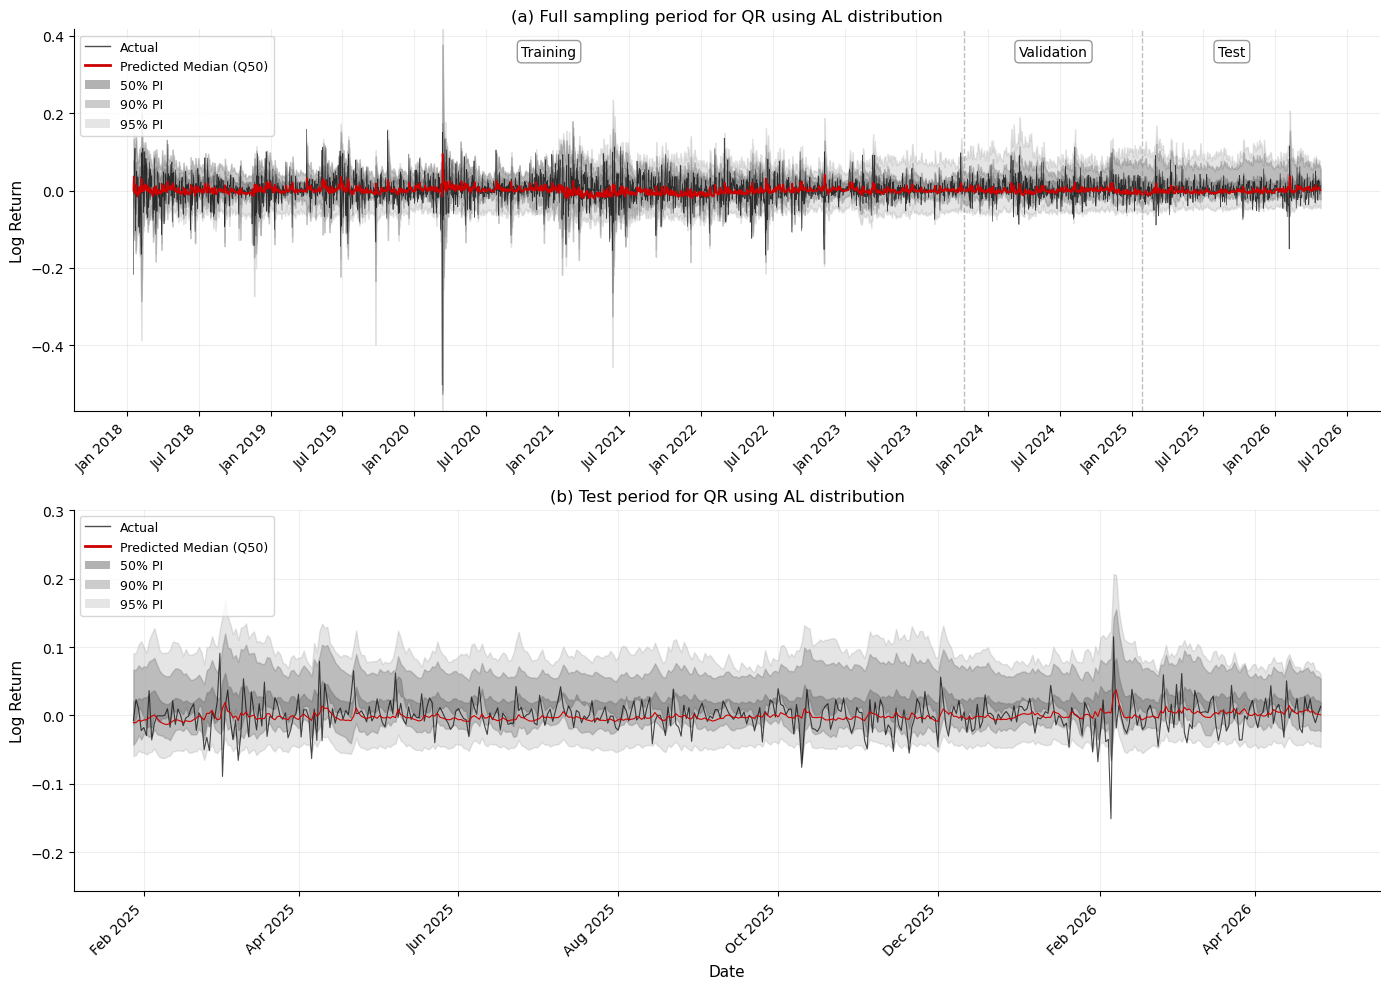

In [164]:
# -------------------------
# Train Final QRNN Models
# -------------------------
def train_final_model_qrnn(alpha, config, y_train, X_train, y_val, X_val, y_test, X_test):
    torch.manual_seed(2025)
    input_dim = X_train.shape[1]
    model = HybridQRNN(input_dim, config)

    if config['optimizer'] == 'adam':
        optimizer = torch.optim.Adam(model.parameters(), lr=config['lr'],
                                     weight_decay=config['weight_decay'])
    else:
        optimizer = torch.optim.AdamW(model.parameters(), lr=config['lr'],
                                      weight_decay=config['weight_decay'])

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', patience=10, factor=0.5, min_lr=1e-6)

    best_val_loss    = float('inf')
    patience_counter = 0
    patience         = 30
    max_epochs       = 200
    best_model_state = None
    train_losses, val_losses = [], []

    for epoch in range(max_epochs):
        model.train()
        optimizer.zero_grad()
        q_hybrid, sigma = model(y_train, X_train)
        loss = hybrid_qrnn_loss(y_train, q_hybrid, sigma, alpha)

        if torch.isnan(loss) or torch.isinf(loss):
            print(f"  NaN/Inf at epoch {epoch}, stopping")
            break

        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), config['gradient_clip'])
        optimizer.step()
        train_losses.append(loss.item())

        model.eval()
        with torch.no_grad():
            q_val, sigma_val = model(y_val, X_val)
            val_loss = hybrid_qrnn_loss(y_val, q_val, sigma_val, alpha)

        val_losses.append(val_loss.item())
        scheduler.step(val_loss)

        if (epoch + 1) % 50 == 0:
            print(f"  Epoch {epoch+1}: train={loss.item():.4f}, val={val_loss.item():.4f}")

        if val_loss < best_val_loss:
            best_val_loss    = val_loss.item()
            patience_counter = 0
            best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"  Early stopping at epoch {epoch+1}")
                break

    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    # Test evaluation
    model.eval()
    with torch.no_grad():
        q_test, sigma_test = model(y_test, X_test)
        test_loss = hybrid_qrnn_loss(y_test, q_test, sigma_test, alpha)

        if alpha <= 0.5:
            coverage = (y_test <= q_test).float().mean().item()
        else:
            coverage = (y_test > q_test).float().mean().item()
        expected       = alpha if alpha <= 0.5 else 1 - alpha
        coverage_ratio = coverage / expected

    print(f"  Test loss: {test_loss.item():.4f} | Coverage ratio: {coverage_ratio:.3f}")

    return model, train_losses, val_losses, q_test.numpy()


# -------------------------
# Convert test tensors
# -------------------------
X_test_q = torch.tensor(test_df[feature_cols].values, dtype=torch.float32)
y_test_q  = torch.tensor(test_df['log_return'].values, dtype=torch.float32)

# -------------------------
# Train all alpha levels
# -------------------------
alpha_levels = [0.025, 0.050, 0.250, 0.500, 0.750, 0.950, 0.975]
results_qrnn = {}

for alpha in alpha_levels:
    print(f"\n{'='*60}")
    print(f"Training final model for alpha = {alpha}")
    print(f"{'='*60}")
    config = best_configs_qrnn[alpha]
    model, train_losses, val_losses, q_test_pred = train_final_model_qrnn(
        alpha, config, y_train, X_train, y_val, X_val, y_test_q, X_test_q
    )
    results_qrnn[alpha] = {
        'model':        model,
        'train_losses': train_losses,
        'val_losses':   val_losses,
        'q_test':       q_test_pred
    }


# ============================================================
# Plotting
# ============================================================
def plot_two_panel_qrnn(results_qrnn, train_df, val_df, test_df, feature_cols):

    actual_color = '#000000'
    pred_color   = '#CC0000'
    pi_color     = '#808080'

    # Get full predictions for all data
    all_preds = {}
    X_all = torch.tensor(df[feature_cols].values, dtype=torch.float32)
    y_all = torch.tensor(df['log_return'].values, dtype=torch.float32)

    alpha_levels = list(best_configs_qrnn.keys())

    for alpha in alpha_levels:
        model = results_qrnn[alpha]['model']
        model.eval()
        with torch.no_grad():
            q_all, _ = model(y_all, X_all)
            all_preds[alpha] = q_all.numpy()

    all_dates  = df.index
    train_size = len(train_df)
    val_size   = len(val_df)
    y_all_np   = df['log_return'].values

    have_95 = (0.025 in all_preds) and (0.975 in all_preds)
    have_90 = (0.05  in all_preds) and (0.95  in all_preds)
    have_50 = (0.25  in all_preds) and (0.75  in all_preds)

    fig, axes = plt.subplots(2, 1, figsize=(14, 10))

    # ---- Panel (a): Full period ----
    ax = axes[0]
    y_min, y_max = y_all_np.min(), y_all_np.max()
    y_range = y_max - y_min
    ax.set_ylim(y_min - 0.1 * y_range, y_max + 0.35 * y_range)

    ax.plot(all_dates, y_all_np, color=actual_color, linewidth=0.5, alpha=0.7, label='Actual')
    ax.plot(all_dates, all_preds[0.5], color=pred_color, linewidth=1.2, label='Predicted Median (Q50)')

    if have_95:
        ax.fill_between(all_dates, all_preds[0.025], all_preds[0.975], color=pi_color, alpha=0.2)
    if have_90:
        ax.fill_between(all_dates, all_preds[0.05],  all_preds[0.95],  color=pi_color, alpha=0.4)
    if have_50:
        ax.fill_between(all_dates, all_preds[0.25],  all_preds[0.75],  color=pi_color, alpha=0.6)

    # Split lines
    ax.axvline(x=train_df.index[-1], color='gray', linestyle='--', alpha=0.5, linewidth=1)
    ax.axvline(x=val_df.index[-1],   color='gray', linestyle='--', alpha=0.5, linewidth=1)

    # Period labels
    y_label = y_max + 0.25 * y_range
    ax.text(train_df.index[len(train_df)//2], y_label, 'Training',
            ha='center', fontsize=10,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='gray', alpha=0.8))
    ax.text(val_df.index[len(val_df)//2], y_label, 'Validation',
            ha='center', fontsize=10,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='gray', alpha=0.8))
    ax.text(test_df.index[len(test_df)//2], y_label, 'Test',
            ha='center', fontsize=10,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='gray', alpha=0.8))

    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

    legend_elements = [
        Line2D([0], [0], color=actual_color, lw=1, alpha=0.7, label='Actual'),
        Line2D([0], [0], color=pred_color,   lw=2, label='Predicted Median (Q50)'),
    ]
    if have_50: legend_elements.append(Patch(facecolor=pi_color, alpha=0.6, label='50% PI'))
    if have_90: legend_elements.append(Patch(facecolor=pi_color, alpha=0.4, label='90% PI'))
    if have_95: legend_elements.append(Patch(facecolor=pi_color, alpha=0.2, label='95% PI'))

    ax.legend(handles=legend_elements, loc='upper left', fontsize=9)
    ax.set_title('(a) Full sampling period for QR using AL distribution', fontsize=12)
    ax.set_ylabel('Log Return', fontsize=11)
    ax.grid(True, alpha=0.2)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # ---- Panel (b): Test period ----
    ax2 = axes[1]
    test_dates = test_df.index
    y_test_np  = test_df['log_return'].values

    y_min_t, y_max_t = y_test_np.min(), y_test_np.max()
    y_range_t = y_max_t - y_min_t
    ax2.set_ylim(y_min_t - 0.4 * y_range_t, y_max_t + 0.7 * y_range_t)

    ax2.plot(test_dates, y_test_np, color=actual_color, linewidth=0.8, alpha=0.7, label='Actual')
    ax2.plot(test_dates, all_preds[0.5][train_size + val_size:],
             color=pred_color, linewidth=0.8)

    if have_95:
        ax2.fill_between(test_dates,
                         all_preds[0.025][train_size + val_size:],
                         all_preds[0.975][train_size + val_size:],
                         color=pi_color, alpha=0.2)
    if have_90:
        ax2.fill_between(test_dates,
                         all_preds[0.05][train_size + val_size:],
                         all_preds[0.95][train_size + val_size:],
                         color=pi_color, alpha=0.4)
    if have_50:
        ax2.fill_between(test_dates,
                         all_preds[0.25][train_size + val_size:],
                         all_preds[0.75][train_size + val_size:],
                         color=pi_color, alpha=0.6)

    ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha='right')

    ax2.legend(handles=legend_elements, loc='upper left', fontsize=9)
    ax2.set_title('(b) Test period for QR using AL distribution', fontsize=12)
    ax2.set_xlabel('Date', fontsize=11)
    ax2.set_ylabel('Log Return', fontsize=11)
    ax2.grid(True, alpha=0.2)
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)

    plt.tight_layout()
    plt.savefig('hybrid_qrnn_predictions.png', dpi=300, bbox_inches='tight')
    plt.show()


# -------------------------
# Run plotting
# -------------------------
plot_two_panel_qrnn(results_qrnn, train_df, val_df, test_df, feature_cols)

### Ranking evaluation method

In [15]:
class HybridQRNN(nn.Module):
    def __init__(self, input_dim, config):
        super().__init__()

        # Fixed initialisations -- estimated during training, not tuned by Optuna
        self.beta1_raw = nn.Parameter(torch.tensor(1.386))   # sigmoid → 0.80
        self.beta2_raw = nn.Parameter(torch.tensor(0.3))
        self.psi_raw   = nn.Parameter(torch.tensor(0.0))     # sigmoid → 0.50
        self.sigma_raw = nn.Parameter(torch.tensor(0.5))

        # Build FNN
        layers = []
        prev_dim = input_dim
        n_hidden = config['n_hidden_layers']

        for i in range(n_hidden):
            hidden_dim = config[f'hidden_dim_{i}']
            layers.append(nn.Linear(prev_dim, hidden_dim))
            if config['layernorm']:
                layers.append(nn.LayerNorm(hidden_dim))
            layers.append(self._get_activation(config['activation']))
            if config['dropout'] > 0:
                layers.append(nn.Dropout(config['dropout']))
            prev_dim = hidden_dim

        layers.append(nn.Linear(prev_dim, 1))
        self.fnn = nn.Sequential(*layers)

        for m in self.fnn.modules():
            if isinstance(m, nn.Linear):
                if config['weight_init'] == 'glorot':
                    nn.init.xavier_uniform_(m.weight)
                elif config['weight_init'] == 'he':
                    nn.init.kaiming_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def _get_activation(self, name):
        return {
            'relu': nn.ReLU(),
            'elu': nn.ELU(),
            'gelu': nn.GELU(),
            'tanh': nn.Tanh()
        }.get(name, nn.ReLU())

    def forward(self, y, X):
        beta1 = torch.sigmoid(self.beta1_raw)
        beta2 = torch.nn.functional.softplus(self.beta2_raw)
        psi   = torch.sigmoid(self.psi_raw)
        sigma = torch.nn.functional.softplus(self.sigma_raw)

        q_hybrid, q_caviar = compute_hybrid_quantile_location(
            y, X, beta1, beta2, self.fnn, psi
        )

        return q_hybrid, sigma


def compute_crp(y, q, alpha):
    """
    Coverage Ratio Penalty (CRP).
    For alpha <= 0.5: count violations where y <= q (lower tail).
    For alpha >  0.5: count violations where y >  q (upper tail).
    CRP = empirical_coverage / alpha*
    Penalty = (CRP - 1)^2
    """
    if alpha <= 0.5:
        empirical  = (y <= q).float().mean().item()
        alpha_star = alpha
    else:
        empirical  = (y > q).float().mean().item()
        alpha_star = 1.0 - alpha

    crp     = empirical / alpha_star
    penalty = (crp - 1.0) ** 2
    return crp, penalty


def objective_qrnn(trial, alpha):
    # Optuna only tunes architecture and training hyperparameters
    config = {
        'n_hidden_layers': trial.suggest_int('n_hidden_layers', 1, 3),
        'activation':      trial.suggest_categorical('activation', ['relu', 'elu', 'gelu', 'tanh']),
        'dropout':         trial.suggest_float('dropout', 0.0, 0.5),
        'layernorm':       trial.suggest_categorical('layernorm', [True, False]),
        'weight_init':     trial.suggest_categorical('weight_init', ['glorot', 'he']),
        'lr':              trial.suggest_float('lr', 1e-4, 5e-2, log=True),
        'optimizer':       trial.suggest_categorical('optimizer', ['adam', 'adamw']),
        'batch_size':      trial.suggest_categorical('batch_size', [32, 64, 128]),
        'weight_decay':    trial.suggest_float('weight_decay', 0.0, 1e-4),
        'gradient_clip':   trial.suggest_categorical('gradient_clip', [0.1, 1.0, 5.0]),
        'patience':        trial.suggest_categorical('patience', [10, 20, 30]),
    }

    for i in range(config['n_hidden_layers']):
        config[f'hidden_dim_{i}'] = trial.suggest_int(f'hidden_dim_{i}', 32, 256)

    input_dim = X_train.shape[1]
    torch.manual_seed(2026)  # unified seed -- same as ERNN
    model = HybridQRNN(input_dim, config)

    if config['optimizer'] == 'adam':
        optimizer = torch.optim.Adam(model.parameters(), lr=config['lr'],
                                     weight_decay=config['weight_decay'])
    else:
        optimizer = torch.optim.AdamW(model.parameters(), lr=config['lr'],
                                      weight_decay=config['weight_decay'])

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', patience=10, factor=0.5, min_lr=1e-6)

    best_val_loss    = float('inf')
    patience_counter = 0
    patience         = config['patience']
    max_epochs       = 200
    best_model_state = None

    for epoch in range(max_epochs):
        model.train()
        optimizer.zero_grad()
        q_hybrid, sigma = model(y_train, X_train)
        loss = hybrid_qrnn_loss(y_train, q_hybrid, sigma, alpha)

        if torch.isnan(loss) or torch.isinf(loss):
            return float('inf')

        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), config['gradient_clip'])
        optimizer.step()

        # early stopping uses NLL only
        model.eval()
        with torch.no_grad():
            q_val, sigma_val = model(y_val, X_val)
            val_loss = hybrid_qrnn_loss(y_val, q_val, sigma_val, alpha)

        scheduler.step(val_loss)

        if val_loss < best_val_loss:
            best_val_loss    = val_loss.item()
            patience_counter = 0
            best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            patience_counter += 1
            if patience_counter >= patience:
                break

    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    # compute NLL and CRP after best model loaded
    with torch.no_grad():
        q_val, sigma_val = model(y_val, X_val)
        val_loss         = hybrid_qrnn_loss(y_val, q_val, sigma_val, alpha)
        crp, crp_penalty = compute_crp(y_val, q_val, alpha)

        beta1 = torch.sigmoid(model.beta1_raw).item()
        beta2 = torch.nn.functional.softplus(model.beta2_raw).item()
        psi   = torch.sigmoid(model.psi_raw).item()
        sigma = torch.nn.functional.softplus(model.sigma_raw).item()

    # store NLL and CRP in trial user_attrs for ranking after all trials finish
    trial.set_user_attr('nll',         val_loss.item())
    trial.set_user_attr('crp',         crp)
    trial.set_user_attr('crp_penalty', crp_penalty)
    trial.set_user_attr('beta1',       beta1)
    trial.set_user_attr('beta2',       beta2)
    trial.set_user_attr('psi',         psi)
    trial.set_user_attr('sigma',       sigma)

    print(f"  Trial {trial.number}: "
          f"NLL={val_loss.item():.4f} | "
          f"CRP={crp:.4f} | "
          f"CRP_penalty={crp_penalty:.4f} | "
          f"alpha={alpha} | lr={config['lr']:.5f} | "
          f"layers={config['n_hidden_layers']} | "
          f"activation={config['activation']} | "
          f"dropout={config['dropout']:.3f} | "
          f"psi={psi:.4f} | sigma={sigma:.4f} | "
          f"beta1={beta1:.4f} | beta2={beta2:.4f}")

    return val_loss.item()


def select_best_trial_by_rank(study):
    """
    Rank all completed trials by NLL and CRP_penalty separately.
    Select trial with lowest sum of ranks.
    Tiebreak: raw NLL, then raw CRP_penalty, then trial number.
    """
    trials = [t for t in study.trials
              if t.state == optuna.trial.TrialState.COMPLETE
              and t.value != float('inf')]

    for t in trials:
        t._nll         = t.user_attrs['nll']
        t._crp_penalty = t.user_attrs['crp_penalty']

    sorted_by_nll = sorted(trials, key=lambda t: t._nll)
    for rank, t in enumerate(sorted_by_nll, start=1):
        t._rank_nll = rank

    sorted_by_crp = sorted(trials, key=lambda t: t._crp_penalty)
    for rank, t in enumerate(sorted_by_crp, start=1):
        t._rank_crp = rank

    best = min(trials, key=lambda t: (
        t._rank_nll + t._rank_crp,
        t._nll,
        t._crp_penalty,
        t.number
    ))

    return best, trials


# -------------------------
# Run tuning for each alpha level
# -------------------------
alpha_levels      = [0.025, 0.050, 0.250, 0.500, 0.750, 0.950, 0.975]
base_seed         = 2026  # unified seed -- same as ERNN
best_configs_qrnn = {}

for i, alpha in enumerate(alpha_levels):
    print(f"\n{'='*60}")
    print(f"Tuning for alpha = {alpha} (seed = {base_seed + i})")
    print(f"{'='*60}")

    sampler = TPESampler(seed=base_seed + i)
    study   = optuna.create_study(direction='minimize', sampler=sampler)
    study.optimize(lambda trial, a=alpha: objective_qrnn(trial, alpha=a),
                   n_trials=200, show_progress_bar=True)

    # rank-based selection after all trials finish
    best_trial, all_trials = select_best_trial_by_rank(study)

    # print ranking summary -- top 10
    print(f"\nRanking summary for alpha={alpha}:")
    print(f"  {'Trial':>6} {'NLL':>8} {'NLL_rank':>9} {'CRP_pen':>9} {'CRP_rank':>9} {'Sum_rank':>9}")
    sorted_trials = sorted(all_trials, key=lambda t: t._rank_nll + t._rank_crp)
    for t in sorted_trials[:10]:
        print(f"  {t.number:>6} {t._nll:>8.4f} {t._rank_nll:>9} "
              f"{t._crp_penalty:>9.4f} {t._rank_crp:>9} "
              f"{t._rank_nll + t._rank_crp:>9}")

    # save full ranking for all trials to CSV
    ranking_records = []
    for t in all_trials:
        record = {
            'alpha':       alpha,
            'trial':       t.number,
            'nll':         t._nll,
            'crp':         t.user_attrs['crp'],
            'crp_penalty': t._crp_penalty,
            'rank_nll':    t._rank_nll,
            'rank_crp':    t._rank_crp,
            'sum_rank':    t._rank_nll + t._rank_crp,
            'beta1':       t.user_attrs['beta1'],
            'beta2':       t.user_attrs['beta2'],
            'psi':         t.user_attrs['psi'],
            'sigma':       t.user_attrs['sigma'],
        }
        record.update(t.params)
        ranking_records.append(record)

    ranking_df = pd.DataFrame(ranking_records)
    ranking_df = ranking_df.sort_values('sum_rank')
    ranking_df.to_csv(f'qrnn_cross_ranking_alpha_{alpha}.csv', index=False)
    print(f"  Full ranking saved to qrnn_cross_ranking_alpha_{alpha}.csv")

    best_configs_qrnn[alpha] = best_trial.params.copy()
    best_configs_qrnn[alpha]['alpha'] = alpha

    # re-run best config to extract estimated parameters
    torch.manual_seed(2026)  # unified seed -- same as ERNN
    best_model = HybridQRNN(X_train.shape[1], best_configs_qrnn[alpha])

    if best_configs_qrnn[alpha]['optimizer'] == 'adam':
        optimizer = torch.optim.Adam(best_model.parameters(),
                                     lr=best_configs_qrnn[alpha]['lr'],
                                     weight_decay=best_configs_qrnn[alpha]['weight_decay'])
    else:
        optimizer = torch.optim.AdamW(best_model.parameters(),
                                      lr=best_configs_qrnn[alpha]['lr'],
                                      weight_decay=best_configs_qrnn[alpha]['weight_decay'])

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', patience=10, factor=0.5, min_lr=1e-6)

    best_val_loss    = float('inf')
    patience_counter = 0
    best_model_state = None

    for epoch in range(200):
        best_model.train()
        optimizer.zero_grad()
        q_hybrid, sigma = best_model(y_train, X_train)
        loss = hybrid_qrnn_loss(y_train, q_hybrid, sigma, alpha)
        if torch.isnan(loss) or torch.isinf(loss):
            break
        loss.backward()
        nn.utils.clip_grad_norm_(best_model.parameters(),
                                  best_configs_qrnn[alpha]['gradient_clip'])
        optimizer.step()

        best_model.eval()
        with torch.no_grad():
            q_val, sigma_val = best_model(y_val, X_val)
            val_loss = hybrid_qrnn_loss(y_val, q_val, sigma_val, alpha)
        scheduler.step(val_loss)

        if val_loss < best_val_loss:
            best_val_loss    = val_loss.item()
            patience_counter = 0
            best_model_state = {k: v.clone() for k, v in best_model.state_dict().items()}
        else:
            patience_counter += 1
            if patience_counter >= best_configs_qrnn[alpha].get('patience', 20):
                break

    if best_model_state is not None:
        best_model.load_state_dict(best_model_state)

    with torch.no_grad():
        q_val_final, sigma_val_final = best_model(y_val, X_val)
        final_nll                    = hybrid_qrnn_loss(y_val, q_val_final, sigma_val_final, alpha).item()
        final_crp, final_crp_penalty = compute_crp(y_val, q_val_final, alpha)

        est_beta1 = torch.sigmoid(best_model.beta1_raw).item()
        est_beta2 = torch.nn.functional.softplus(best_model.beta2_raw).item()
        est_psi   = torch.sigmoid(best_model.psi_raw).item()
        est_sigma = torch.nn.functional.softplus(best_model.sigma_raw).item()

    best_configs_qrnn[alpha]['est_psi']   = est_psi
    best_configs_qrnn[alpha]['est_sigma'] = est_sigma
    best_configs_qrnn[alpha]['est_beta1'] = est_beta1
    best_configs_qrnn[alpha]['est_beta2'] = est_beta2
    best_configs_qrnn[alpha]['est_crp']   = final_crp

    print(f"\nBest trial (rank-based): #{best_trial.number}")
    print(f"  NLL rank:   {best_trial._rank_nll} | CRP rank: {best_trial._rank_crp} | "
          f"Sum: {best_trial._rank_nll + best_trial._rank_crp}")
    print(f"Final NLL:          {final_nll:.4f}")
    print(f"Final CRP:          {final_crp:.4f}")
    print(f"Final CRP penalty:  {final_crp_penalty:.4f}")
    print(f"Best params: {best_trial.params}")
    print(f"Estimated psi:   {est_psi:.4f}")
    print(f"Estimated sigma: {est_sigma:.4f}")
    print(f"Estimated beta1: {est_beta1:.4f}")
    print(f"Estimated beta2: {est_beta2:.4f}")

print("\n" + "="*60)
print("TUNING COMPLETE — BEST CONFIGS PER ALPHA (CROSS-LAGGED, 200 TRIALS)")
print("="*60)
for alpha, config in best_configs_qrnn.items():
    print(f"alpha={alpha}: {config}")

[I 2026-07-06 12:29:55,690] A new study created in memory with name: no-name-c8c9373a-2ffb-4d44-9c48-366f3753c0d3



Tuning for alpha = 0.025 (seed = 2026)


  0%|          | 0/200 [00:00<?, ?it/s]

  Trial 0: NLL=3.6967 | CRP=0.0883 | CRP_penalty=0.8312 | alpha=0.025 | lr=0.00066 | layers=1 | activation=elu | dropout=0.494 | psi=0.5002 | sigma=0.9737 | beta1=0.8001 | beta2=0.8540
[I 2026-07-06 12:29:58,892] Trial 0 finished with value: 3.6967480182647705 and parameters: {'n_hidden_layers': 1, 'activation': 'elu', 'dropout': 0.49377524711883497, 'layernorm': False, 'weight_init': 'he', 'lr': 0.0006552020421842752, 'optimizer': 'adam', 'batch_size': 32, 'weight_decay': 5.618938892024055e-05, 'gradient_clip': 5.0, 'patience': 30, 'hidden_dim_0': 176}. Best is trial 0 with value: 3.6967480182647705.
  Trial 1: NLL=3.6843 | CRP=0.0883 | CRP_penalty=0.8312 | alpha=0.025 | lr=0.00050 | layers=1 | activation=relu | dropout=0.341 | psi=0.5070 | sigma=0.9554 | beta1=0.7973 | beta2=0.8494
[I 2026-07-06 12:30:15,053] Trial 1 finished with value: 3.684284210205078 and parameters: {'n_hidden_layers': 1, 'activation': 'relu', 'dropout': 0.3412887415864622, 'layernorm': True, 'weight_init': 'glo

[I 2026-07-06 13:21:02,616] A new study created in memory with name: no-name-879bd920-cae6-4f48-a539-c5a9b8c0a7f1


...

  Trial 0: NLL=1.8768 | CRP=0.1325 | CRP_penalty=0.7526 | alpha=0.95 | lr=0.00703 | layers=2 | activation=tanh | dropout=0.112 | psi=0.5372 | sigma=0.3070 | beta1=0.7520 | beta2=0.6510
[I 2026-07-06 18:27:38,592] Trial 0 finished with value: 1.8768455982208252 and parameters: {'n_hidden_layers': 2, 'activation': 'tanh', 'dropout': 0.11155263989652436, 'layernorm': False, 'weight_init': 'glorot', 'lr': 0.007027131382827591, 'optimizer': 'adam', 'batch_size': 64, 'weight_decay': 3.1297438535544123e-06, 'gradient_clip': 1.0, 'patience': 10, 'hidden_dim_0': 187, 'hidden_dim_1': 217}. Best is trial 0 with value: 1.8768455982208252.
  Trial 1: NLL=2.1796 | CRP=5.3422 | CRP_penalty=18.8544 | alpha=0.95 | lr=0.00544 | layers=2 | activation=tanh | dropout=0.041 | psi=0.5270 | sigma=0.4162 | beta1=0.7670 | beta2=0.7096
[I 2026-07-06 18:27:55,234] Trial 1 finished with value: 2.179570436477661 and parameters: {'n_hidden_layers': 2, 'activation': 'tanh', 'dropout': 0.04083183838368104, 'layernorm'

[I 2026-07-06 19:18:46,065] A new study created in memory with name: no-name-ff168b40-1925-4cbc-8f90-117f4d48fe3d



Best trial (rank-based): #184
  NLL rank:   6 | CRP rank: 8 | Sum: 14
Final NLL:          -2.2874
Final CRP:          1.0155
Final CRP penalty:  0.0002
Best params: {'n_hidden_layers': 1, 'activation': 'elu', 'dropout': 0.24955878325269842, 'layernorm': False, 'weight_init': 'he', 'lr': 0.041711567179302834, 'optimizer': 'adam', 'batch_size': 64, 'weight_decay': 2.3801591059804475e-05, 'gradient_clip': 1.0, 'patience': 20, 'hidden_dim_0': 76}
Estimated psi:   0.9423
Estimated sigma: 0.0028
Estimated beta1: 0.0443
Estimated beta2: 0.0620

Tuning for alpha = 0.975 (seed = 2032)


  0%|          | 0/200 [00:00<?, ?it/s]

  Trial 0: NLL=2.4791 | CRP=3.3554 | CRP_penalty=5.5479 | alpha=0.975 | lr=0.00741 | layers=3 | activation=relu | dropout=0.111 | psi=0.5128 | sigma=0.2888 | beta1=0.7617 | beta2=0.6308
[I 2026-07-06 19:19:03,713] Trial 0 finished with value: 2.479064702987671 and parameters: {'n_hidden_layers': 3, 'activation': 'relu', 'dropout': 0.11110238679748752, 'layernorm': False, 'weight_init': 'he', 'lr': 0.007412946243424984, 'optimizer': 'adam', 'batch_size': 128, 'weight_decay': 7.766054095562223e-05, 'gradient_clip': 1.0, 'patience': 20, 'hidden_dim_0': 195, 'hidden_dim_1': 201, 'hidden_dim_2': 229}. Best is trial 0 with value: 2.479064702987671.
  Trial 1: NLL=3.6766 | CRP=0.0000 | CRP_penalty=1.0000 | alpha=0.975 | lr=0.00011 | layers=1 | activation=elu | dropout=0.061 | psi=0.5029 | sigma=0.9560 | beta1=0.7986 | beta2=0.8577
[I 2026-07-06 19:19:21,088] Trial 1 finished with value: 3.67661452293396 and parameters: {'n_hidden_layers': 1, 'activation': 'elu', 'dropout': 0.06117595133568870

In [17]:
configs_rows = []
for tau, config in best_configs_qrnn.items():
    row = {'tau': tau}
    row.update(config)
    configs_rows.append(row)

configs_df = pd.DataFrame(configs_rows)
configs_df = configs_df.set_index('tau')
configs_df

,n_hidden_layers,activation,dropout,layernorm,weight_init,lr,optimizer,batch_size,weight_decay,gradient_clip,patience,hidden_dim_0,hidden_dim_1,alpha,est_psi,est_sigma,est_beta1,est_beta2,est_crp
tau,,,,,,,,,,,,,,,,,,,
0.025,2,gelu,0.364034,True,he,0.049863,adamw,128,0.000087,1.0,20,251,152.0,0.025,0.956034,0.001450,0.054034,0.058217,0.971302
0.050,1,tanh,0.168862,False,he,0.049458,adamw,64,0.000064,1.0,20,219,NaN,0.050,0.977103,0.002281,0.045885,0.091030,0.971302
0.250,1,tanh,0.065131,False,he,0.033517,adamw,32,0.000005,5.0,20,69,NaN,0.250,0.891056,0.007531,0.049716,0.136797,1.015453
0.500,2,gelu,0.029978,False,he,0.042869,adam,128,0.000026,1.0,20,69,232.0,0.500,0.971447,0.009352,0.050040,0.115565,0.997792
0.750,1,tanh,0.224741,False,he,0.045978,adamw,128,0.000063,1.0,20,138,NaN,0.750,0.943849,0.007436,0.064498,0.063981,0.988962
0.950,1,elu,0.249559,False,he,0.041712,adam,64,0.000024,1.0,20,76,NaN,0.950,0.942325,0.002839,0.044348,0.062015,1.015453
0.975,1,elu,0.356013,False,he,0.049341,adamw,32,0.000097,1.0,20,181,NaN,0.975,0.979547,0.001316,0.023804,0.041090,0.971302



Training final model for alpha = 0.025
  Epoch 50: train=1.8654, val=1.8008
  Epoch 100: train=-0.5911, val=-0.6988
  Epoch 150: train=-0.8168, val=-1.6442
  Epoch 200: train=-1.7647, val=-1.9999
  Test loss: -2.1597 | Coverage ratio: 1.322

Training final model for alpha = 0.05
  Epoch 50: train=1.3973, val=1.3453
  Epoch 100: train=-1.0750, val=-1.2723
  Epoch 150: train=-2.0540, val=-2.1452
  Epoch 200: train=-2.1737, val=-2.1465
  Test loss: -2.3763 | Coverage ratio: 2.863

Training final model for alpha = 0.25
  Epoch 50: train=0.3346, val=0.3214
  Epoch 100: train=-1.2709, val=-1.3188
  Epoch 150: train=-2.0265, val=-2.1942
  Epoch 200: train=-2.3781, val=-2.4627
  Test loss: -2.5065 | Coverage ratio: 1.930

Training final model for alpha = 0.5
  Epoch 50: train=-0.2765, val=-0.3150
  Epoch 100: train=-1.6284, val=-1.8087
  Epoch 150: train=-2.2529, val=-2.2224
  Epoch 200: train=-2.3676, val=-2.3020
  Test loss: -2.4679 | Coverage ratio: 1.590

Training final model for alpha = 

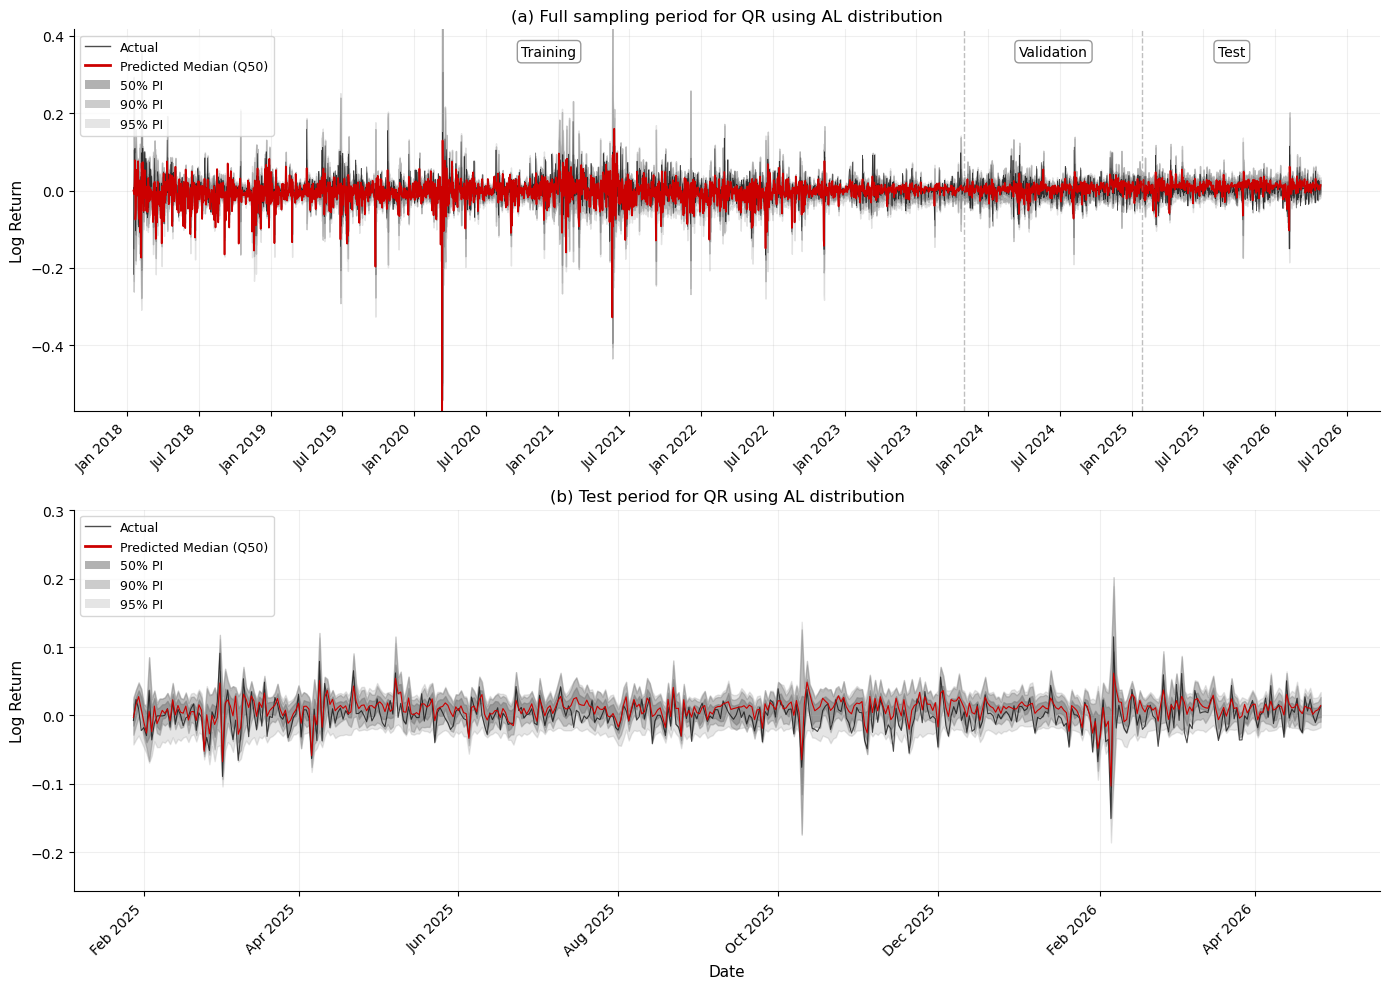

In [209]:
# -------------------------
# Train Final QRNN Models
# -------------------------
def train_final_model_qrnn(alpha, config, y_train, X_train, y_val, X_val, y_test, X_test):
    torch.manual_seed(3000)
    input_dim = X_train.shape[1]
    model = HybridQRNN(input_dim, config)

    if config['optimizer'] == 'adam':
        optimizer = torch.optim.Adam(model.parameters(), lr=config['lr'],
                                     weight_decay=config['weight_decay'])
    else:
        optimizer = torch.optim.AdamW(model.parameters(), lr=config['lr'],
                                      weight_decay=config['weight_decay'])

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', patience=10, factor=0.5, min_lr=1e-6)

    best_val_loss    = float('inf')
    patience_counter = 0
    patience         = 30
    max_epochs       = 200
    best_model_state = None
    train_losses, val_losses = [], []

    for epoch in range(max_epochs):
        model.train()
        optimizer.zero_grad()
        q_hybrid, sigma = model(y_train, X_train)
        loss = hybrid_qrnn_loss(y_train, q_hybrid, sigma, alpha)

        if torch.isnan(loss) or torch.isinf(loss):
            print(f"  NaN/Inf at epoch {epoch}, stopping")
            break

        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), config['gradient_clip'])
        optimizer.step()
        train_losses.append(loss.item())

        model.eval()
        with torch.no_grad():
            q_val, sigma_val = model(y_val, X_val)
            val_loss = hybrid_qrnn_loss(y_val, q_val, sigma_val, alpha)

        val_losses.append(val_loss.item())
        scheduler.step(val_loss)

        if (epoch + 1) % 50 == 0:
            print(f"  Epoch {epoch+1}: train={loss.item():.4f}, val={val_loss.item():.4f}")

        if val_loss < best_val_loss:
            best_val_loss    = val_loss.item()
            patience_counter = 0
            best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"  Early stopping at epoch {epoch+1}")
                break

    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    # Test evaluation
    model.eval()
    with torch.no_grad():
        q_test, sigma_test = model(y_test, X_test)
        test_loss = hybrid_qrnn_loss(y_test, q_test, sigma_test, alpha)

        if alpha <= 0.5:
            coverage = (y_test <= q_test).float().mean().item()
        else:
            coverage = (y_test > q_test).float().mean().item()
        expected       = alpha if alpha <= 0.5 else 1 - alpha
        coverage_ratio = coverage / expected

    print(f"  Test loss: {test_loss.item():.4f} | Coverage ratio: {coverage_ratio:.3f}")

    return model, train_losses, val_losses, q_test.numpy()


# -------------------------
# Convert test tensors
# -------------------------
X_test_q = torch.tensor(test_df[feature_cols].values, dtype=torch.float32)
y_test_q  = torch.tensor(test_df['log_return'].values, dtype=torch.float32)

# -------------------------
# Train all alpha levels
# -------------------------
alpha_levels = [0.025, 0.050, 0.250, 0.500, 0.750, 0.950, 0.975]
results_qrnn = {}

for alpha in alpha_levels:
    print(f"\n{'='*60}")
    print(f"Training final model for alpha = {alpha}")
    print(f"{'='*60}")
    config = best_configs_qrnn[alpha]
    model, train_losses, val_losses, q_test_pred = train_final_model_qrnn(
        alpha, config, y_train, X_train, y_val, X_val, y_test_q, X_test_q
    )
    results_qrnn[alpha] = {
        'model':        model,
        'train_losses': train_losses,
        'val_losses':   val_losses,
        'q_test':       q_test_pred
    }


# ============================================================
# Plotting
# ============================================================
def plot_two_panel_qrnn(results_qrnn, train_df, val_df, test_df, feature_cols):

    actual_color = '#000000'
    pred_color   = '#CC0000'
    pi_color     = '#808080'

    # Get full predictions for all data
    all_preds = {}
    X_all = torch.tensor(df[feature_cols].values, dtype=torch.float32)
    y_all = torch.tensor(df['log_return'].values, dtype=torch.float32)

    alpha_levels = list(best_configs_qrnn.keys())

    for alpha in alpha_levels:
        model = results_qrnn[alpha]['model']
        model.eval()
        with torch.no_grad():
            q_all, _ = model(y_all, X_all)
            all_preds[alpha] = q_all.numpy()

    all_dates  = df.index
    train_size = len(train_df)
    val_size   = len(val_df)
    y_all_np   = df['log_return'].values

    have_95 = (0.025 in all_preds) and (0.975 in all_preds)
    have_90 = (0.05  in all_preds) and (0.95  in all_preds)
    have_50 = (0.25  in all_preds) and (0.75  in all_preds)

    fig, axes = plt.subplots(2, 1, figsize=(14, 10))

    # ---- Panel (a): Full period ----
    ax = axes[0]
    y_min, y_max = y_all_np.min(), y_all_np.max()
    y_range = y_max - y_min
    ax.set_ylim(y_min - 0.1 * y_range, y_max + 0.35 * y_range)

    ax.plot(all_dates, y_all_np, color=actual_color, linewidth=0.5, alpha=0.7, label='Actual')
    ax.plot(all_dates, all_preds[0.5], color=pred_color, linewidth=1.2, label='Predicted Median (Q50)')

    if have_95:
        ax.fill_between(all_dates, all_preds[0.025], all_preds[0.975], color=pi_color, alpha=0.2)
    if have_90:
        ax.fill_between(all_dates, all_preds[0.05],  all_preds[0.95],  color=pi_color, alpha=0.4)
    if have_50:
        ax.fill_between(all_dates, all_preds[0.25],  all_preds[0.75],  color=pi_color, alpha=0.6)

    # Split lines
    ax.axvline(x=train_df.index[-1], color='gray', linestyle='--', alpha=0.5, linewidth=1)
    ax.axvline(x=val_df.index[-1],   color='gray', linestyle='--', alpha=0.5, linewidth=1)

    # Period labels
    y_label = y_max + 0.25 * y_range
    ax.text(train_df.index[len(train_df)//2], y_label, 'Training',
            ha='center', fontsize=10,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='gray', alpha=0.8))
    ax.text(val_df.index[len(val_df)//2], y_label, 'Validation',
            ha='center', fontsize=10,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='gray', alpha=0.8))
    ax.text(test_df.index[len(test_df)//2], y_label, 'Test',
            ha='center', fontsize=10,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='gray', alpha=0.8))

    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

    legend_elements = [
        Line2D([0], [0], color=actual_color, lw=1, alpha=0.7, label='Actual'),
        Line2D([0], [0], color=pred_color,   lw=2, label='Predicted Median (Q50)'),
    ]
    if have_50: legend_elements.append(Patch(facecolor=pi_color, alpha=0.6, label='50% PI'))
    if have_90: legend_elements.append(Patch(facecolor=pi_color, alpha=0.4, label='90% PI'))
    if have_95: legend_elements.append(Patch(facecolor=pi_color, alpha=0.2, label='95% PI'))

    ax.legend(handles=legend_elements, loc='upper left', fontsize=9)
    ax.set_title('(a) Full sampling period for QR using AL distribution', fontsize=12)
    ax.set_ylabel('Log Return', fontsize=11)
    ax.grid(True, alpha=0.2)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # ---- Panel (b): Test period ----
    ax2 = axes[1]
    test_dates = test_df.index
    y_test_np  = test_df['log_return'].values

    y_min_t, y_max_t = y_test_np.min(), y_test_np.max()
    y_range_t = y_max_t - y_min_t
    ax2.set_ylim(y_min_t - 0.4 * y_range_t, y_max_t + 0.7 * y_range_t)

    ax2.plot(test_dates, y_test_np, color=actual_color, linewidth=0.8, alpha=0.7, label='Actual')
    ax2.plot(test_dates, all_preds[0.5][train_size + val_size:],
             color=pred_color, linewidth=0.8)

    if have_95:
        ax2.fill_between(test_dates,
                         all_preds[0.025][train_size + val_size:],
                         all_preds[0.975][train_size + val_size:],
                         color=pi_color, alpha=0.2)
    if have_90:
        ax2.fill_between(test_dates,
                         all_preds[0.05][train_size + val_size:],
                         all_preds[0.95][train_size + val_size:],
                         color=pi_color, alpha=0.4)
    if have_50:
        ax2.fill_between(test_dates,
                         all_preds[0.25][train_size + val_size:],
                         all_preds[0.75][train_size + val_size:],
                         color=pi_color, alpha=0.6)

    ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha='right')

    ax2.legend(handles=legend_elements, loc='upper left', fontsize=9)
    ax2.set_title('(b) Test period for QR using AL distribution', fontsize=12)
    ax2.set_xlabel('Date', fontsize=11)
    ax2.set_ylabel('Log Return', fontsize=11)
    ax2.grid(True, alpha=0.2)
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)

    plt.tight_layout()
    plt.savefig('hybrid_qrnn_predictions.png', dpi=300, bbox_inches='tight')
    plt.show()


# -------------------------
# Run plotting
# -------------------------
plot_two_panel_qrnn(results_qrnn, train_df, val_df, test_df, feature_cols)


Training final model for alpha = 0.025 (cross-lagged)
  Epoch 50: train=1.6306, val=1.5718
  Epoch 100: train=-0.7530, val=-0.8807
  Epoch 150: train=-1.6807, val=-1.8459
  Epoch 200: train=-1.9425, val=-2.1583
  Test loss: -2.2819 | Coverage ratio: 1.057 | beta1=0.0540 | beta2=0.0582 | psi=0.9560 | sigma=0.0014

Training final model for alpha = 0.05 (cross-lagged)
  Epoch 50: train=1.1326, val=1.0521
  Epoch 100: train=-0.8422, val=-0.4585
  Epoch 150: train=-2.0218, val=-1.7273
  Epoch 200: train=-2.1235, val=-2.2782
  Test loss: -2.4450 | Coverage ratio: 2.247 | beta1=0.0459 | beta2=0.0910 | psi=0.9771 | sigma=0.0023

Training final model for alpha = 0.25 (cross-lagged)
  Epoch 50: train=0.3457, val=0.2917
  Epoch 100: train=-1.1615, val=-1.3122
  Epoch 150: train=-2.1506, val=-1.9330
  Epoch 200: train=-2.3751, val=-2.4608
  Test loss: -2.6387 | Coverage ratio: 1.419 | beta1=0.0497 | beta2=0.1368 | psi=0.8911 | sigma=0.0075

Training final model for alpha = 0.5 (cross-lagged)
  Ep

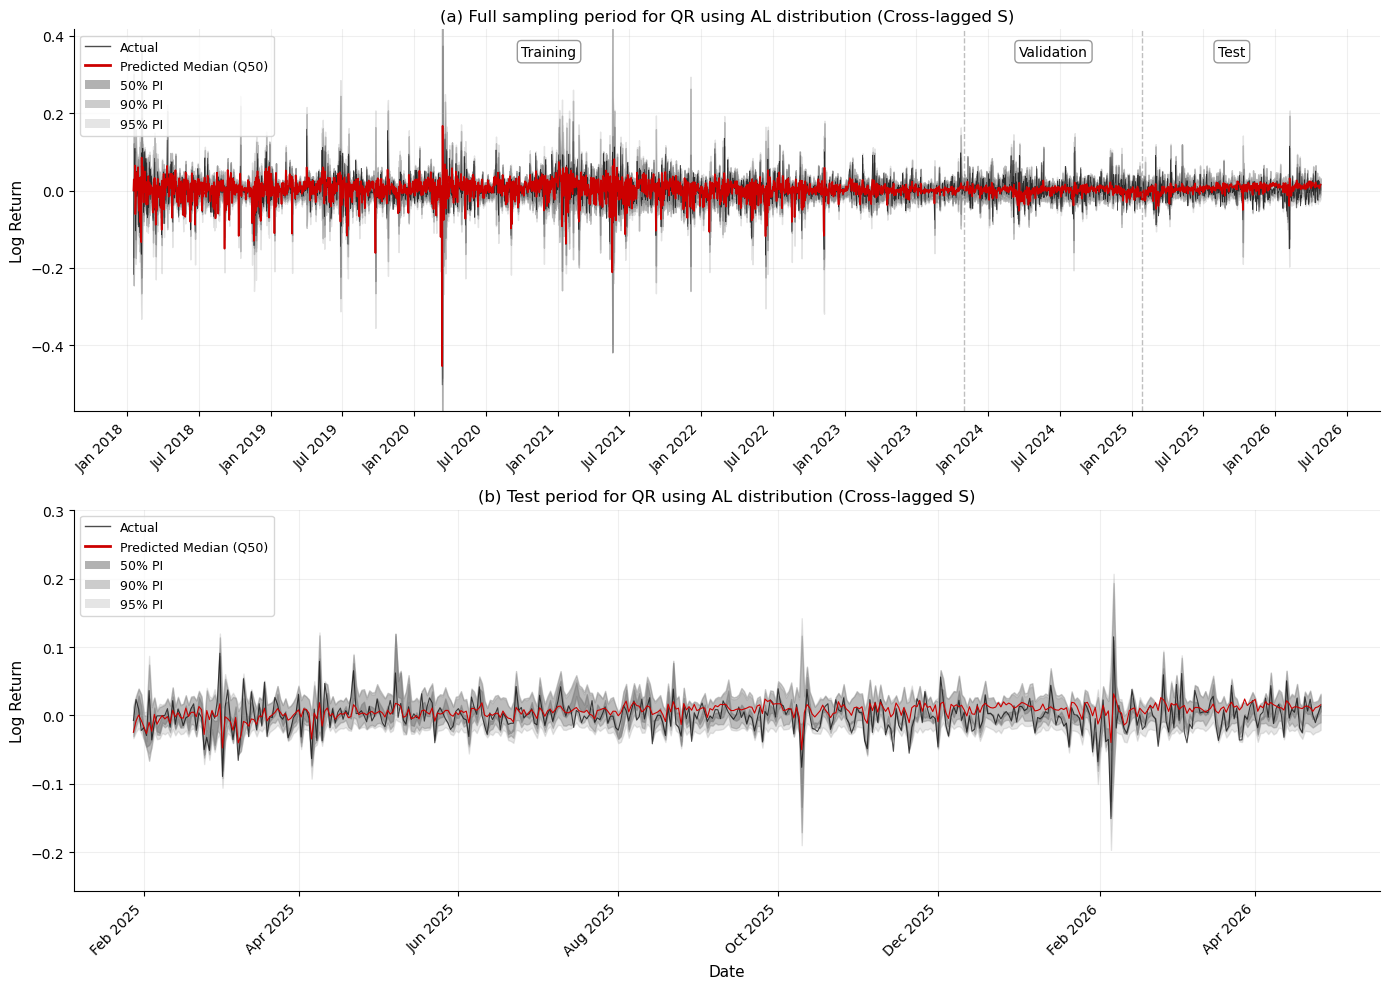


CROSSOVER ANALYSIS -- QRNN Cross S (TEST PERIOD, T=454)
              Pair   Violations    Pct (%)
  ------------------------------------------
  (0.025, 0.050):           7      1.54% <-- TAIL
  (0.050, 0.250):           6      1.32%
  (0.250, 0.500):          50     11.01%
  (0.500, 0.750):         274     60.35%
  (0.750, 0.950):           1      0.22%
  (0.950, 0.975):         296     65.20% <-- TAIL
  ------------------------------------------
  Total violations:         634  (23.27% of all pairs)
  Tail violations:          303  (33.37% of tail pairs)


In [21]:
def train_final_model_qrnn(alpha, config, y_train, X_train, y_val, X_val, y_test, X_test):
    torch.manual_seed(2026)
    input_dim = X_train.shape[1]
    model = HybridQRNN(input_dim, config)

    if config['optimizer'] == 'adam':
        optimizer = torch.optim.Adam(model.parameters(), lr=config['lr'],
                                     weight_decay=config['weight_decay'])
    else:
        optimizer = torch.optim.AdamW(model.parameters(), lr=config['lr'],
                                      weight_decay=config['weight_decay'])

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', patience=10, factor=0.5, min_lr=1e-6)

    best_val_loss    = float('inf')
    patience_counter = 0
    patience         = config.get('patience', 30)
    max_epochs       = 200
    best_model_state = None
    train_losses, val_losses = [], []

    for epoch in range(max_epochs):
        model.train()
        optimizer.zero_grad()
        q_hybrid, sigma = model(y_train, X_train)
        loss = hybrid_qrnn_loss(y_train, q_hybrid, sigma, alpha)

        if torch.isnan(loss) or torch.isinf(loss):
            print(f"  NaN/Inf at epoch {epoch}, stopping")
            break

        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), config['gradient_clip'])
        optimizer.step()
        train_losses.append(loss.item())

        model.eval()
        with torch.no_grad():
            q_val, sigma_val = model(y_val, X_val)
            val_loss = hybrid_qrnn_loss(y_val, q_val, sigma_val, alpha)

        val_losses.append(val_loss.item())
        scheduler.step(val_loss)

        if (epoch + 1) % 50 == 0:
            print(f"  Epoch {epoch+1}: train={loss.item():.4f}, val={val_loss.item():.4f}")

        if val_loss < best_val_loss:
            best_val_loss    = val_loss.item()
            patience_counter = 0
            best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"  Early stopping at epoch {epoch+1}")
                break

    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    model.eval()
    with torch.no_grad():
        q_test, sigma_test = model(y_test, X_test)
        test_loss = hybrid_qrnn_loss(y_test, q_test, sigma_test, alpha)

        if alpha <= 0.5:
            coverage = (y_test <= q_test).float().mean().item()
        else:
            coverage = (y_test > q_test).float().mean().item()
        expected       = alpha if alpha <= 0.5 else 1 - alpha
        coverage_ratio = coverage / expected

    with torch.no_grad():
        est_beta1 = torch.sigmoid(model.beta1_raw).item()
        est_beta2 = torch.nn.functional.softplus(model.beta2_raw).item()
        est_psi   = torch.sigmoid(model.psi_raw).item()
        est_sigma = torch.nn.functional.softplus(model.sigma_raw).item()

    print(f"  Test loss: {test_loss.item():.4f} | Coverage ratio: {coverage_ratio:.3f} | "
          f"beta1={est_beta1:.4f} | beta2={est_beta2:.4f} | "
          f"psi={est_psi:.4f} | sigma={est_sigma:.4f}")

    history_df = pd.DataFrame({
        'epoch':      range(len(train_losses)),
        'train_loss': train_losses,
        'val_loss':   val_losses
    })
    history_df.to_csv(f'qrnn_cross_history_alpha_{alpha}.csv', index=False)

    return model, train_losses, val_losses, q_test.numpy()


# -------------------------
# Convert test tensors
# -------------------------
X_test_q = torch.tensor(test_df[feature_cols].values, dtype=torch.float32)
y_test_q  = torch.tensor(test_df['log_return'].values, dtype=torch.float32)

# -------------------------
# Train all alpha levels
# -------------------------
alpha_levels = [0.025, 0.050, 0.250, 0.500, 0.750, 0.950, 0.975]
results_qrnn = {}

for alpha in alpha_levels:
    print(f"\n{'='*60}")
    print(f"Training final model for alpha = {alpha} (cross-lagged)")
    print(f"{'='*60}")
    config = best_configs_qrnn[alpha]  # fixed -- was best_configs2
    model, train_losses, val_losses, q_test_pred = train_final_model_qrnn(
        alpha, config, y_train, X_train, y_val, X_val, y_test_q, X_test_q
    )
    results_qrnn[alpha] = {
        'model':        model,
        'train_losses': train_losses,
        'val_losses':   val_losses,
        'q_test':       q_test_pred
    }


# ============================================================
# Plotting
# ============================================================
import matplotlib.dates as mdates
from matplotlib.patches import Patch
from matplotlib.lines import Line2D


def plot_two_panel_qrnn(results_qrnn, train_df, val_df, test_df, feature_cols,
                        title_suffix='QR using AL distribution (Cross-lagged S)',
                        save_fname='hybrid_qrnn_cross_s_predictions.png'):

    actual_color = '#000000'
    pred_color   = '#CC0000'
    pi_color     = '#808080'

    all_preds = {}
    X_all = torch.tensor(df[feature_cols].values, dtype=torch.float32)
    y_all = torch.tensor(df['log_return'].values, dtype=torch.float32)

    alpha_levels = list(best_configs_qrnn.keys())

    for alpha in alpha_levels:
        model = results_qrnn[alpha]['model']
        model.eval()
        with torch.no_grad():
            q_all, _ = model(y_all, X_all)
            all_preds[alpha] = q_all.numpy()

    all_dates  = df.index
    train_size = len(train_df)
    val_size   = len(val_df)
    y_all_np   = df['log_return'].values

    have_95 = (0.025 in all_preds) and (0.975 in all_preds)
    have_90 = (0.05  in all_preds) and (0.95  in all_preds)
    have_50 = (0.25  in all_preds) and (0.75  in all_preds)

    fig, axes = plt.subplots(2, 1, figsize=(14, 10))

    # ---- Panel (a): Full period ----
    ax = axes[0]
    y_min, y_max = y_all_np.min(), y_all_np.max()
    y_range = y_max - y_min
    ax.set_ylim(y_min - 0.1 * y_range, y_max + 0.35 * y_range)

    ax.plot(all_dates, y_all_np, color=actual_color, linewidth=0.5, alpha=0.7, label='Actual')
    ax.plot(all_dates, all_preds[0.5], color=pred_color, linewidth=1.2, label='Predicted Median (Q50)')

    if have_95:
        ax.fill_between(all_dates, all_preds[0.025], all_preds[0.975], color=pi_color, alpha=0.2)
    if have_90:
        ax.fill_between(all_dates, all_preds[0.05],  all_preds[0.95],  color=pi_color, alpha=0.4)
    if have_50:
        ax.fill_between(all_dates, all_preds[0.25],  all_preds[0.75],  color=pi_color, alpha=0.6)

    ax.axvline(x=train_df.index[-1], color='gray', linestyle='--', alpha=0.5, linewidth=1)
    ax.axvline(x=val_df.index[-1],   color='gray', linestyle='--', alpha=0.5, linewidth=1)

    y_label = y_max + 0.25 * y_range
    ax.text(train_df.index[len(train_df)//2], y_label, 'Training',
            ha='center', fontsize=10,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='gray', alpha=0.8))
    ax.text(val_df.index[len(val_df)//2], y_label, 'Validation',
            ha='center', fontsize=10,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='gray', alpha=0.8))
    ax.text(test_df.index[len(test_df)//2], y_label, 'Test',
            ha='center', fontsize=10,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='gray', alpha=0.8))

    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

    legend_elements = [
        Line2D([0], [0], color=actual_color, lw=1, alpha=0.7, label='Actual'),
        Line2D([0], [0], color=pred_color,   lw=2,             label='Predicted Median (Q50)'),
    ]
    if have_50: legend_elements.append(Patch(facecolor=pi_color, alpha=0.6, label='50% PI'))
    if have_90: legend_elements.append(Patch(facecolor=pi_color, alpha=0.4, label='90% PI'))
    if have_95: legend_elements.append(Patch(facecolor=pi_color, alpha=0.2, label='95% PI'))

    ax.legend(handles=legend_elements, loc='upper left', fontsize=9)
    ax.set_title(f'(a) Full sampling period for {title_suffix}', fontsize=12)
    ax.set_ylabel('Log Return', fontsize=11)
    ax.grid(True, alpha=0.2)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # ---- Panel (b): Test period ----
    ax2 = axes[1]
    test_dates = test_df.index
    y_test_np  = test_df['log_return'].values

    y_min_t, y_max_t = y_test_np.min(), y_test_np.max()
    y_range_t = y_max_t - y_min_t
    ax2.set_ylim(y_min_t - 0.4 * y_range_t, y_max_t + 0.7 * y_range_t)

    ax2.plot(test_dates, y_test_np, color=actual_color, linewidth=0.8, alpha=0.7, label='Actual')
    ax2.plot(test_dates, all_preds[0.5][train_size + val_size:],
             color=pred_color, linewidth=0.8)

    if have_95:
        ax2.fill_between(test_dates,
                         all_preds[0.025][train_size + val_size:],
                         all_preds[0.975][train_size + val_size:],
                         color=pi_color, alpha=0.2)
    if have_90:
        ax2.fill_between(test_dates,
                         all_preds[0.05][train_size + val_size:],
                         all_preds[0.95][train_size + val_size:],
                         color=pi_color, alpha=0.4)
    if have_50:
        ax2.fill_between(test_dates,
                         all_preds[0.25][train_size + val_size:],
                         all_preds[0.75][train_size + val_size:],
                         color=pi_color, alpha=0.6)

    ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha='right')

    ax2.legend(handles=legend_elements, loc='upper left', fontsize=9)
    ax2.set_title(f'(b) Test period for {title_suffix}', fontsize=12)
    ax2.set_xlabel('Date', fontsize=11)
    ax2.set_ylabel('Log Return', fontsize=11)
    ax2.grid(True, alpha=0.2)
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)

    plt.tight_layout()
    plt.savefig(save_fname, dpi=300, bbox_inches='tight')
    print(f"Plot saved to {save_fname}")
    plt.show()

    return all_preds, train_size, val_size


# -------------------------
# Run plotting -- cross-lagged S
# -------------------------
all_preds_qrnn, train_size, val_size = plot_two_panel_qrnn(
    results_qrnn, train_df, val_df, test_df, feature_cols,
    title_suffix='QR using AL distribution (Cross-lagged S)',
    save_fname='hybrid_qrnn_cross_s_predictions.png'
)


# ============================================================
# Crossover analysis -- test period, tail focused
# ============================================================
import numpy as np

def compute_crossovers(all_preds, levels, train_size, val_size, model_name='QRNN'):
    """
    Count crossover violations across adjacent levels on test period.
    Lower level should always be <= higher level.
    """
    preds = {lv: all_preds[lv][train_size + val_size:] for lv in levels}
    T = len(preds[levels[0]])

    adjacent_pairs = [
        (0.025, 0.050),
        (0.050, 0.250),
        (0.250, 0.500),
        (0.500, 0.750),
        (0.750, 0.950),
        (0.950, 0.975),
    ]

    tail_pairs = [(0.025, 0.050), (0.950, 0.975)]

    print(f"\n{'='*60}")
    print(f"CROSSOVER ANALYSIS -- {model_name} (TEST PERIOD, T={T})")
    print(f"{'='*60}")
    print(f"  {'Pair':>16} {'Violations':>12} {'Pct (%)':>10}")
    print(f"  {'-'*42}")

    total_violations = 0
    tail_violations  = 0

    for lo, hi in adjacent_pairs:
        violations = int(np.sum(preds[lo] > preds[hi]))
        pct        = violations / T * 100
        total_violations += violations
        marker = ' <-- TAIL' if (lo, hi) in tail_pairs else ''
        print(f"  ({lo:.3f}, {hi:.3f}):  {violations:>10}  {pct:>8.2f}%{marker}")
        if (lo, hi) in tail_pairs:
            tail_violations += violations

    print(f"  {'-'*42}")
    print(f"  Total violations:  {total_violations:>10}  "
          f"({total_violations / (T * len(adjacent_pairs)) * 100:.2f}% of all pairs)")
    print(f"  Tail violations:   {tail_violations:>10}  "
          f"({tail_violations / (T * 2) * 100:.2f}% of tail pairs)")

    return total_violations, tail_violations


total_viol, tail_viol = compute_crossovers(
    all_preds_qrnn, alpha_levels, train_size, val_size,
    model_name='QRNN Cross S'
)

In [25]:
import numpy as np


def compute_hre(y_true, q_pred, alpha):
    """
    Hit Rate Error for quantile evaluation.
    HRE = |mean(1(q_hat > y)) - alpha|
    """
    y         = y_true.numpy() if hasattr(y_true, 'numpy') else np.array(y_true)
    q         = q_pred if isinstance(q_pred, np.ndarray) else np.array(q_pred)
    hit_rate  = np.mean(q > y)
    hre       = np.abs(hit_rate - alpha)
    return hre


def compute_test_metrics_qrnn(results, alpha_levels, y_test, X_test, model_name='QRNN'):
    """
    Compute average NLL and HRE on test set across all alpha levels.
    """
    print(f"\n{'='*60}")
    print(f"TEST SET METRICS -- {model_name}")
    print(f"{'='*60}")
    print(f"  {'alpha':>6} {'NLL':>10} {'HRE':>14}")
    print(f"  {'-'*34}")

    nll_list = []
    hre_list = []

    for alpha in alpha_levels:
        model = results[alpha]['model']
        model.eval()

        with torch.no_grad():
            q_test, sigma_test = model(y_test, X_test)
            test_nll = hybrid_qrnn_loss(y_test, q_test, sigma_test, alpha).item()

        q_test_np = q_test.numpy()
        y_test_np = y_test.numpy()

        hre = compute_hre(y_test_np, q_test_np, alpha)

        nll_list.append(test_nll)
        hre_list.append(hre)

        print(f"  {alpha:>6} {test_nll:>10.4f} {hre:>14.6f}")

    print(f"  {'-'*34}")
    print(f"  {'Mean':>6} {np.mean(nll_list):>10.4f} {np.mean(hre_list):>14.6f}")
    print(f"\n  --> Average NLL: {np.mean(nll_list):.4f}")
    print(f"  --> Average HRE: {np.mean(hre_list):.6f}")

    return np.mean(nll_list), np.mean(hre_list)


# -------------------------
# Test tensors
# -------------------------
X_test_q = torch.tensor(test_df[feature_cols].values, dtype=torch.float32)
y_test_q  = torch.tensor(test_df['log_return'].values, dtype=torch.float32)

alpha_levels = [0.025, 0.050, 0.250, 0.500, 0.750, 0.950, 0.975]

# -------------------------
# Run metrics -- QRNN S cross-lagged
# -------------------------
avg_nll_qrnn_s_cross, avg_hre_qrnn_s_cross = compute_test_metrics_qrnn(
    results_qrnn, alpha_levels, y_test_q, X_test_q,
    model_name='QRNN S Cross-lagged'
)


TEST SET METRICS -- QRNN S Cross-lagged
   alpha        NLL            HRE
  ----------------------------------
   0.025    -2.2819       0.001432
    0.05    -2.4450       0.062335
    0.25    -2.6387       0.104626
     0.5    -2.4620       0.193833
    0.75    -2.7005       0.102423
    0.95    -2.2776       0.045595
   0.975    -2.3462       0.020595
  ----------------------------------
    Mean    -2.4503       0.075834

  --> Average NLL: -2.4503
  --> Average HRE: 0.075834


In [23]:
import numpy as np

# recompute predictions outside the plotting function
all_preds = {}
X_all = torch.tensor(df[feature_cols].values, dtype=torch.float32)
y_all = torch.tensor(df['log_return'].values, dtype=torch.float32)

for alpha in alpha_levels:
    model = results_qrnn[alpha]['model']
    model.eval()
    with torch.no_grad():
        q_all, _ = model(y_all, X_all)
        all_preds[alpha] = q_all.numpy()

# now check each level
for alpha in alpha_levels:
    print(f"alpha={alpha}: min={all_preds[alpha].min():.4f} | "
          f"max={all_preds[alpha].max():.4f} | "
          f"mean={all_preds[alpha].mean():.4f}")

alpha=0.025: min=-0.4936 | max=0.0000 | mean=-0.0385
alpha=0.05: min=-0.4851 | max=0.0225 | mean=-0.0314
alpha=0.25: min=-0.5915 | max=0.0682 | mean=-0.0171
alpha=0.5: min=-0.4540 | max=0.1673 | mean=0.0030
alpha=0.75: min=-0.0959 | max=0.3748 | mean=0.0151
alpha=0.95: min=-0.0309 | max=1.0017 | mean=0.0349
alpha=0.975: min=-0.0243 | max=1.0352 | mean=0.0358


# Quantile cross over dealing

In [28]:
# ============================================================
# JOINT HYBRID QRNN — SYMMETRIC CROSS-LAGGED
# Monotonic reconstruction imposed on shared FNN output
# ============================================================

import copy
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import optuna

from optuna.samplers import TPESampler


alpha_levels = [0.025, 0.050, 0.250, 0.500, 0.750, 0.950, 0.975]
alpha_tensor = torch.tensor(alpha_levels, dtype=torch.float32)


# ------------------------------------------------------------
# Joint Hybrid QRNN
# ------------------------------------------------------------

class JointHybridQRNNCrossS(nn.Module):

    def __init__(self, input_dim, config):
        super().__init__()

        self.n_levels = len(alpha_levels)

        # One trainable parameter per quantile level
        self.beta1_raw = nn.Parameter(
            torch.full((self.n_levels,), 1.386)
        )

        self.beta2_raw = nn.Parameter(
            torch.full((self.n_levels,), 0.3)
        )

        self.psi_raw = nn.Parameter(
            torch.zeros(self.n_levels)
        )

        self.sigma_raw = nn.Parameter(
            torch.full((self.n_levels,), 0.5)
        )

        # Shared FNN
        layers = []
        prev_dim = input_dim

        for i in range(config['n_hidden_layers']):
            hidden_dim = config[f'hidden_dim_{i}']

            layers.append(nn.Linear(prev_dim, hidden_dim))

            if config['layernorm']:
                layers.append(nn.LayerNorm(hidden_dim))

            layers.append(self._get_activation(config['activation']))

            if config['dropout'] > 0:
                layers.append(nn.Dropout(config['dropout']))

            prev_dim = hidden_dim

        # Output:
        # [median, raw_delta_1, ..., raw_delta_6]
        layers.append(nn.Linear(prev_dim, 7))

        self.fnn = nn.Sequential(*layers)

        for module in self.fnn.modules():
            if isinstance(module, nn.Linear):

                if config['weight_init'] == 'glorot':
                    nn.init.xavier_uniform_(module.weight)

                elif config['weight_init'] == 'he':
                    nn.init.kaiming_uniform_(module.weight)

                if module.bias is not None:
                    nn.init.zeros_(module.bias)


    def _get_activation(self, name):

        return {
            'relu': nn.ReLU(),
            'elu':  nn.ELU(),
            'gelu': nn.GELU(),
            'tanh': nn.Tanh()
        }.get(name, nn.ReLU())


    def reconstruct_fnn_quantiles(self, raw_output):

        median = raw_output[:, 0]

        # Positive time-varying spacings
        delta = F.softplus(raw_output[:, 1:]) + 1e-6

        fnn_quantiles = torch.stack(
            [
                median - delta[:, 2] - delta[:, 1] - delta[:, 0],
                median - delta[:, 2] - delta[:, 1],
                median - delta[:, 2],
                median,
                median + delta[:, 3],
                median + delta[:, 3] + delta[:, 4],
                median + delta[:, 3] + delta[:, 4] + delta[:, 5]
            ],
            dim=1
        )

        return fnn_quantiles


    def forward(self, y, X):

        beta1 = torch.sigmoid(self.beta1_raw)
        beta2 = F.softplus(self.beta2_raw)
        psi   = torch.sigmoid(self.psi_raw)
        sigma = F.softplus(self.sigma_raw) + 1e-6

        raw_fnn = self.fnn(X)

        # Shape: (T, 7)
        fnn_quantiles = self.reconstruct_fnn_quantiles(raw_fnn)

        T = len(y)

        q_hybrid_list = [
            torch.zeros(
                self.n_levels,
                dtype=y.dtype,
                device=y.device
            )
        ]

        q_caviar_list = [
            torch.zeros(
                self.n_levels,
                dtype=y.dtype,
                device=y.device
            )
        ]

        for t in range(1, T):

            # Symmetric cross-lagged CAViaR:
            # previous hybrid quantile is the lagged input
            caviar_t = (
                beta1 * q_hybrid_list[t - 1]
                + beta2 * torch.abs(y[t - 1])
            )

            hybrid_t = (
                psi * caviar_t
                + (1.0 - psi) * fnn_quantiles[t]
            )

            q_caviar_list.append(caviar_t)
            q_hybrid_list.append(hybrid_t)

        q_hybrid = torch.stack(q_hybrid_list, dim=0)
        q_caviar = torch.stack(q_caviar_list, dim=0)

        return q_hybrid, q_caviar, fnn_quantiles, sigma


# ------------------------------------------------------------
# Joint ALD loss
# ------------------------------------------------------------

def joint_hybrid_qrnn_loss(y, q_hybrid, sigma, alpha):

    alpha = alpha.to(
        device=y.device,
        dtype=y.dtype
    )

    # Shape: (T, 7)
    residual = y.unsqueeze(1) - q_hybrid

    indicator = (residual < 0).to(y.dtype)

    check_loss = residual * (
        alpha.unsqueeze(0) - indicator
    )

    nll = (
        -torch.log(
            alpha * (1.0 - alpha)
        ).unsqueeze(0)
        + torch.log(sigma).unsqueeze(0)
        + check_loss / sigma.unsqueeze(0)
    )

    # Average across observations and seven levels
    return nll.mean()


# ------------------------------------------------------------
# Joint HRE
# ------------------------------------------------------------

def compute_joint_hre(y, q_hybrid, alpha):

    alpha = alpha.to(
        device=y.device,
        dtype=y.dtype
    )

    hit_rate = (
        y.unsqueeze(1) <= q_hybrid
    ).float().mean(dim=0)

    hre_by_level = torch.abs(hit_rate - alpha)

    average_hre = hre_by_level.mean().item()

    return (
        hit_rate.detach().cpu().numpy(),
        hre_by_level.detach().cpu().numpy(),
        average_hre
    )


# ------------------------------------------------------------
# Optuna objective
# ------------------------------------------------------------

def objective_joint_qrnn_cross_s(trial):

    config = {
        'n_hidden_layers': trial.suggest_int(
            'n_hidden_layers', 1, 3
        ),

        'activation': trial.suggest_categorical(
            'activation',
            ['relu', 'elu', 'gelu', 'tanh']
        ),

        'dropout': trial.suggest_float(
            'dropout', 0.0, 0.5
        ),

        'layernorm': trial.suggest_categorical(
            'layernorm', [True, False]
        ),

        'weight_init': trial.suggest_categorical(
            'weight_init', ['glorot', 'he']
        ),

        'lr': trial.suggest_float(
            'lr', 1e-4, 5e-2, log=True
        ),

        'optimizer': trial.suggest_categorical(
            'optimizer', ['adam', 'adamw']
        ),

        'weight_decay': trial.suggest_float(
            'weight_decay', 0.0, 1e-4
        ),

        'gradient_clip': trial.suggest_categorical(
            'gradient_clip', [0.1, 1.0, 5.0]
        ),

        'patience': trial.suggest_categorical(
            'patience', [10, 20, 30]
        )
    }

    for i in range(config['n_hidden_layers']):
        config[f'hidden_dim_{i}'] = trial.suggest_int(
            f'hidden_dim_{i}', 32, 256
        )

    torch.manual_seed(2026)

    model = JointHybridQRNNCrossS(
        X_train.shape[1],
        config
    )

    if config['optimizer'] == 'adam':

        optimizer = torch.optim.Adam(
            model.parameters(),
            lr=config['lr'],
            weight_decay=config['weight_decay']
        )

    else:

        optimizer = torch.optim.AdamW(
            model.parameters(),
            lr=config['lr'],
            weight_decay=config['weight_decay']
        )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='min',
        patience=10,
        factor=0.5,
        min_lr=1e-6
    )

    best_val_loss = float('inf')
    patience_counter = 0
    best_model_state = None

    for epoch in range(200):

        model.train()
        optimizer.zero_grad()

        q_train, _, _, sigma = model(
            y_train,
            X_train
        )

        loss = joint_hybrid_qrnn_loss(
            y_train,
            q_train,
            sigma,
            alpha_tensor
        )

        if torch.isnan(loss) or torch.isinf(loss):
            return float('inf')

        loss.backward()

        nn.utils.clip_grad_norm_(
            model.parameters(),
            config['gradient_clip']
        )

        optimizer.step()

        model.eval()

        with torch.no_grad():

            q_val, _, _, sigma_val = model(
                y_val,
                X_val
            )

            val_loss = joint_hybrid_qrnn_loss(
                y_val,
                q_val,
                sigma_val,
                alpha_tensor
            )

        scheduler.step(val_loss)

        if val_loss.item() < best_val_loss:

            best_val_loss = val_loss.item()
            patience_counter = 0

            best_model_state = copy.deepcopy(
                model.state_dict()
            )

        else:

            patience_counter += 1

            if patience_counter >= config['patience']:
                break

    if best_model_state is None:
        return float('inf')

    model.load_state_dict(best_model_state)
    model.eval()

    with torch.no_grad():

        q_val, _, _, sigma_val = model(
            y_val,
            X_val
        )

        final_nll = joint_hybrid_qrnn_loss(
            y_val,
            q_val,
            sigma_val,
            alpha_tensor
        ).item()

        hit_rate, hre_levels, average_hre = compute_joint_hre(
            y_val,
            q_val,
            alpha_tensor
        )

        beta1 = torch.sigmoid(
            model.beta1_raw
        ).cpu().numpy()

        beta2 = F.softplus(
            model.beta2_raw
        ).cpu().numpy()

        psi = torch.sigmoid(
            model.psi_raw
        ).cpu().numpy()

        sigma = (
            F.softplus(model.sigma_raw) + 1e-6
        ).cpu().numpy()

    trial.set_user_attr('nll', final_nll)
    trial.set_user_attr('hre', average_hre)

    trial.set_user_attr(
        'hit_rate',
        hit_rate.tolist()
    )

    trial.set_user_attr(
        'hre_levels',
        hre_levels.tolist()
    )

    trial.set_user_attr(
        'beta1',
        beta1.tolist()
    )

    trial.set_user_attr(
        'beta2',
        beta2.tolist()
    )

    trial.set_user_attr(
        'psi',
        psi.tolist()
    )

    trial.set_user_attr(
        'sigma',
        sigma.tolist()
    )

    print(
        f"Trial {trial.number}: "
        f"NLL={final_nll:.6f} | "
        f"HRE={average_hre:.6f} | "
        f"lr={config['lr']:.6f} | "
        f"layers={config['n_hidden_layers']} | "
        f"activation={config['activation']} | "
        f"dropout={config['dropout']:.3f}"
    )

    # Optuna optimisation value
    return final_nll


# ------------------------------------------------------------
# Rank-based trial selection
# ------------------------------------------------------------

def select_best_joint_trial_by_rank(study):

    trials = [
        trial for trial in study.trials
        if trial.state == optuna.trial.TrialState.COMPLETE
        and trial.value is not None
        and np.isfinite(trial.value)
        and 'nll' in trial.user_attrs
        and 'hre' in trial.user_attrs
    ]

    if len(trials) == 0:
        raise RuntimeError("No valid Optuna trials were completed.")

    sorted_nll = sorted(
        trials,
        key=lambda trial: trial.user_attrs['nll']
    )

    nll_rank = {
        trial.number: rank
        for rank, trial in enumerate(sorted_nll, start=1)
    }

    sorted_hre = sorted(
        trials,
        key=lambda trial: trial.user_attrs['hre']
    )

    hre_rank = {
        trial.number: rank
        for rank, trial in enumerate(sorted_hre, start=1)
    }

    for trial in trials:
        trial._rank_nll = nll_rank[trial.number]
        trial._rank_hre = hre_rank[trial.number]
        trial._sum_rank = (
            trial._rank_nll
            + trial._rank_hre
        )

    best_trial = min(
        trials,
        key=lambda trial: (
            trial._sum_rank,
            trial.user_attrs['nll'],
            trial.user_attrs['hre'],
            trial.number
        )
    )

    return best_trial, trials


# ------------------------------------------------------------
# Run 800 joint trials
# ------------------------------------------------------------

print("\n" + "=" * 65)
print("JOINT QRNN S CROSS-LAGGED — 800 TRIALS")
print("=" * 65)

sampler = TPESampler(seed=2026)

study_joint_qrnn_cross_s = optuna.create_study(
    direction='minimize',
    sampler=sampler
)

study_joint_qrnn_cross_s.optimize(
    objective_joint_qrnn_cross_s,
    n_trials=800,
    show_progress_bar=True
)


# ------------------------------------------------------------
# Select best architecture
# ------------------------------------------------------------

best_trial, all_trials = select_best_joint_trial_by_rank(
    study_joint_qrnn_cross_s
)

print("\nTop 10 trials by combined rank:")
print(
    f"{'Trial':>7}"
    f"{'NLL':>12}"
    f"{'NLL rank':>12}"
    f"{'HRE':>12}"
    f"{'HRE rank':>12}"
    f"{'Sum':>8}"
)

sorted_trials = sorted(
    all_trials,
    key=lambda trial: (
        trial._sum_rank,
        trial.user_attrs['nll'],
        trial.user_attrs['hre']
    )
)

for trial in sorted_trials[:10]:

    print(
        f"{trial.number:>7}"
        f"{trial.user_attrs['nll']:>12.6f}"
        f"{trial._rank_nll:>12}"
        f"{trial.user_attrs['hre']:>12.6f}"
        f"{trial._rank_hre:>12}"
        f"{trial._sum_rank:>8}"
    )


# ------------------------------------------------------------
# Save complete trial ranking
# ------------------------------------------------------------

ranking_records = []

for trial in all_trials:

    record = {
        'trial': trial.number,
        'nll': trial.user_attrs['nll'],
        'hre': trial.user_attrs['hre'],
        'rank_nll': trial._rank_nll,
        'rank_hre': trial._rank_hre,
        'sum_rank': trial._sum_rank
    }

    record.update(trial.params)
    ranking_records.append(record)

ranking_df = pd.DataFrame(ranking_records)

ranking_df = ranking_df.sort_values(
    ['sum_rank', 'nll', 'hre']
)

ranking_df.to_csv(
    'qrnn_cross_s_joint_ranking.csv',
    index=False
)


# ------------------------------------------------------------
# Refit selected architecture
# ------------------------------------------------------------

best_config_qrnn_cross_s = best_trial.params.copy()

torch.manual_seed(2026)

best_model_qrnn_cross_s = JointHybridQRNNCrossS(
    X_train.shape[1],
    best_config_qrnn_cross_s
)

if best_config_qrnn_cross_s['optimizer'] == 'adam':

    optimizer = torch.optim.Adam(
        best_model_qrnn_cross_s.parameters(),
        lr=best_config_qrnn_cross_s['lr'],
        weight_decay=best_config_qrnn_cross_s['weight_decay']
    )

else:

    optimizer = torch.optim.AdamW(
        best_model_qrnn_cross_s.parameters(),
        lr=best_config_qrnn_cross_s['lr'],
        weight_decay=best_config_qrnn_cross_s['weight_decay']
    )

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    patience=10,
    factor=0.5,
    min_lr=1e-6
)

best_val_loss = float('inf')
patience_counter = 0
best_model_state = None

for epoch in range(200):

    best_model_qrnn_cross_s.train()
    optimizer.zero_grad()

    q_train, _, _, sigma_train = best_model_qrnn_cross_s(
        y_train,
        X_train
    )

    train_loss = joint_hybrid_qrnn_loss(
        y_train,
        q_train,
        sigma_train,
        alpha_tensor
    )

    if torch.isnan(train_loss) or torch.isinf(train_loss):
        break

    train_loss.backward()

    nn.utils.clip_grad_norm_(
        best_model_qrnn_cross_s.parameters(),
        best_config_qrnn_cross_s['gradient_clip']
    )

    optimizer.step()

    best_model_qrnn_cross_s.eval()

    with torch.no_grad():

        q_val, _, _, sigma_val = best_model_qrnn_cross_s(
            y_val,
            X_val
        )

        val_loss = joint_hybrid_qrnn_loss(
            y_val,
            q_val,
            sigma_val,
            alpha_tensor
        )

    scheduler.step(val_loss)

    if val_loss.item() < best_val_loss:

        best_val_loss = val_loss.item()
        patience_counter = 0

        best_model_state = copy.deepcopy(
            best_model_qrnn_cross_s.state_dict()
        )

    else:

        patience_counter += 1

        if patience_counter >= best_config_qrnn_cross_s['patience']:
            break


best_model_qrnn_cross_s.load_state_dict(
    best_model_state
)

best_model_qrnn_cross_s.eval()

with torch.no_grad():

    q_val_final, _, fnn_val_final, sigma_final = (
        best_model_qrnn_cross_s(
            y_val,
            X_val
        )
    )

    final_nll = joint_hybrid_qrnn_loss(
        y_val,
        q_val_final,
        sigma_final,
        alpha_tensor
    ).item()

    final_hit_rate, final_hre_levels, final_hre = (
        compute_joint_hre(
            y_val,
            q_val_final,
            alpha_tensor
        )
    )


# ------------------------------------------------------------
# Save selected architecture and fitted model
# ------------------------------------------------------------

checkpoint = {
    'model_name': 'Joint Hybrid QRNN S Cross-lagged',
    'alpha_levels': alpha_levels,
    'config': best_config_qrnn_cross_s,
    'best_trial_number': best_trial.number,
    'best_trial_nll': best_trial.user_attrs['nll'],
    'best_trial_hre': best_trial.user_attrs['hre'],
    'refit_validation_nll': final_nll,
    'refit_validation_hre': final_hre,
    'model_state_dict': best_model_qrnn_cross_s.state_dict()
}

torch.save(
    checkpoint,
    'hybrid_qrnn_cross_s_joint_best.pt'
)


print("\n" + "=" * 65)
print("TUNING COMPLETE — JOINT QRNN S CROSS-LAGGED")
print("=" * 65)

print(f"Best trial: #{best_trial.number}")
print(f"Validation NLL: {final_nll:.6f}")
print(f"Validation HRE: {final_hre:.6f}")
print(f"Best architecture: {best_config_qrnn_cross_s}")

print("\nEstimated level-specific parameters:")

with torch.no_grad():

    estimated_beta1 = torch.sigmoid(
        best_model_qrnn_cross_s.beta1_raw
    ).cpu().numpy()

    estimated_beta2 = F.softplus(
        best_model_qrnn_cross_s.beta2_raw
    ).cpu().numpy()

    estimated_psi = torch.sigmoid(
        best_model_qrnn_cross_s.psi_raw
    ).cpu().numpy()

    estimated_sigma = (
        F.softplus(best_model_qrnn_cross_s.sigma_raw) + 1e-6
    ).cpu().numpy()

for k, alpha in enumerate(alpha_levels):

    print(
        f"alpha={alpha:.3f} | "
        f"beta1={estimated_beta1[k]:.4f} | "
        f"beta2={estimated_beta2[k]:.4f} | "
        f"psi={estimated_psi[k]:.4f} | "
        f"sigma={estimated_sigma[k]:.4f}"
    )

print("\nSaved files:")
print("  qrnn_cross_s_joint_ranking.csv")
print("  hybrid_qrnn_cross_s_joint_best.pt")

[I 2026-07-31 14:55:59,956] A new study created in memory with name: no-name-b47ed2f9-a70f-4877-b8aa-e95ba0ed39de



JOINT QRNN S CROSS-LAGGED — 800 TRIALS


  0%|          | 0/800 [00:00<?, ?it/s]

Trial 0: NLL=2.514105 | HRE=0.067944 | lr=0.000655 | layers=1 | activation=elu | dropout=0.494
[I 2026-07-31 14:56:14,242] Trial 0 finished with value: 2.5141046047210693 and parameters: {'n_hidden_layers': 1, 'activation': 'elu', 'dropout': 0.49377524711883497, 'layernorm': False, 'weight_init': 'he', 'lr': 0.0006552020421842752, 'optimizer': 'adam', 'weight_decay': 8.940884610144999e-05, 'gradient_clip': 5.0, 'patience': 30, 'hidden_dim_0': 38}. Best is trial 0 with value: 2.5141046047210693.
Trial 1: NLL=1.472165 | HRE=0.040413 | lr=0.006969 | layers=1 | activation=tanh | dropout=0.075
[I 2026-07-31 14:56:27,535] Trial 1 finished with value: 1.4721653461456299 and parameters: {'n_hidden_layers': 1, 'activation': 'tanh', 'dropout': 0.07458356653667625, 'layernorm': False, 'weight_init': 'he', 'lr': 0.006969178688110181, 'optimizer': 'adam', 'weight_decay': 2.574006001095316e-05, 'gradient_clip': 1.0, 'patience': 30, 'hidden_dim_0': 102}. Best is trial 1 with value: 1.4721653461456299

Loaded best trial: 407
Best architecture: {'n_hidden_layers': 1, 'activation': 'gelu', 'dropout': 0.32289669460643616, 'layernorm': False, 'weight_init': 'he', 'lr': 0.049589203586595784, 'optimizer': 'adamw', 'weight_decay': 8.496066502895575e-05, 'gradient_clip': 5.0, 'patience': 30, 'hidden_dim_0': 33}


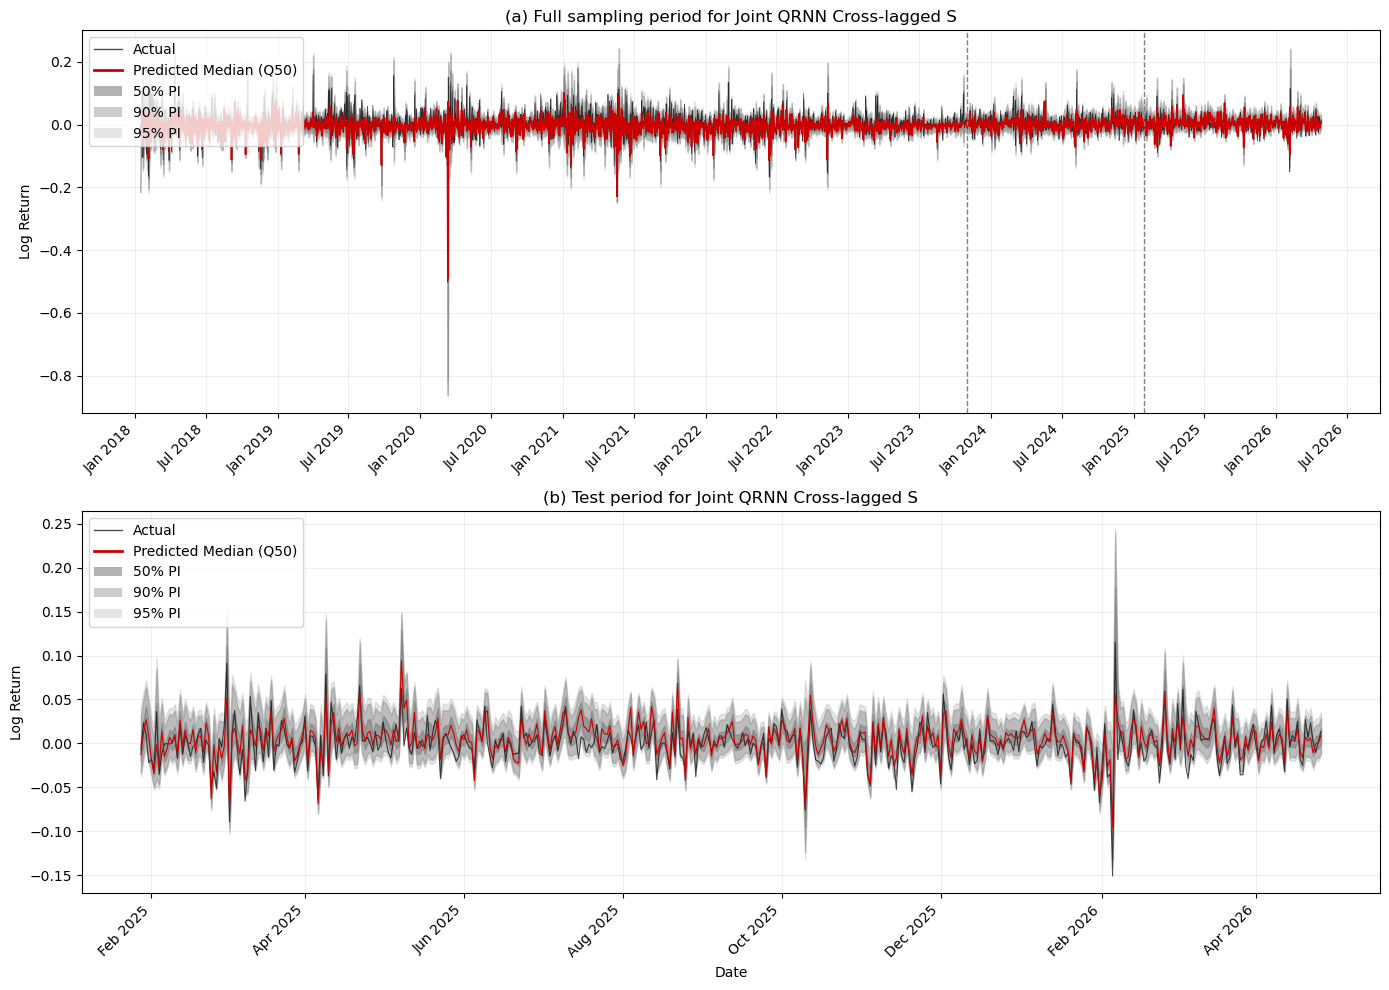

Plot saved to hybrid_qrnn_cross_s_joint_predictions.png

TEST METRICS — JOINT QRNN S CROSS-LAGGED
  alpha         NLL    Hit_Rate         HRE
  0.025   -2.377068    0.041850    0.016850
  0.050   -2.507442    0.085903    0.035903
  0.250   -2.694706    0.396476    0.146476
  0.500   -2.739101    0.662996    0.162996
  0.750   -2.666798    0.905286    0.155286
  0.950   -2.318483    1.000000    0.050000
  0.975   -2.159085    1.000000    0.025000

Average NLL: -2.494669
Average HRE: 0.084644

CROSSOVER ANALYSIS — FINAL HYBRID OUTPUT
(0.025, 0.050): 0 (0.00%) <-- TAIL
(0.050, 0.250): 0 (0.00%)
(0.250, 0.500): 13 (2.86%)
(0.500, 0.750): 0 (0.00%)
(0.750, 0.950): 0 (0.00%)
(0.950, 0.975): 1 (0.22%) <-- TAIL

Total violations: 14 (0.51%)
Tail violations: 1 (0.11%)

CROSSOVER ANALYSIS — MONOTONIC FNN OUTPUT
(0.025, 0.050): 0 (0.00%) <-- TAIL
(0.050, 0.250): 0 (0.00%)
(0.250, 0.500): 0 (0.00%)
(0.500, 0.750): 0 (0.00%)
(0.750, 0.950): 0 (0.00%)
(0.950, 0.975): 0 (0.00%) <-- TAIL

Total violat

In [30]:
# ============================================================
# PLOTTING — JOINT HYBRID QRNN S CROSS-LAGGED
# ============================================================

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from matplotlib.patches import Patch
from matplotlib.lines import Line2D


# ------------------------------------------------------------
# Load best model from tuning
# ------------------------------------------------------------

checkpoint = torch.load(
    'hybrid_qrnn_cross_s_joint_best.pt',
    map_location='cpu',
    weights_only=False
)

alpha_levels = checkpoint['alpha_levels']
best_config_qrnn_cross_s = checkpoint['config']

best_model_qrnn_cross_s = JointHybridQRNNCrossS(
    X_train.shape[1],
    best_config_qrnn_cross_s
)

best_model_qrnn_cross_s.load_state_dict(
    checkpoint['model_state_dict']
)

best_model_qrnn_cross_s.eval()

print("Loaded best trial:", checkpoint['best_trial_number'])
print("Best architecture:", best_config_qrnn_cross_s)


# ------------------------------------------------------------
# Full-sample prediction
# ------------------------------------------------------------

X_all = torch.tensor(
    df[feature_cols].values,
    dtype=torch.float32
)

y_all = torch.tensor(
    df['log_return'].values,
    dtype=torch.float32
)

train_size = len(train_df)
val_size = len(val_df)
test_start = train_size + val_size

with torch.no_grad():

    q_all, caviar_all, fnn_all, sigma = (
        best_model_qrnn_cross_s(
            y_all,
            X_all
        )
    )

q_all_np = q_all.cpu().numpy()
fnn_all_np = fnn_all.cpu().numpy()
sigma_np = sigma.cpu().numpy()

q_test_np = q_all_np[test_start:]
fnn_test_np = fnn_all_np[test_start:]
y_test_np = y_all.cpu().numpy()[test_start:]

all_preds = {
    alpha: q_all_np[:, k]
    for k, alpha in enumerate(alpha_levels)
}

all_fnn_preds = {
    alpha: fnn_all_np[:, k]
    for k, alpha in enumerate(alpha_levels)
}


# ============================================================
# Two-panel prediction plot
# ============================================================

actual_color = '#000000'
pred_color = '#CC0000'
pi_color = '#808080'

all_dates = df.index
test_dates = test_df.index
y_all_np = y_all.cpu().numpy()

legend_elements = [
    Line2D(
        [0], [0],
        color=actual_color,
        lw=1,
        alpha=0.7,
        label='Actual'
    ),
    Line2D(
        [0], [0],
        color=pred_color,
        lw=2,
        label='Predicted Median (Q50)'
    ),
    Patch(
        facecolor=pi_color,
        alpha=0.6,
        label='50% PI'
    ),
    Patch(
        facecolor=pi_color,
        alpha=0.4,
        label='90% PI'
    ),
    Patch(
        facecolor=pi_color,
        alpha=0.2,
        label='95% PI'
    )
]

fig, axes = plt.subplots(
    2, 1,
    figsize=(14, 10)
)


# ------------------------------------------------------------
# Panel (a): full sample
# ------------------------------------------------------------

ax = axes[0]

ax.plot(
    all_dates,
    y_all_np,
    color=actual_color,
    linewidth=0.5,
    alpha=0.7
)

ax.plot(
    all_dates,
    all_preds[0.500],
    color=pred_color,
    linewidth=1.2
)

ax.fill_between(
    all_dates,
    all_preds[0.025],
    all_preds[0.975],
    color=pi_color,
    alpha=0.2
)

ax.fill_between(
    all_dates,
    all_preds[0.050],
    all_preds[0.950],
    color=pi_color,
    alpha=0.4
)

ax.fill_between(
    all_dates,
    all_preds[0.250],
    all_preds[0.750],
    color=pi_color,
    alpha=0.6
)

ax.axvline(
    train_df.index[-1],
    color='gray',
    linestyle='--',
    linewidth=1
)

ax.axvline(
    val_df.index[-1],
    color='gray',
    linestyle='--',
    linewidth=1
)

ax.set_title(
    '(a) Full sampling period for Joint QRNN Cross-lagged S',
    fontsize=12
)

ax.set_ylabel('Log Return')
ax.legend(handles=legend_elements, loc='upper left')
ax.grid(True, alpha=0.2)

ax.xaxis.set_major_formatter(
    mdates.DateFormatter('%b %Y')
)

ax.xaxis.set_major_locator(
    mdates.MonthLocator(interval=6)
)

plt.setp(
    ax.xaxis.get_majorticklabels(),
    rotation=45,
    ha='right'
)


# ------------------------------------------------------------
# Panel (b): test sample
# ------------------------------------------------------------

ax2 = axes[1]

ax2.plot(
    test_dates,
    y_test_np,
    color=actual_color,
    linewidth=0.8,
    alpha=0.7
)

ax2.plot(
    test_dates,
    q_test_np[:, 3],
    color=pred_color,
    linewidth=0.8
)

ax2.fill_between(
    test_dates,
    q_test_np[:, 0],
    q_test_np[:, 6],
    color=pi_color,
    alpha=0.2
)

ax2.fill_between(
    test_dates,
    q_test_np[:, 1],
    q_test_np[:, 5],
    color=pi_color,
    alpha=0.4
)

ax2.fill_between(
    test_dates,
    q_test_np[:, 2],
    q_test_np[:, 4],
    color=pi_color,
    alpha=0.6
)

ax2.set_title(
    '(b) Test period for Joint QRNN Cross-lagged S',
    fontsize=12
)

ax2.set_xlabel('Date')
ax2.set_ylabel('Log Return')
ax2.legend(handles=legend_elements, loc='upper left')
ax2.grid(True, alpha=0.2)

ax2.xaxis.set_major_formatter(
    mdates.DateFormatter('%b %Y')
)

ax2.xaxis.set_major_locator(
    mdates.MonthLocator(interval=2)
)

plt.setp(
    ax2.xaxis.get_majorticklabels(),
    rotation=45,
    ha='right'
)

plt.tight_layout()

plot_filename = (
    'hybrid_qrnn_cross_s_joint_predictions.png'
)

plt.savefig(
    plot_filename,
    dpi=300,
    bbox_inches='tight'
)

plt.show()
plt.close()

print(f"Plot saved to {plot_filename}")


# ============================================================
# Test metrics by quantile level
# ============================================================

def compute_qrnn_test_metrics(
    y_test,
    q_test,
    sigma,
    alpha_levels
):

    nll_values = []
    hit_rates = []
    hre_values = []

    print("\n" + "=" * 65)
    print("TEST METRICS — JOINT QRNN S CROSS-LAGGED")
    print("=" * 65)

    print(
        f"{'alpha':>7}"
        f"{'NLL':>12}"
        f"{'Hit_Rate':>12}"
        f"{'HRE':>12}"
    )

    for k, alpha in enumerate(alpha_levels):

        y_tensor = torch.tensor(
            y_test,
            dtype=torch.float32
        )

        q_tensor = torch.tensor(
            q_test[:, k],
            dtype=torch.float32
        )

        sigma_k = torch.tensor(
            sigma[k],
            dtype=torch.float32
        )

        residual = y_tensor - q_tensor

        indicator = (
            residual < 0
        ).float()

        check_loss = residual * (
            alpha - indicator
        )

        nll = (
            -np.log(alpha * (1.0 - alpha))
            + torch.log(sigma_k)
            + check_loss / sigma_k
        ).mean().item()

        hit_rate = np.mean(
            y_test <= q_test[:, k]
        )

        hre = abs(
            hit_rate - alpha
        )

        nll_values.append(nll)
        hit_rates.append(hit_rate)
        hre_values.append(hre)

        print(
            f"{alpha:>7.3f}"
            f"{nll:>12.6f}"
            f"{hit_rate:>12.6f}"
            f"{hre:>12.6f}"
        )

    average_nll = np.mean(nll_values)
    average_hre = np.mean(hre_values)

    print(f"\nAverage NLL: {average_nll:.6f}")
    print(f"Average HRE: {average_hre:.6f}")

    return {
        'nll_by_level': nll_values,
        'hit_rate_by_level': hit_rates,
        'hre_by_level': hre_values,
        'average_nll': average_nll,
        'average_hre': average_hre
    }


test_metrics_qrnn_cross_s = compute_qrnn_test_metrics(
    y_test_np,
    q_test_np,
    sigma_np,
    alpha_levels
)


# ============================================================
# Crossover analysis
# ============================================================

def crossover_analysis(
    predictions,
    alpha_levels,
    output_name
):

    T = predictions.shape[0]

    tail_pairs = [
        (0.025, 0.050),
        (0.950, 0.975)
    ]

    total_violations = 0
    tail_violations = 0

    print("\n" + "=" * 65)
    print(f"CROSSOVER ANALYSIS — {output_name}")
    print("=" * 65)

    for k in range(len(alpha_levels) - 1):

        lower_alpha = alpha_levels[k]
        upper_alpha = alpha_levels[k + 1]

        violations = int(
            np.sum(
                predictions[:, k]
                > predictions[:, k + 1]
            )
        )

        percentage = (
            violations / T * 100
        )

        pair = (
            lower_alpha,
            upper_alpha
        )

        tail_marker = (
            " <-- TAIL"
            if pair in tail_pairs
            else ""
        )

        print(
            f"({lower_alpha:.3f}, "
            f"{upper_alpha:.3f}): "
            f"{violations} "
            f"({percentage:.2f}%)"
            f"{tail_marker}"
        )

        total_violations += violations

        if pair in tail_pairs:
            tail_violations += violations

    total_rate = (
        total_violations
        / (T * 6)
        * 100
    )

    tail_rate = (
        tail_violations
        / (T * 2)
        * 100
    )

    print(
        f"\nTotal violations: "
        f"{total_violations} "
        f"({total_rate:.2f}%)"
    )

    print(
        f"Tail violations: "
        f"{tail_violations} "
        f"({tail_rate:.2f}%)"
    )

    return {
        'total_violations': total_violations,
        'total_rate': total_rate,
        'tail_violations': tail_violations,
        'tail_rate': tail_rate
    }


final_crossover_qrnn_cross_s = crossover_analysis(
    q_test_np,
    alpha_levels,
    'FINAL HYBRID OUTPUT'
)

fnn_crossover_qrnn_cross_s = crossover_analysis(
    fnn_test_np,
    alpha_levels,
    'MONOTONIC FNN OUTPUT'
)


# ============================================================
# Save test metrics
# ============================================================

metrics_df = pd.DataFrame({
    'alpha': alpha_levels,
    'NLL': test_metrics_qrnn_cross_s['nll_by_level'],
    'Hit_Rate': test_metrics_qrnn_cross_s[
        'hit_rate_by_level'
    ],
    'HRE': test_metrics_qrnn_cross_s['hre_by_level']
})

metrics_df.to_csv(
    'hybrid_qrnn_cross_s_joint_test_metrics.csv',
    index=False
)

print(
    "\nMetrics saved to "
    "hybrid_qrnn_cross_s_joint_test_metrics.csv"
)

# Cross over dealing 1b


In [13]:
import copy

import numpy as np
import optuna
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from optuna.samplers import TPESampler


# ============================================================
# METHOD 1B -- JOINT QRNN S Cross-LAGGED
# Complete-output non-crossing through positive adjacent spacing
# ============================================================

M1B_DISTRIBUTION = 'qrnn'   # 'qrnn' or 'ernn'
M1B_FORM = 's'           # 's' or 'si'
M1B_LAG = 'cross'             # 'self' or 'cross'
M1B_N_TRIALS = 800
M1B_MAX_EPOCHS = 800
M1B_BASE_SEED = 2026

m1b_levels = [0.025, 0.050, 0.250, 0.500, 0.750, 0.950, 0.975]
m1b_spacing_names = [
    'delta12', 'delta23', 'delta34',
    'delta45', 'delta56', 'delta67',
]
m1b_model_tag = (
    f'method1b_joint_{M1B_DISTRIBUTION}_{M1B_FORM}_{M1B_LAG}'
)


def m1b_validate_inputs():
    required = ('y_train', 'X_train', 'y_val', 'X_val')
    missing = [name for name in required if name not in globals()]
    if missing:
        raise NameError(
            'Run the notebook data preparation first. Missing: '
            + ', '.join(missing)
        )

    for y_name, x_name in (
        ('y_train', 'X_train'),
        ('y_val', 'X_val'),
    ):
        y_value = globals()[y_name]
        x_value = globals()[x_name]
        if not isinstance(y_value, torch.Tensor) or not isinstance(
            x_value, torch.Tensor
        ):
            raise TypeError(f'{y_name} and {x_name} must be tensors.')
        if y_value.ndim != 1 or x_value.ndim != 2:
            raise ValueError(f'{y_name} must be (T,) and {x_name} (T,p).')
        if len(y_value) != len(x_value):
            raise ValueError(f'{y_name} and {x_name} lengths differ.')


class Method1BJointHybrid(nn.Module):
    """Central hybrid forecast plus six jointly learned positive gaps."""

    def __init__(self, input_dim, config):
        super().__init__()
        self.eps = 1e-6

        # Identifiable statistical/mixing parameters for the median only.
        self.persistence_raw = nn.Parameter(torch.tensor(1.386))
        self.news1_raw = nn.Parameter(torch.tensor(0.3))
        if M1B_FORM == 'si':
            self.news2_raw = nn.Parameter(torch.tensor(0.3))
        self.psi_raw = nn.Parameter(torch.tensor(0.0))

        # One loss scale per final level.
        self.sigma_raw = nn.Parameter(torch.full((7,), 0.5))

        layers = []
        previous_dim = input_dim
        for index in range(config['n_hidden_layers']):
            hidden_dim = config[f'hidden_dim_{index}']
            layers.append(nn.Linear(previous_dim, hidden_dim))
            if config['layernorm']:
                layers.append(nn.LayerNorm(hidden_dim))
            layers.append(self._activation(config['activation']))
            if config['dropout'] > 0:
                layers.append(nn.Dropout(config['dropout']))
            previous_dim = hidden_dim

        self.feature_extractor = nn.Sequential(*layers)
        self.median_head = nn.Linear(previous_dim, 1)
        self.spacing_heads = nn.ModuleDict({
            name: nn.Linear(previous_dim + 1, 1)
            for name in m1b_spacing_names
        })

        for module in self.modules():
            if isinstance(module, nn.Linear):
                if config['weight_init'] == 'glorot':
                    nn.init.xavier_uniform_(module.weight)
                else:
                    nn.init.kaiming_uniform_(module.weight)
                nn.init.zeros_(module.bias)

    @staticmethod
    def _activation(name):
        return {
            'relu': nn.ReLU(),
            'elu': nn.ELU(),
            'gelu': nn.GELU(),
            'tanh': nn.Tanh(),
        }[name]

    def _positive_spacing(self, features, reference, name):
        spacing_input = torch.cat(
            [features, reference.unsqueeze(1)], dim=1
        )
        raw_spacing = self.spacing_heads[name](spacing_input).squeeze(1)
        return F.softplus(raw_spacing) + self.eps

    def _median_recursion(
        self,
        y,
        median_fnn,
        initial_state=None,
        initial_y=None,
    ):
        if (initial_state is None) != (initial_y is None):
            raise ValueError(
                'initial_state and initial_y must be supplied together.'
            )

        persistence = torch.sigmoid(self.persistence_raw)
        news1 = F.softplus(self.news1_raw)
        news2 = (
            F.softplus(self.news2_raw)
            if M1B_FORM == 'si'
            else None
        )
        psi = torch.sigmoid(self.psi_raw)

        has_state = initial_state is not None
        previous_state = (
            initial_state if has_state else y.new_zeros(())
        )

        statistical_values = []
        hybrid_values = []

        for time_index in range(len(y)):
            if time_index == 0 and not has_state:
                zero = y.new_zeros(())
                statistical_values.append(zero)
                hybrid_values.append(zero)
                continue

            previous_y = (
                initial_y if time_index == 0 else y[time_index - 1]
            )
            absolute_return = torch.abs(previous_y)

            statistical = (
                persistence * previous_state
                + news1 * absolute_return
            )
            if M1B_FORM == 'si':
                statistical = (
                    statistical
                    + news2 * previous_state * absolute_return
                )

            hybrid = psi * statistical + (1 - psi) * median_fnn[
                time_index
            ]
            statistical_values.append(statistical)
            hybrid_values.append(hybrid)

            previous_state = (
                statistical if M1B_LAG == 'self' else hybrid
            )

        return (
            torch.stack(hybrid_values),
            torch.stack(statistical_values),
        )

    def forward(
        self,
        y,
        X,
        initial_state=None,
        initial_y=None,
    ):
        features = self.feature_extractor(X)
        median_fnn = self.median_head(features).squeeze(1)
        median, statistical = self._median_recursion(
            y,
            median_fnn,
            initial_state=initial_state,
            initial_y=initial_y,
        )

        # Outward reconstruction; references remain attached so that
        # all seven losses jointly train the median and inner spacings.
        delta34 = self._positive_spacing(features, median, 'delta34')
        level3 = median - delta34
        delta23 = self._positive_spacing(features, level3, 'delta23')
        level2 = level3 - delta23
        delta12 = self._positive_spacing(features, level2, 'delta12')
        level1 = level2 - delta12

        delta45 = self._positive_spacing(features, median, 'delta45')
        level5 = median + delta45
        delta56 = self._positive_spacing(features, level5, 'delta56')
        level6 = level5 + delta56
        delta67 = self._positive_spacing(features, level6, 'delta67')
        level7 = level6 + delta67

        forecasts = torch.stack(
            [level1, level2, level3, median, level5, level6, level7],
            dim=1,
        )
        spacings = torch.stack(
            [delta12, delta23, delta34, delta45, delta56, delta67],
            dim=1,
        )
        sigma = F.softplus(self.sigma_raw) + self.eps
        continuation_state = (
            statistical if M1B_LAG == 'self' else median
        )
        return forecasts, sigma, continuation_state, statistical, median, spacings


def m1b_joint_nll(y, forecasts, sigma):
    levels = forecasts.new_tensor(m1b_levels)
    residual = y.unsqueeze(1) - forecasts

    if M1B_DISTRIBUTION == 'qrnn':
        indicator = (residual < 0).to(forecasts.dtype)
        check_loss = residual * (levels.unsqueeze(0) - indicator)
        nll = (
            -torch.log(levels * (1 - levels)).unsqueeze(0)
            + torch.log(sigma).unsqueeze(0)
            + check_loss / sigma.unsqueeze(0)
        )
    else:
        weight = torch.abs(
            levels.unsqueeze(0)
            - (residual < 0).to(forecasts.dtype)
        )
        constant = (
            torch.log(
                torch.sqrt(torch.pi / levels)
                + torch.sqrt(torch.pi / (1 - levels))
            )
            - np.log(2.0)
        )
        nll = (
            torch.log(sigma).unsqueeze(0)
            + constant.unsqueeze(0)
            + weight * residual.square() / sigma.square().unsqueeze(0)
        )

    return nll.mean()


def m1b_secondary_metric(y, forecasts):
    levels = forecasts.new_tensor(m1b_levels)
    if M1B_DISTRIBUTION == 'qrnn':
        hit_rate = (y.unsqueeze(1) <= forecasts).float().mean(dim=0)
        by_level = torch.abs(hit_rate - levels)
        return by_level, by_level.mean(), hit_rate

    residual = y.unsqueeze(1) - forecasts
    weight = torch.abs(
        levels.unsqueeze(0)
        - (residual < 0).to(forecasts.dtype)
    )
    by_level = (weight * residual.square()).mean(dim=0)
    return by_level, by_level.mean(), None


def m1b_crossover(forecasts):
    violations = forecasts[:, :-1] > forecasts[:, 1:]
    pair_counts = violations.sum(dim=0)
    sample_size = forecasts.shape[0]
    total = int(pair_counts.sum().item())
    tail = int(pair_counts[0].item() + pair_counts[-1].item())
    return {
        'pair_counts': [int(value) for value in pair_counts.tolist()],
        'total_count': total,
        'total_rate': total / (sample_size * 6),
        'tail_count': tail,
        'tail_rate': tail / (sample_size * 2),
    }


def m1b_suggest_config(trial):
    config = {
        'n_hidden_layers': trial.suggest_int('n_hidden_layers', 1, 3),
        'activation': trial.suggest_categorical(
            'activation', ['relu', 'elu', 'gelu', 'tanh']
        ),
        'dropout': trial.suggest_float('dropout', 0.0, 0.5),
        'layernorm': trial.suggest_categorical(
            'layernorm', [True, False]
        ),
        'weight_init': trial.suggest_categorical(
            'weight_init', ['glorot', 'he']
        ),
        'lr': trial.suggest_float('lr', 1e-4, 5e-2, log=True),
        'optimizer': trial.suggest_categorical(
            'optimizer', ['adam', 'adamw']
        ),
        'weight_decay': trial.suggest_float(
            'weight_decay', 0.0, 1e-4
        ),
        'gradient_clip': trial.suggest_categorical(
            'gradient_clip', [0.1, 1.0, 5.0]
        ),
        'patience': trial.suggest_categorical(
            'patience', [10, 20, 30]
        ),
    }
    for index in range(config['n_hidden_layers']):
        config[f'hidden_dim_{index}'] = trial.suggest_int(
            f'hidden_dim_{index}', 32, 256
        )
    return config


def m1b_fit(config, max_epochs=M1B_MAX_EPOCHS, seed=M1B_BASE_SEED):
    torch.manual_seed(seed)
    np.random.seed(seed)
    model = Method1BJointHybrid(X_train.shape[1], config)
    optimizer_class = (
        torch.optim.Adam
        if config['optimizer'] == 'adam'
        else torch.optim.AdamW
    )
    optimizer = optimizer_class(
        model.parameters(),
        lr=config['lr'],
        weight_decay=config['weight_decay'],
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', patience=10, factor=0.5, min_lr=1e-6
    )

    best_loss = float('inf')
    best_state = None
    patience_counter = 0

    for _ in range(max_epochs):
        model.train()
        optimizer.zero_grad()
        train_forecasts, sigma, _, _, _, _ = model(y_train, X_train)
        train_loss = m1b_joint_nll(
            y_train[1:], train_forecasts[1:], sigma
        )
        if not torch.isfinite(train_loss):
            return None
        train_loss.backward()
        nn.utils.clip_grad_norm_(
            model.parameters(), config['gradient_clip']
        )
        optimizer.step()

        model.eval()
        with torch.no_grad():
            _, _, train_state, _, _, _ = model(y_train, X_train)
            validation_forecasts, validation_sigma, _, _, _, _ = model(
                y_val,
                X_val,
                initial_state=train_state[-1],
                initial_y=y_train[-1],
            )
            validation_loss = m1b_joint_nll(
                y_val, validation_forecasts, validation_sigma
            )

        if not torch.isfinite(validation_loss):
            return None
        scheduler.step(validation_loss.item())
        if validation_loss.item() < best_loss:
            best_loss = validation_loss.item()
            best_state = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= config['patience']:
                break

    if best_state is None:
        return None
    model.load_state_dict(best_state)
    return model


def m1b_evaluate(model):
    model.eval()
    with torch.no_grad():
        _, _, train_state, _, _, _ = model(y_train, X_train)
        forecasts, sigma, _, _, _, spacings = model(
            y_val,
            X_val,
            initial_state=train_state[-1],
            initial_y=y_train[-1],
        )
        mean_nll = m1b_joint_nll(y_val, forecasts, sigma).item()
        by_level, secondary, hit_rate = m1b_secondary_metric(
            y_val, forecasts
        )

        metrics = {
            'mean_nll': mean_nll,
            'secondary': secondary.item(),
            'secondary_by_level': by_level.tolist(),
            'crossover': m1b_crossover(forecasts),
            'spacing_mean': spacings.mean(dim=0).tolist(),
            'spacing_min': spacings.min(dim=0).values.tolist(),
            'spacing_max': spacings.max(dim=0).values.tolist(),
            'spacing_std': spacings.std(
                dim=0, unbiased=False
            ).tolist(),
            'near_zero_count': (
                spacings <= 1e-5
            ).sum(dim=0).tolist(),
            'persistence': torch.sigmoid(
                model.persistence_raw
            ).item(),
            'news1': F.softplus(model.news1_raw).item(),
            'news2': (
                F.softplus(model.news2_raw).item()
                if M1B_FORM == 'si'
                else np.nan
            ),
            'psi': torch.sigmoid(model.psi_raw).item(),
            'sigma': (
                F.softplus(model.sigma_raw) + model.eps
            ).tolist(),
        }
        if hit_rate is not None:
            metrics['hit_rate'] = hit_rate.tolist()
        return metrics


def m1b_objective(trial):
    config = m1b_suggest_config(trial)
    model = m1b_fit(config)
    if model is None:
        return float('inf')
    metrics = m1b_evaluate(model)
    for name, value in metrics.items():
        trial.set_user_attr(name, value)
    metric_name = 'HRE' if M1B_DISTRIBUTION == 'qrnn' else 'ASE'
    print(
        f"Trial {trial.number}: NLL={metrics['mean_nll']:.6f} | "
        f"{metric_name}={metrics['secondary']:.8f} | "
        f"crossover={metrics['crossover']['total_rate']:.2%}"
    )
    return metrics['mean_nll']


def m1b_select_by_rank(study):
    trials = [
        trial for trial in study.trials
        if trial.state == optuna.trial.TrialState.COMPLETE
        and trial.value is not None
        and np.isfinite(trial.value)
        and 'mean_nll' in trial.user_attrs
        and 'secondary' in trial.user_attrs
    ]
    if not trials:
        raise RuntimeError('No valid Method 1b trials.')

    nll_order = sorted(
        trials,
        key=lambda trial: (trial.user_attrs['mean_nll'], trial.number),
    )
    secondary_order = sorted(
        trials,
        key=lambda trial: (trial.user_attrs['secondary'], trial.number),
    )
    rank_nll = {
        trial.number: rank
        for rank, trial in enumerate(nll_order, 1)
    }
    rank_secondary = {
        trial.number: rank
        for rank, trial in enumerate(secondary_order, 1)
    }
    best = min(
        trials,
        key=lambda trial: (
            rank_nll[trial.number] + rank_secondary[trial.number],
            trial.user_attrs['mean_nll'],
            trial.user_attrs['secondary'],
            trial.number,
        ),
    )
    return best, trials, rank_nll, rank_secondary


m1b_validate_inputs()
print('\n' + '=' * 72)
print(
    f'Tuning Method 1b Joint {M1B_DISTRIBUTION.upper()} '
    f'{M1B_FORM.upper()} {M1B_LAG.title()}-lagged'
)
print('=' * 72)

m1b_study = optuna.create_study(
    direction='minimize',
    sampler=TPESampler(seed=M1B_BASE_SEED),
)
m1b_study.optimize(
    m1b_objective,
    n_trials=M1B_N_TRIALS,
    show_progress_bar=True,
)

(
    m1b_best_trial,
    m1b_all_trials,
    m1b_rank_nll,
    m1b_rank_secondary,
) = m1b_select_by_rank(m1b_study)

m1b_ranking_records = []
for trial in m1b_all_trials:
    record = {
        'trial': trial.number,
        'mean_nll': trial.user_attrs['mean_nll'],
        ('mean_hre' if M1B_DISTRIBUTION == 'qrnn' else 'mean_ase'):
            trial.user_attrs['secondary'],
        'rank_nll': m1b_rank_nll[trial.number],
        'rank_secondary': m1b_rank_secondary[trial.number],
        'sum_rank': (
            m1b_rank_nll[trial.number]
            + m1b_rank_secondary[trial.number]
        ),
        'crossover_count': trial.user_attrs['crossover']['total_count'],
        'crossover_rate': trial.user_attrs['crossover']['total_rate'],
        'tail_count': trial.user_attrs['crossover']['tail_count'],
        'tail_rate': trial.user_attrs['crossover']['tail_rate'],
        'persistence': trial.user_attrs['persistence'],
        'news1': trial.user_attrs['news1'],
        'news2': trial.user_attrs['news2'],
        'psi': trial.user_attrs['psi'],
    }
    for index, level in enumerate(m1b_levels):
        metric_label = 'hre' if M1B_DISTRIBUTION == 'qrnn' else 'ase'
        record[f'{metric_label}_{level:.3f}'] = trial.user_attrs[
            'secondary_by_level'
        ][index]
        record[f'sigma_{level:.3f}'] = trial.user_attrs['sigma'][index]
    record.update(trial.params)
    m1b_ranking_records.append(record)

m1b_ranking_df = pd.DataFrame(m1b_ranking_records).sort_values(
    ['sum_rank', 'mean_nll', 'trial']
)
m1b_ranking_filename = f'{m1b_model_tag}_ranking.csv'
m1b_ranking_df.to_csv(m1b_ranking_filename, index=False)

m1b_best_config = m1b_best_trial.params.copy()
m1b_best_model = m1b_fit(m1b_best_config)
if m1b_best_model is None:
    raise RuntimeError('Selected Method 1b configuration failed to refit.')
m1b_best_metrics = m1b_evaluate(m1b_best_model)

m1b_checkpoint_filename = f'{m1b_model_tag}_best.pt'
torch.save(
    {
        'model_state_dict': m1b_best_model.state_dict(),
        'config': m1b_best_config,
        'levels': m1b_levels,
        'distribution': M1B_DISTRIBUTION,
        'form': M1B_FORM,
        'lag': M1B_LAG,
        'validation_metrics': m1b_best_metrics,
    },
    m1b_checkpoint_filename,
)

m1b_metric_name = 'HRE' if M1B_DISTRIBUTION == 'qrnn' else 'ASE'
print('\n' + '=' * 72)
print('METHOD 1B TUNING COMPLETE')
print('=' * 72)
print(f'Best trial: #{m1b_best_trial.number}')
print(f"Mean validation NLL: {m1b_best_metrics['mean_nll']:.6f}")
print(
    f"Mean validation {m1b_metric_name}: "
    f"{m1b_best_metrics['secondary']:.8f}"
)
print(
    f"Final crossover: {m1b_best_metrics['crossover']['total_count']} "
    f"({m1b_best_metrics['crossover']['total_rate']:.2%})"
)
print(f'Saved ranking: {m1b_ranking_filename}')
print(f'Saved model: {m1b_checkpoint_filename}')



[I 2026-08-23 17:42:53,379] A new study created in memory with name: no-name-e5c1c640-f212-49fe-974e-813cd2f35d06



Tuning Method 1b Joint QRNN S Cross-lagged


  0%|          | 0/800 [00:00<?, ?it/s]

Trial 0: NLL=2.215446 | HRE=0.19175339 | crossover=0.00%
[I 2026-08-23 17:44:35,616] Trial 0 finished with value: 2.2154464721679688 and parameters: {'n_hidden_layers': 1, 'activation': 'elu', 'dropout': 0.49377524711883497, 'layernorm': False, 'weight_init': 'he', 'lr': 0.0006552020421842752, 'optimizer': 'adam', 'weight_decay': 8.940884610144999e-05, 'gradient_clip': 5.0, 'patience': 30, 'hidden_dim_0': 38}. Best is trial 0 with value: 2.2154464721679688.
Trial 1: NLL=-1.582042 | HRE=0.10029960 | crossover=0.00%
[I 2026-08-23 17:46:12,888] Trial 1 finished with value: -1.5820417404174805 and parameters: {'n_hidden_layers': 1, 'activation': 'tanh', 'dropout': 0.07458356653667625, 'layernorm': False, 'weight_init': 'he', 'lr': 0.006969178688110181, 'optimizer': 'adam', 'weight_decay': 2.574006001095316e-05, 'gradient_clip': 1.0, 'patience': 30, 'hidden_dim_0': 102}. Best is trial 1 with value: -1.5820417404174805.
Trial 2: NLL=2.605224 | HRE=0.16113213 | crossover=0.00%
[I 2026-08-23 1

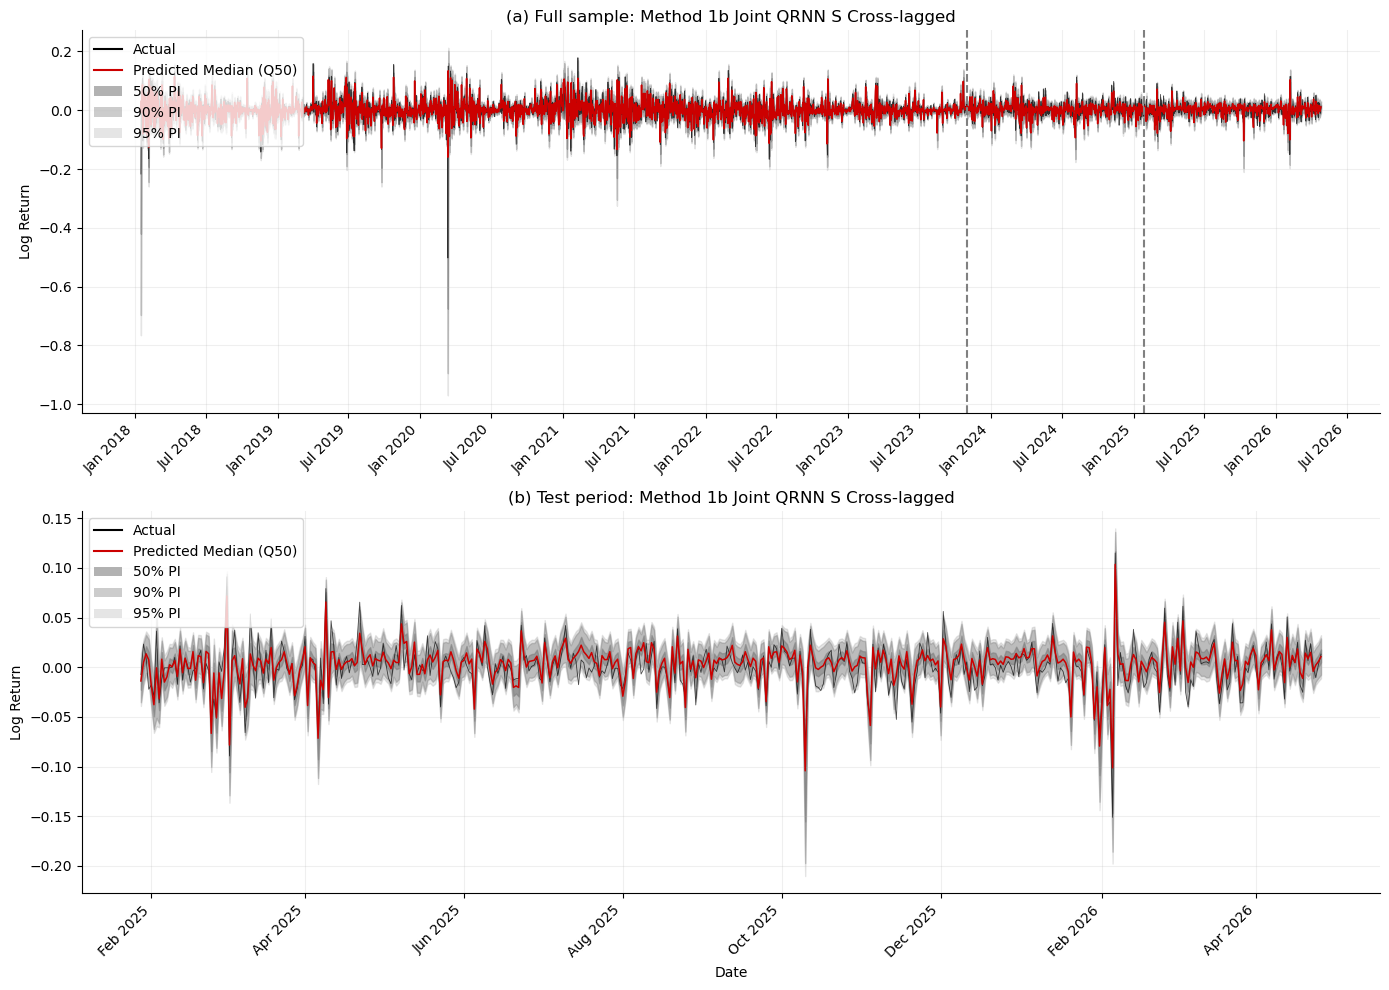

Plot saved to: method1b_joint_qrnn_s_cross_predictions.png

TEST METRICS -- METHOD 1B JOINT QRNN S CROSS-LAGGED
 level       NLL  Hit_Rate      HRE    sigma
 0.025 -2.439253  0.046256 0.021256 0.001263
 0.050 -2.582657  0.088106 0.038106 0.001958
 0.250 -2.794429  0.418502 0.168502 0.005181
 0.500 -2.882120  0.658590 0.158590 0.006362
 0.750 -2.825939  0.830396 0.080396 0.005156
 0.950 -2.503969  0.969163 0.019163 0.001983
 0.975 -2.352816  0.975771 0.000771 0.001286

Average NLL: -2.625884
Average HRE: 0.06954060

CROSSOVER ANALYSIS -- FINAL METHOD 1B FORECASTS
 Lower  Upper  Violations  Rate
 0.025  0.050           0   0.0
 0.050  0.250           0   0.0
 0.250  0.500           0   0.0
 0.500  0.750           0   0.0
 0.750  0.950           0   0.0
 0.950  0.975           0   0.0

Total violations: 0
Tail violations: 0

LEARNED SPACING DIAGNOSTICS -- TEST PERIOD
Spacing  Lower_Level  Upper_Level  Mean_Delta  Minimum_Delta  Maximum_Delta  Delta_Std  Near_Zero_Count  Near_Zero_Rate
del

In [15]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from matplotlib.lines import Line2D
from matplotlib.patches import Patch


# ============================================================
# PLOT AND EVALUATE METHOD 1B -- QRNN S
# Cross-LAGGED
# ============================================================

m1b_plot_pairs = list(zip(m1b_levels[:-1], m1b_levels[1:]))
m1b_plot_tail_pairs = [(0.025, 0.050), (0.950, 0.975)]

if 'm1b_best_model' not in globals():
    m1b_plot_checkpoint_filename = f'{m1b_model_tag}_best.pt'
    m1b_plot_checkpoint = torch.load(
        m1b_plot_checkpoint_filename,
        map_location='cpu',
        weights_only=False,
    )
    m1b_best_model = Method1BJointHybrid(
        X_train.shape[1], m1b_plot_checkpoint['config']
    )
    m1b_best_model.load_state_dict(
        m1b_plot_checkpoint['model_state_dict']
    )

m1b_best_model.eval()

m1b_plot_X_all = torch.tensor(
    df[feature_cols].values, dtype=torch.float32
)
m1b_plot_y_all = torch.tensor(
    df['log_return'].values, dtype=torch.float32
)

with torch.no_grad():
    (
        m1b_plot_forecasts_all,
        m1b_plot_sigma,
        _,
        _,
        _,
        m1b_plot_spacings_all,
    ) = m1b_best_model(m1b_plot_y_all, m1b_plot_X_all)

m1b_plot_forecasts_np = m1b_plot_forecasts_all.cpu().numpy()
m1b_plot_spacings_np = m1b_plot_spacings_all.cpu().numpy()
m1b_plot_test_start = len(train_df) + len(val_df)
m1b_plot_forecasts_test = m1b_plot_forecasts_all[
    m1b_plot_test_start:
]
m1b_plot_spacings_test = m1b_plot_spacings_all[m1b_plot_test_start:]
m1b_plot_y_test = m1b_plot_y_all[m1b_plot_test_start:]

if len(m1b_plot_forecasts_test) != len(test_df):
    raise ValueError(
        'Test forecast length does not match test_df. Check the split.'
    )


def m1b_draw_panel(axis, dates, actual, forecasts):
    axis.plot(dates, actual, color='#000000', linewidth=0.6, alpha=0.7)
    axis.plot(
        dates, forecasts[:, 3], color='#CC0000', linewidth=1.1
    )
    axis.fill_between(
        dates, forecasts[:, 0], forecasts[:, 6],
        color='#808080', alpha=0.20,
    )
    axis.fill_between(
        dates, forecasts[:, 1], forecasts[:, 5],
        color='#808080', alpha=0.40,
    )
    axis.fill_between(
        dates, forecasts[:, 2], forecasts[:, 4],
        color='#808080', alpha=0.60,
    )
    axis.set_ylabel('Log Return')
    axis.grid(True, alpha=0.2)
    axis.spines['top'].set_visible(False)
    axis.spines['right'].set_visible(False)


m1b_plot_distribution_label = M1B_DISTRIBUTION.upper()
m1b_plot_form_label = M1B_FORM.upper()
m1b_plot_lag_label = M1B_LAG.title()
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

m1b_draw_panel(
    axes[0], df.index, df['log_return'].values, m1b_plot_forecasts_np
)
axes[0].axvline(train_df.index[-1], color='gray', linestyle='--')
axes[0].axvline(val_df.index[-1], color='gray', linestyle='--')
axes[0].set_title(
    f'(a) Full sample: Method 1b Joint {m1b_plot_distribution_label} '
    f'{m1b_plot_form_label} {m1b_plot_lag_label}-lagged'
)
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[0].xaxis.set_major_locator(mdates.MonthLocator(interval=6))

m1b_draw_panel(
    axes[1],
    test_df.index,
    test_df['log_return'].values,
    m1b_plot_forecasts_np[m1b_plot_test_start:],
)
axes[1].set_title(
    f'(b) Test period: Method 1b Joint '
    f'{m1b_plot_distribution_label} {m1b_plot_form_label} '
    f'{m1b_plot_lag_label}-lagged'
)
axes[1].set_xlabel('Date')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=2))

if M1B_DISTRIBUTION == 'qrnn':
    median_label = 'Predicted Median (Q50)'
    band_labels = ['50% PI', '90% PI', '95% PI']
else:
    median_label = 'Predicted median expectile'
    band_labels = [
        '0.25--0.75 expectile band',
        '0.05--0.95 expectile band',
        '0.025--0.975 expectile band',
    ]

m1b_legend = [
    Line2D([0], [0], color='#000000', label='Actual'),
    Line2D([0], [0], color='#CC0000', label=median_label),
    Patch(facecolor='#808080', alpha=0.60, label=band_labels[0]),
    Patch(facecolor='#808080', alpha=0.40, label=band_labels[1]),
    Patch(facecolor='#808080', alpha=0.20, label=band_labels[2]),
]
for axis in axes:
    axis.legend(handles=m1b_legend, loc='upper left')
    plt.setp(
        axis.xaxis.get_majorticklabels(), rotation=45, ha='right'
    )

plt.tight_layout()
m1b_plot_png = f'{m1b_model_tag}_predictions.png'
plt.savefig(m1b_plot_png, dpi=300, bbox_inches='tight')
plt.show()
plt.close()
print(f'Plot saved to: {m1b_plot_png}')


# ============================================================
# Test metrics by level
# ============================================================

m1b_plot_metric_rows = []
for index, level in enumerate(m1b_levels):
    forecast = m1b_plot_forecasts_test[:, index]
    sigma = m1b_plot_sigma[index]
    residual = m1b_plot_y_test - forecast

    if M1B_DISTRIBUTION == 'qrnn':
        indicator = (residual < 0).to(residual.dtype)
        check_loss = residual * (level - indicator)
        nll = (
            -torch.log(residual.new_tensor(level * (1 - level)))
            + torch.log(sigma)
            + check_loss / sigma
        ).mean().item()
        hit_rate = (
            m1b_plot_y_test <= forecast
        ).float().mean().item()
        secondary = abs(hit_rate - level)
        row = {
            'level': level,
            'NLL': nll,
            'Hit_Rate': hit_rate,
            'HRE': secondary,
            'sigma': sigma.item(),
        }
    else:
        weight = torch.abs(
            residual.new_tensor(level)
            - (residual < 0).to(residual.dtype)
        )
        weighted_squared_error = weight * residual.square()
        constant = (
            torch.log(
                torch.sqrt(residual.new_tensor(torch.pi / level))
                + torch.sqrt(
                    residual.new_tensor(torch.pi / (1 - level))
                )
            )
            - np.log(2.0)
        )
        nll = (
            torch.log(sigma)
            + constant
            + weighted_squared_error / sigma.square()
        ).mean().item()
        secondary = weighted_squared_error.mean().item()
        row = {
            'level': level,
            'NLL': nll,
            'ASE': secondary,
            'sigma': sigma.item(),
        }

    m1b_plot_metric_rows.append(row)

m1b_plot_metrics_df = pd.DataFrame(m1b_plot_metric_rows)
m1b_plot_metric_column = (
    'HRE' if M1B_DISTRIBUTION == 'qrnn' else 'ASE'
)
print('\n' + '=' * 72)
print(
    f'TEST METRICS -- METHOD 1B JOINT '
    f'{m1b_plot_distribution_label} {m1b_plot_form_label} '
    f'{m1b_plot_lag_label.upper()}-LAGGED'
)
print('=' * 72)
print(m1b_plot_metrics_df.to_string(index=False))
print(f"\nAverage NLL: {m1b_plot_metrics_df['NLL'].mean():.6f}")
print(
    f'Average {m1b_plot_metric_column}: '
    f"{m1b_plot_metrics_df[m1b_plot_metric_column].mean():.8f}"
)


# ============================================================
# Crossover and learned-spacing diagnostics
# ============================================================

m1b_plot_crossover_rows = []
for index, (lower, upper) in enumerate(m1b_plot_pairs):
    count = int((
        m1b_plot_forecasts_test[:, index]
        > m1b_plot_forecasts_test[:, index + 1]
    ).sum().item())
    m1b_plot_crossover_rows.append({
        'Lower': lower,
        'Upper': upper,
        'Violations': count,
        'Rate': count / len(m1b_plot_y_test),
    })

m1b_plot_crossover_df = pd.DataFrame(m1b_plot_crossover_rows)
m1b_plot_total = int(m1b_plot_crossover_df['Violations'].sum())
m1b_plot_tail = int(
    m1b_plot_crossover_df.iloc[0]['Violations']
    + m1b_plot_crossover_df.iloc[-1]['Violations']
)
print('\n' + '=' * 72)
print('CROSSOVER ANALYSIS -- FINAL METHOD 1B FORECASTS')
print('=' * 72)
print(m1b_plot_crossover_df.to_string(index=False))
print(f'\nTotal violations: {m1b_plot_total}')
print(f'Tail violations: {m1b_plot_tail}')

m1b_plot_spacing_rows = []
for index, (name, pair) in enumerate(zip(
    m1b_spacing_names, m1b_plot_pairs
)):
    spacing = m1b_plot_spacings_test[:, index]
    m1b_plot_spacing_rows.append({
        'Spacing': name,
        'Lower_Level': pair[0],
        'Upper_Level': pair[1],
        'Mean_Delta': spacing.mean().item(),
        'Minimum_Delta': spacing.min().item(),
        'Maximum_Delta': spacing.max().item(),
        'Delta_Std': spacing.std(unbiased=False).item(),
        'Near_Zero_Count': int((spacing <= 1e-5).sum().item()),
        'Near_Zero_Rate': (
            spacing <= 1e-5
        ).float().mean().item(),
    })

m1b_plot_spacing_df = pd.DataFrame(m1b_plot_spacing_rows)
print('\n' + '=' * 72)
print('LEARNED SPACING DIAGNOSTICS -- TEST PERIOD')
print('=' * 72)
print(m1b_plot_spacing_df.to_string(index=False))


# ============================================================
# Detailed predictions and saved outputs
# ============================================================

m1b_plot_predictions_df = pd.DataFrame({
    'Date': pd.to_datetime(test_df.index),
    'Actual': test_df['log_return'].values,
})
m1b_plot_prefix = 'Q' if M1B_DISTRIBUTION == 'qrnn' else 'E'
for index, level in enumerate(m1b_levels):
    m1b_plot_predictions_df[f'{m1b_plot_prefix}_{level:.3f}'] = (
        m1b_plot_forecasts_np[m1b_plot_test_start:, index]
    )
for index, (lower, upper) in enumerate(m1b_plot_pairs):
    m1b_plot_predictions_df[
        f'Gap_{lower:.3f}_{upper:.3f}'
    ] = m1b_plot_spacings_np[m1b_plot_test_start:, index]

m1b_plot_metrics_file = f'{m1b_model_tag}_test_metrics.csv'
m1b_plot_crossover_file = f'{m1b_model_tag}_crossover.csv'
m1b_plot_spacing_file = f'{m1b_model_tag}_delta_summary.csv'
m1b_plot_predictions_file = f'{m1b_model_tag}_test_predictions.csv'

m1b_plot_metrics_df.to_csv(m1b_plot_metrics_file, index=False)
m1b_plot_crossover_df.to_csv(m1b_plot_crossover_file, index=False)
m1b_plot_spacing_df.to_csv(m1b_plot_spacing_file, index=False)
m1b_plot_predictions_df.to_csv(m1b_plot_predictions_file, index=False)

print('\nSaved Method 1b outputs:')
for filename in (
    m1b_plot_png,
    m1b_plot_metrics_file,
    m1b_plot_crossover_file,
    m1b_plot_spacing_file,
    m1b_plot_predictions_file,
):
    print(f'  {filename}')



# Cross over dealing2 

In [36]:
import copy

import numpy as np
import optuna
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from optuna.samplers import TPESampler


# ============================================================
# METHOD 2 -- SEQUENTIAL HYBRID QRNN S CROSS-LAGGED
# Seven separate models; 200 Optuna trials per level
# Selection: validation NLL rank + validation HRE rank
# ============================================================

m2_qrnn_cross_s_levels = [
    0.025, 0.050, 0.250, 0.500, 0.750, 0.950, 0.975
]

m2_qrnn_cross_s_order = [
    0.500, 0.750, 0.950, 0.975, 0.250, 0.050, 0.025
]

m2_qrnn_cross_s_reference = {
    0.500: None,
    0.750: 0.500,
    0.950: 0.750,
    0.975: 0.950,
    0.250: 0.500,
    0.050: 0.250,
    0.025: 0.050,
}

m2_qrnn_cross_s_direction = {
    0.500: None,
    0.750: 'upper',
    0.950: 'upper',
    0.975: 'upper',
    0.250: 'lower',
    0.050: 'lower',
    0.025: 'lower',
}

M2_QRNN_CROSS_S_DELTA = 1e-6
M2_QRNN_CROSS_S_SMOOTH_A = 1e-3
M2_QRNN_CROSS_S_PSI_MARGIN = 1e-4
M2_QRNN_CROSS_S_N_TRIALS = 200
M2_QRNN_CROSS_S_MAX_EPOCHS = 200
M2_QRNN_CROSS_S_BASE_SEED = 2026


def m2_qrnn_cross_s_scaled_softplus(x):
    return M2_QRNN_CROSS_S_SMOOTH_A * F.softplus(
        x / M2_QRNN_CROSS_S_SMOOTH_A
    )


class M2SequentialQRNNCrossS(nn.Module):
    def __init__(self, input_dim, config, direction=None):
        super().__init__()

        self.direction = direction

        self.beta1_raw = nn.Parameter(torch.tensor(1.386))
        self.beta2_raw = nn.Parameter(torch.tensor(0.3))
        self.psi_raw = nn.Parameter(torch.tensor(0.0))
        self.sigma_raw = nn.Parameter(torch.tensor(0.5))

        fnn_input_dim = input_dim if direction is None else input_dim + 1
        layers = []
        prev_dim = fnn_input_dim

        for i in range(config['n_hidden_layers']):
            hidden_dim = config[f'hidden_dim_{i}']
            layers.append(nn.Linear(prev_dim, hidden_dim))

            if config['layernorm']:
                layers.append(nn.LayerNorm(hidden_dim))

            layers.append(self._get_activation(config['activation']))

            if config['dropout'] > 0:
                layers.append(nn.Dropout(config['dropout']))

            prev_dim = hidden_dim

        layers.append(nn.Linear(prev_dim, 1))
        self.fnn = nn.Sequential(*layers)

        for module in self.fnn.modules():
            if isinstance(module, nn.Linear):
                if config['weight_init'] == 'glorot':
                    nn.init.xavier_uniform_(module.weight)
                elif config['weight_init'] == 'he':
                    nn.init.kaiming_uniform_(module.weight)

                if module.bias is not None:
                    nn.init.zeros_(module.bias)

    def _get_activation(self, name):
        return {
            'relu': nn.ReLU(),
            'elu': nn.ELU(),
            'gelu': nn.GELU(),
            'tanh': nn.Tanh(),
        }.get(name, nn.ReLU())

    def constrain_fnn(self, f_raw, caviar, q_reference, psi):
        denominator = 1.0 - psi

        if self.direction == 'upper':
            boundary = (
                q_reference
                + M2_QRNN_CROSS_S_DELTA
                - psi * caviar
            ) / denominator

            return boundary + m2_qrnn_cross_s_scaled_softplus(
                f_raw - boundary
            )

        if self.direction == 'lower':
            boundary = (
                q_reference
                - M2_QRNN_CROSS_S_DELTA
                - psi * caviar
            ) / denominator

            return boundary - m2_qrnn_cross_s_scaled_softplus(
                boundary - f_raw
            )

        return f_raw

    def forward(
        self,
        y,
        X,
        q_reference=None,
        initial_hybrid=None,
        initial_y=None,
    ):
        beta1 = torch.sigmoid(self.beta1_raw)
        beta2 = F.softplus(self.beta2_raw)
        psi = (
            1.0 - M2_QRNN_CROSS_S_PSI_MARGIN
        ) * torch.sigmoid(self.psi_raw)
        sigma = F.softplus(self.sigma_raw) + 1e-6

        if self.direction is None:
            X_fnn = X
        else:
            if q_reference is None:
                raise ValueError(
                    'Reference forecasts are required for non-median models.'
                )

            q_reference = q_reference.detach()
            X_fnn = torch.cat([X, q_reference.unsqueeze(1)], dim=1)

        f_raw = self.fnn(X_fnn).squeeze(-1)

        if (initial_hybrid is None) != (initial_y is None):
            raise ValueError(
                'initial_hybrid and initial_y must be supplied together.'
            )

        has_initial_state = initial_hybrid is not None
        previous_hybrid = (
            initial_hybrid
            if has_initial_state
            else torch.zeros((), dtype=y.dtype, device=y.device)
        )

        q_hybrid_list = []
        q_caviar_list = []
        f_constrained_list = []

        for t in range(len(y)):
            if t == 0 and not has_initial_state:
                caviar_t = torch.zeros((), dtype=y.dtype, device=y.device)

                if self.direction is None:
                    f_constrained_t = f_raw[t]
                    hybrid_t = torch.zeros((), dtype=y.dtype, device=y.device)
                else:
                    f_constrained_t = self.constrain_fnn(
                        f_raw[t], caviar_t, q_reference[t], psi
                    )
                    hybrid_t = (
                        psi * caviar_t
                        + (1.0 - psi) * f_constrained_t
                    )
            else:
                previous_y = initial_y if t == 0 else y[t - 1]

                # Symmetric cross-lagged CAViaR:
                # the lag is the previous final hybrid output.
                caviar_t = (
                    beta1 * previous_hybrid
                    + beta2 * torch.abs(previous_y)
                )

                if self.direction is None:
                    f_constrained_t = f_raw[t]
                else:
                    f_constrained_t = self.constrain_fnn(
                        f_raw[t], caviar_t, q_reference[t], psi
                    )

                hybrid_t = (
                    psi * caviar_t
                    + (1.0 - psi) * f_constrained_t
                )

            q_caviar_list.append(caviar_t)
            f_constrained_list.append(f_constrained_t)
            q_hybrid_list.append(hybrid_t)
            previous_hybrid = hybrid_t

        return (
            torch.stack(q_hybrid_list),
            torch.stack(q_caviar_list),
            f_raw,
            torch.stack(f_constrained_list),
            sigma,
        )


def m2_qrnn_cross_s_loss(y, q, sigma, alpha):
    residual = y - q
    indicator = (residual < 0).float()
    rho = residual * (alpha - indicator)
    alpha_constant = torch.tensor(
        alpha * (1.0 - alpha), dtype=y.dtype, device=y.device
    )

    return (
        -torch.log(alpha_constant)
        + torch.log(sigma)
        + rho / sigma
    ).mean()


def m2_qrnn_cross_s_hre(y, q, alpha):
    hit_rate = (y <= q).float().mean()
    hre = torch.abs(
        hit_rate
        - torch.tensor(alpha, dtype=q.dtype, device=q.device)
    )
    return hit_rate.item(), hre.item()


def m2_qrnn_cross_s_suggest_config(trial):
    config = {
        'n_hidden_layers': trial.suggest_int('n_hidden_layers', 1, 3),
        'activation': trial.suggest_categorical(
            'activation', ['relu', 'elu', 'gelu', 'tanh']
        ),
        'dropout': trial.suggest_float('dropout', 0.0, 0.5),
        'layernorm': trial.suggest_categorical('layernorm', [True, False]),
        'weight_init': trial.suggest_categorical(
            'weight_init', ['glorot', 'he']
        ),
        'lr': trial.suggest_float('lr', 1e-4, 5e-2, log=True),
        'optimizer': trial.suggest_categorical(
            'optimizer', ['adam', 'adamw']
        ),
        'weight_decay': trial.suggest_float('weight_decay', 0.0, 1e-4),
        'gradient_clip': trial.suggest_categorical(
            'gradient_clip', [0.1, 1.0, 5.0]
        ),
        'patience': trial.suggest_categorical('patience', [10, 20, 30]),
    }

    for i in range(config['n_hidden_layers']):
        config[f'hidden_dim_{i}'] = trial.suggest_int(
            f'hidden_dim_{i}', 32, 256
        )

    return config


def m2_qrnn_cross_s_make_optimizer(model, config):
    optimizer_class = (
        torch.optim.Adam
        if config['optimizer'] == 'adam'
        else torch.optim.AdamW
    )
    return optimizer_class(
        model.parameters(),
        lr=config['lr'],
        weight_decay=config['weight_decay'],
    )


def m2_qrnn_cross_s_train_config(
    config,
    alpha,
    direction,
    q_reference_train=None,
    q_reference_val=None,
    seed=2026,
):
    torch.manual_seed(seed)

    model = M2SequentialQRNNCrossS(
        input_dim=X_train.shape[1],
        config=config,
        direction=direction,
    )
    optimizer = m2_qrnn_cross_s_make_optimizer(model, config)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', patience=10, factor=0.5, min_lr=1e-6
    )

    best_val_loss = float('inf')
    patience_counter = 0
    best_model_state = None

    for epoch in range(M2_QRNN_CROSS_S_MAX_EPOCHS):
        model.train()
        optimizer.zero_grad()

        q_train, _, _, _, sigma = model(
            y_train, X_train, q_reference_train
        )
        train_loss = m2_qrnn_cross_s_loss(
            y_train[1:], q_train[1:], sigma, alpha
        )

        if torch.isnan(train_loss) or torch.isinf(train_loss):
            return None

        train_loss.backward()
        nn.utils.clip_grad_norm_(
            model.parameters(), config['gradient_clip']
        )
        optimizer.step()

        model.eval()
        with torch.no_grad():
            q_train_state, _, _, _, _ = model(
                y_train, X_train, q_reference_train
            )
            q_val, _, _, _, sigma_val = model(
                y_val,
                X_val,
                q_reference_val,
                initial_hybrid=q_train_state[-1],
                initial_y=y_train[-1],
            )
            val_loss = m2_qrnn_cross_s_loss(
                y_val, q_val, sigma_val, alpha
            )

        scheduler.step(val_loss.item())

        if val_loss.item() < best_val_loss:
            best_val_loss = val_loss.item()
            patience_counter = 0
            best_model_state = copy.deepcopy(model.state_dict())
        else:
            patience_counter += 1
            if patience_counter >= config['patience']:
                break

    if best_model_state is None:
        return None

    model.load_state_dict(best_model_state)
    return model


def m2_qrnn_cross_s_predict_train_val(
    model,
    q_reference_train=None,
    q_reference_val=None,
):
    model.eval()
    with torch.no_grad():
        q_train, _, _, _, _ = model(
            y_train, X_train, q_reference_train
        )
        q_val, _, _, _, sigma = model(
            y_val,
            X_val,
            q_reference_val,
            initial_hybrid=q_train[-1],
            initial_y=y_train[-1],
        )

    return q_train.detach(), q_val.detach(), sigma.detach()


def m2_qrnn_cross_s_evaluate(
    model,
    alpha,
    q_reference_train=None,
    q_reference_val=None,
):
    _, q_val, sigma = m2_qrnn_cross_s_predict_train_val(
        model, q_reference_train, q_reference_val
    )
    nll = m2_qrnn_cross_s_loss(y_val, q_val, sigma, alpha).item()
    hit_rate, hre = m2_qrnn_cross_s_hre(y_val, q_val, alpha)

    return {
        'nll': nll,
        'hit_rate': hit_rate,
        'hre': hre,
        'beta1': torch.sigmoid(model.beta1_raw).item(),
        'beta2': F.softplus(model.beta2_raw).item(),
        'psi': (
            (1.0 - M2_QRNN_CROSS_S_PSI_MARGIN)
            * torch.sigmoid(model.psi_raw)
        ).item(),
        'sigma': (F.softplus(model.sigma_raw) + 1e-6).item(),
    }


def m2_qrnn_cross_s_select_by_rank(study):
    trials = [
        trial
        for trial in study.trials
        if trial.state == optuna.trial.TrialState.COMPLETE
        and trial.value is not None
        and np.isfinite(trial.value)
        and 'nll' in trial.user_attrs
        and 'hre' in trial.user_attrs
    ]

    if not trials:
        raise RuntimeError('No valid completed Optuna trials.')

    for trial in trials:
        trial._nll = trial.user_attrs['nll']
        trial._hre = trial.user_attrs['hre']

    for rank, trial in enumerate(
        sorted(trials, key=lambda item: item._nll), start=1
    ):
        trial._rank_nll = rank

    for rank, trial in enumerate(
        sorted(trials, key=lambda item: item._hre), start=1
    ):
        trial._rank_hre = rank

    best = min(
        trials,
        key=lambda trial: (
            trial._rank_nll + trial._rank_hre,
            trial._nll,
            trial._hre,
            trial.number,
        ),
    )
    return best, trials


# ============================================================
# Sequential tuning
# ============================================================

m2_qrnn_cross_s_final_models = {}
m2_qrnn_cross_s_best_configs = {}
m2_qrnn_cross_s_validation_metrics = {}
m2_qrnn_cross_s_train_predictions = {}
m2_qrnn_cross_s_val_predictions = {}


for level_index, alpha in enumerate(m2_qrnn_cross_s_order):
    direction = m2_qrnn_cross_s_direction[alpha]
    reference_alpha = m2_qrnn_cross_s_reference[alpha]
    level_seed = M2_QRNN_CROSS_S_BASE_SEED + level_index

    if reference_alpha is None:
        q_reference_train = None
        q_reference_val = None
    else:
        q_reference_train = m2_qrnn_cross_s_train_predictions[
            reference_alpha
        ]
        q_reference_val = m2_qrnn_cross_s_val_predictions[
            reference_alpha
        ]

    def m2_qrnn_cross_s_objective(trial):
        config = m2_qrnn_cross_s_suggest_config(trial)
        model = m2_qrnn_cross_s_train_config(
            config=config,
            alpha=alpha,
            direction=direction,
            q_reference_train=q_reference_train,
            q_reference_val=q_reference_val,
            seed=level_seed,
        )

        if model is None:
            return float('inf')

        metrics = m2_qrnn_cross_s_evaluate(
            model,
            alpha,
            q_reference_train,
            q_reference_val,
        )

        for name, value in metrics.items():
            trial.set_user_attr(name, value)

        print(
            f"Trial {trial.number}: alpha={alpha:.3f} | "
            f"NLL={metrics['nll']:.6f} | "
            f"HRE={metrics['hre']:.6f} | "
            f"Hit={metrics['hit_rate']:.6f}"
        )
        return metrics['nll']

    print('\n' + '=' * 70)
    print(
        f'Tuning Method 2 QRNN S Cross-lagged: alpha={alpha:.3f} | '
        f'direction={direction}'
    )
    print('=' * 70)

    sampler = TPESampler(seed=level_seed)
    study = optuna.create_study(direction='minimize', sampler=sampler)
    study.optimize(
        m2_qrnn_cross_s_objective,
        n_trials=M2_QRNN_CROSS_S_N_TRIALS,
        show_progress_bar=True,
    )

    best_trial, all_trials = m2_qrnn_cross_s_select_by_rank(study)
    best_config = best_trial.params.copy()

    ranking_records = []
    for trial in all_trials:
        record = {
            'alpha': alpha,
            'trial': trial.number,
            'nll': trial._nll,
            'hre': trial._hre,
            'hit_rate': trial.user_attrs['hit_rate'],
            'rank_nll': trial._rank_nll,
            'rank_hre': trial._rank_hre,
            'sum_rank': trial._rank_nll + trial._rank_hre,
            'beta1': trial.user_attrs['beta1'],
            'beta2': trial.user_attrs['beta2'],
            'psi': trial.user_attrs['psi'],
            'sigma': trial.user_attrs['sigma'],
        }
        record.update(trial.params)
        ranking_records.append(record)

    ranking_df = pd.DataFrame(ranking_records).sort_values(
        ['sum_rank', 'nll', 'hre']
    )
    ranking_file = (
        f'method2_sequential_qrnn_s_cross_ranking_alpha_{alpha:.3f}.csv'
    )
    ranking_df.to_csv(ranking_file, index=False)

    final_model = m2_qrnn_cross_s_train_config(
        config=best_config,
        alpha=alpha,
        direction=direction,
        q_reference_train=q_reference_train,
        q_reference_val=q_reference_val,
        seed=level_seed,
    )
    final_metrics = m2_qrnn_cross_s_evaluate(
        final_model,
        alpha,
        q_reference_train,
        q_reference_val,
    )
    q_train_final, q_val_final, _ = (
        m2_qrnn_cross_s_predict_train_val(
            final_model,
            q_reference_train,
            q_reference_val,
        )
    )

    m2_qrnn_cross_s_final_models[alpha] = final_model
    m2_qrnn_cross_s_best_configs[alpha] = best_config
    m2_qrnn_cross_s_validation_metrics[alpha] = final_metrics
    m2_qrnn_cross_s_train_predictions[alpha] = q_train_final
    m2_qrnn_cross_s_val_predictions[alpha] = q_val_final

    print(f'Best trial: #{best_trial.number}')
    print(
        f"NLL rank={best_trial._rank_nll} | "
        f"HRE rank={best_trial._rank_hre} | "
        f"Sum={best_trial._rank_nll + best_trial._rank_hre}"
    )
    print(
        f"Validation NLL={final_metrics['nll']:.6f} | "
        f"HRE={final_metrics['hre']:.6f} | "
        f"Hit={final_metrics['hit_rate']:.6f}"
    )
    print(f'Ranking saved to: {ranking_file}')


# Save every fitted level and all information needed for plotting.
torch.save(
    {
        'model_state_dicts': {
            alpha: model.state_dict()
            for alpha, model in m2_qrnn_cross_s_final_models.items()
        },
        'configs': m2_qrnn_cross_s_best_configs,
        'directions': m2_qrnn_cross_s_direction,
        'reference_levels': m2_qrnn_cross_s_reference,
        'estimation_order': m2_qrnn_cross_s_order,
        'alpha_levels': m2_qrnn_cross_s_levels,
        'validation_metrics': m2_qrnn_cross_s_validation_metrics,
        'delta': M2_QRNN_CROSS_S_DELTA,
        'smooth_a': M2_QRNN_CROSS_S_SMOOTH_A,
    },
    'method2_sequential_qrnn_s_cross_best.pt',
)


print('\n' + '=' * 70)
print('TUNING COMPLETE -- METHOD 2 QRNN S CROSS-LAGGED')
print('=' * 70)

for alpha in m2_qrnn_cross_s_levels:
    metrics = m2_qrnn_cross_s_validation_metrics[alpha]
    print(
        f"alpha={alpha:.3f} | NLL={metrics['nll']:.6f} | "
        f"Hit={metrics['hit_rate']:.6f} | HRE={metrics['hre']:.6f}"
    )

print('\nSaved: method2_sequential_qrnn_s_cross_best.pt')

[I 2026-08-09 15:44:48,251] A new study created in memory with name: no-name-39a1761e-8e64-43ba-abcc-780b6aeb306d



Tuning Method 2 QRNN S Cross-lagged: alpha=0.500 | direction=None


  0%|          | 0/200 [00:00<?, ?it/s]

Trial 0: alpha=0.500 | NLL=1.307652 | HRE=0.294702 | Hit=0.205298
[I 2026-08-09 15:45:09,286] Trial 0 finished with value: 1.3076515197753906 and parameters: {'n_hidden_layers': 1, 'activation': 'elu', 'dropout': 0.49377524711883497, 'layernorm': False, 'weight_init': 'he', 'lr': 0.0006552020421842752, 'optimizer': 'adam', 'weight_decay': 8.940884610144999e-05, 'gradient_clip': 5.0, 'patience': 30, 'hidden_dim_0': 38}. Best is trial 0 with value: 1.3076515197753906.
Trial 1: alpha=0.500 | NLL=0.261575 | HRE=0.270419 | Hit=0.770419
[I 2026-08-09 15:45:29,513] Trial 1 finished with value: 0.2615746557712555 and parameters: {'n_hidden_layers': 1, 'activation': 'tanh', 'dropout': 0.07458356653667625, 'layernorm': False, 'weight_init': 'he', 'lr': 0.006969178688110181, 'optimizer': 'adam', 'weight_decay': 2.574006001095316e-05, 'gradient_clip': 1.0, 'patience': 30, 'hidden_dim_0': 102}. Best is trial 1 with value: 0.2615746557712555.
Trial 2: alpha=0.500 | NLL=1.428683 | HRE=0.014349 | Hit=

[I 2026-08-09 16:59:41,935] A new study created in memory with name: no-name-303965fd-aa30-46db-9cc6-0b7f886993b3


...

Trial 0: alpha=0.050 | NLL=1.984577 | HRE=0.448896 | Hit=0.498896
[I 2026-08-10 15:05:22,043] Trial 0 finished with value: 1.9845771789550781 and parameters: {'n_hidden_layers': 2, 'activation': 'tanh', 'dropout': 0.11155263989652436, 'layernorm': False, 'weight_init': 'glorot', 'lr': 0.007027131382827591, 'optimizer': 'adam', 'weight_decay': 1.3627456384020455e-05, 'gradient_clip': 0.1, 'patience': 20, 'hidden_dim_0': 210, 'hidden_dim_1': 162}. Best is trial 0 with value: 1.9845771789550781.
Trial 1: alpha=0.050 | NLL=0.747658 | HRE=0.446689 | Hit=0.496689
[I 2026-08-10 15:06:12,301] Trial 1 finished with value: 0.747657835483551 and parameters: {'n_hidden_layers': 3, 'activation': 'elu', 'dropout': 0.09630890988459678, 'layernorm': False, 'weight_init': 'he', 'lr': 0.014080280114638532, 'optimizer': 'adam', 'weight_decay': 6.431370011304687e-05, 'gradient_clip': 0.1, 'patience': 10, 'hidden_dim_0': 88, 'hidden_dim_1': 196, 'hidden_dim_2': 94}. Best is trial 1 with value: 0.7476578354

[I 2026-08-11 10:59:19,028] A new study created in memory with name: no-name-1ce0023b-11a7-40c5-a358-dcada66db3e9


Best trial: #74
NLL rank=1 | HRE rank=1 | Sum=2
Validation NLL=-2.417299 | HRE=0.001435 | Hit=0.048565
Ranking saved to: method2_sequential_qrnn_s_cross_ranking_alpha_0.050.csv

Tuning Method 2 QRNN S Cross-lagged: alpha=0.025 | direction=lower


  0%|          | 0/200 [00:00<?, ?it/s]

Trial 0: alpha=0.025 | NLL=2.490087 | HRE=0.023565 | Hit=0.048565
[I 2026-08-11 11:00:00,789] Trial 0 finished with value: 2.4900870323181152 and parameters: {'n_hidden_layers': 3, 'activation': 'relu', 'dropout': 0.11110238679748752, 'layernorm': False, 'weight_init': 'he', 'lr': 0.007412946243424984, 'optimizer': 'adam', 'weight_decay': 2.0378044529961404e-05, 'gradient_clip': 5.0, 'patience': 20, 'hidden_dim_0': 189, 'hidden_dim_1': 194, 'hidden_dim_2': 105}. Best is trial 0 with value: 2.4900870323181152.
Trial 1: alpha=0.025 | NLL=3.395413 | HRE=0.023565 | Hit=0.048565
[I 2026-08-11 11:00:42,701] Trial 1 finished with value: 3.395413398742676 and parameters: {'n_hidden_layers': 3, 'activation': 'elu', 'dropout': 0.40125521853112683, 'layernorm': False, 'weight_init': 'he', 'lr': 0.002129411642087111, 'optimizer': 'adamw', 'weight_decay': 1.3495676574961092e-06, 'gradient_clip': 5.0, 'patience': 20, 'hidden_dim_0': 133, 'hidden_dim_1': 222, 'hidden_dim_2': 66}. Best is trial 0 with

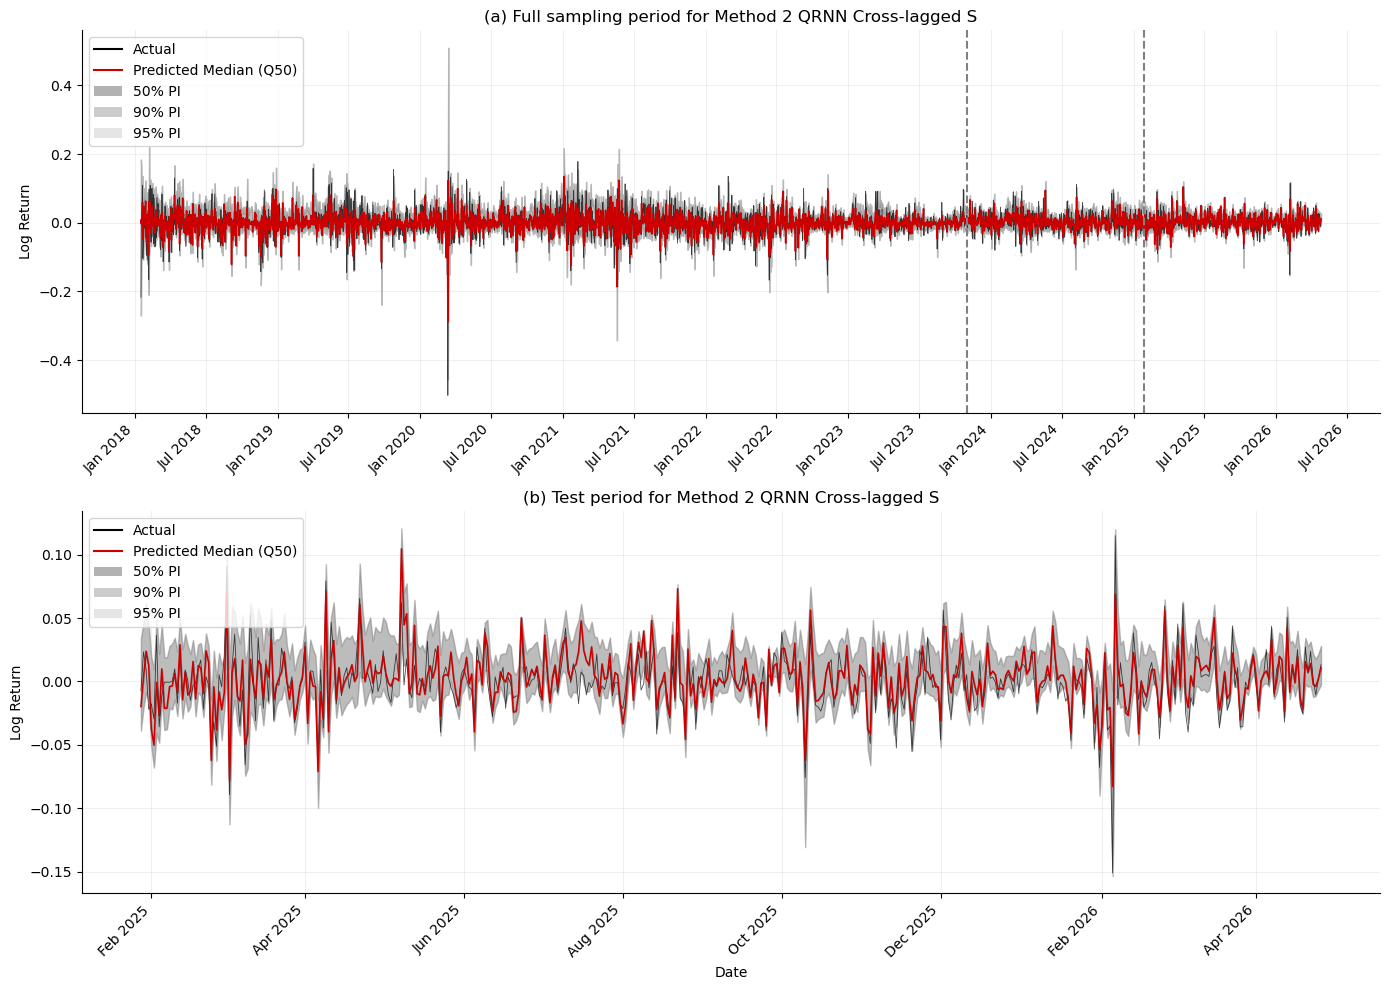

Plot saved to method2_sequential_qrnn_s_cross_predictions.png

TEST METRICS -- METHOD 2 QRNN S CROSS-LAGGED
 alpha       NLL  Hit_Rate      HRE
 0.025 -2.220793  0.123348 0.098348
 0.050 -2.509254  0.123348 0.073348
 0.250 -2.466071  0.594714 0.344714
 0.500 -2.791529  0.594714 0.094714
 0.750 -2.689862  0.594714 0.155286
 0.950 -2.296737  0.980176 0.030176
 0.975 -2.370821  0.980176 0.005176

Average NLL: -2.477867
Average HRE: 0.114537

CROSSOVER ANALYSIS -- FINAL METHOD 2 HYBRID OUTPUT
(0.025, 0.050): 0 (0.00%) <-- TAIL
(0.050, 0.250): 0 (0.00%)
(0.250, 0.500): 0 (0.00%)
(0.500, 0.750): 0 (0.00%)
(0.750, 0.950): 0 (0.00%)
(0.950, 0.975): 0 (0.00%) <-- TAIL

Total violations: 0 (0.00%)
Tail violations: 0 (0.00%)

CONSTRAINT-BINDING RATE -- TEST PERIOD
alpha=0.750 | reference=0.500 | 454/454 (100.00%)
alpha=0.950 | reference=0.750 | 0/454 (0.00%)
alpha=0.975 | reference=0.950 | 454/454 (100.00%)
alpha=0.250 | reference=0.500 | 454/454 (100.00%)
alpha=0.050 | reference=0.250 | 0/454 (0

In [38]:
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from matplotlib.lines import Line2D
from matplotlib.patches import Patch


# ============================================================
# PLOT AND EVALUATE METHOD 2 QRNN S CROSS-LAGGED
# Run the tuning cell/file first. If the in-memory model dictionary
# is unavailable, this code reloads the saved checkpoint.
# ============================================================

m2_qrnn_cross_s_plot_levels = [
    0.025, 0.050, 0.250, 0.500, 0.750, 0.950, 0.975
]

m2_qrnn_cross_s_plot_order = [
    0.500, 0.750, 0.950, 0.975, 0.250, 0.050, 0.025
]

m2_qrnn_cross_s_plot_reference = {
    0.500: None,
    0.750: 0.500,
    0.950: 0.750,
    0.975: 0.950,
    0.250: 0.500,
    0.050: 0.250,
    0.025: 0.050,
}

m2_qrnn_cross_s_plot_direction = {
    0.500: None,
    0.750: 'upper',
    0.950: 'upper',
    0.975: 'upper',
    0.250: 'lower',
    0.050: 'lower',
    0.025: 'lower',
}


# ============================================================
# Restore models if the tuning dictionary is not in memory
# ============================================================

if 'm2_qrnn_cross_s_final_models' not in globals():
    checkpoint = torch.load(
        'method2_sequential_qrnn_s_cross_best.pt',
        map_location='cpu',
        weights_only=False,
    )

    m2_qrnn_cross_s_final_models = {}

    for alpha in checkpoint['estimation_order']:
        model = M2SequentialQRNNCrossS(
            input_dim=X_train.shape[1],
            config=checkpoint['configs'][alpha],
            direction=checkpoint['directions'][alpha],
        )
        model.load_state_dict(checkpoint['model_state_dicts'][alpha])
        model.eval()
        m2_qrnn_cross_s_final_models[alpha] = model


# ============================================================
# Generate all seven full-sample forecasts sequentially
# ============================================================

def m2_qrnn_cross_s_generate_all_predictions(models, y, X):
    predictions = {}
    caviar_outputs = {}
    raw_fnn_outputs = {}
    constrained_fnn_outputs = {}
    sigma_values = {}

    for alpha in m2_qrnn_cross_s_plot_order:
        reference_alpha = m2_qrnn_cross_s_plot_reference[alpha]
        reference = (
            None
            if reference_alpha is None
            else predictions[reference_alpha]
        )

        model = models[alpha]
        model.eval()

        with torch.no_grad():
            (
                predictions[alpha],
                caviar_outputs[alpha],
                raw_fnn_outputs[alpha],
                constrained_fnn_outputs[alpha],
                sigma_values[alpha],
            ) = model(y, X, reference)

    return (
        predictions,
        caviar_outputs,
        raw_fnn_outputs,
        constrained_fnn_outputs,
        sigma_values,
    )


m2_qrnn_cross_s_X_all = torch.tensor(
    df[feature_cols].values,
    dtype=torch.float32,
)

m2_qrnn_cross_s_y_all = torch.tensor(
    df['log_return'].values,
    dtype=torch.float32,
)

(
    m2_qrnn_cross_s_all_preds_tensor,
    m2_qrnn_cross_s_all_caviar,
    m2_qrnn_cross_s_all_raw_fnn,
    m2_qrnn_cross_s_all_constrained_fnn,
    m2_qrnn_cross_s_sigma,
) = m2_qrnn_cross_s_generate_all_predictions(
    models=m2_qrnn_cross_s_final_models,
    y=m2_qrnn_cross_s_y_all,
    X=m2_qrnn_cross_s_X_all,
)

m2_qrnn_cross_s_all_preds = {
    alpha: prediction.detach().cpu().numpy()
    for alpha, prediction in m2_qrnn_cross_s_all_preds_tensor.items()
}


# ============================================================
# Plot full and test periods
# ============================================================

m2_qrnn_cross_s_all_dates = df.index
m2_qrnn_cross_s_test_dates = test_df.index
m2_qrnn_cross_s_test_start = len(train_df) + len(val_df)

m2_qrnn_cross_s_actual = df['log_return'].values
m2_qrnn_cross_s_actual_test = test_df['log_return'].values

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

actual_color = '#000000'
median_color = '#CC0000'
interval_color = '#808080'


def m2_qrnn_cross_s_draw_panel(ax, dates, actual, start=None):
    def values(alpha):
        series = m2_qrnn_cross_s_all_preds[alpha]
        return series if start is None else series[start:]

    ax.plot(dates, actual, color=actual_color, linewidth=0.6, alpha=0.7)
    ax.plot(
        dates,
        values(0.500),
        color=median_color,
        linewidth=1.1,
    )
    ax.fill_between(
        dates,
        values(0.025),
        values(0.975),
        color=interval_color,
        alpha=0.20,
    )
    ax.fill_between(
        dates,
        values(0.050),
        values(0.950),
        color=interval_color,
        alpha=0.40,
    )
    ax.fill_between(
        dates,
        values(0.250),
        values(0.750),
        color=interval_color,
        alpha=0.60,
    )
    ax.set_ylabel('Log Return')
    ax.grid(True, alpha=0.2)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)


m2_qrnn_cross_s_draw_panel(
    axes[0],
    m2_qrnn_cross_s_all_dates,
    m2_qrnn_cross_s_actual,
)
axes[0].axvline(train_df.index[-1], color='gray', linestyle='--')
axes[0].axvline(val_df.index[-1], color='gray', linestyle='--')
axes[0].set_title(
    '(a) Full sampling period for Method 2 QRNN Cross-lagged S'
)
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[0].xaxis.set_major_locator(mdates.MonthLocator(interval=6))

m2_qrnn_cross_s_draw_panel(
    axes[1],
    m2_qrnn_cross_s_test_dates,
    m2_qrnn_cross_s_actual_test,
    start=m2_qrnn_cross_s_test_start,
)
axes[1].set_title('(b) Test period for Method 2 QRNN Cross-lagged S')
axes[1].set_xlabel('Date')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=2))

legend_elements = [
    Line2D([0], [0], color=actual_color, label='Actual'),
    Line2D([0], [0], color=median_color, label='Predicted Median (Q50)'),
    Patch(facecolor=interval_color, alpha=0.60, label='50% PI'),
    Patch(facecolor=interval_color, alpha=0.40, label='90% PI'),
    Patch(facecolor=interval_color, alpha=0.20, label='95% PI'),
]

for axis in axes:
    axis.legend(handles=legend_elements, loc='upper left')
    plt.setp(axis.xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()

m2_qrnn_cross_s_plot_name = (
    'method2_sequential_qrnn_s_cross_predictions.png'
)
plt.savefig(m2_qrnn_cross_s_plot_name, dpi=300, bbox_inches='tight')
plt.show()
plt.close()

print(f'Plot saved to {m2_qrnn_cross_s_plot_name}')


# ============================================================
# Test metrics
# ============================================================

m2_qrnn_cross_s_y_test = m2_qrnn_cross_s_y_all[
    m2_qrnn_cross_s_test_start:
]
m2_qrnn_cross_s_metric_rows = []

for alpha in m2_qrnn_cross_s_plot_levels:
    q_test = m2_qrnn_cross_s_all_preds_tensor[alpha][
        m2_qrnn_cross_s_test_start:
    ]
    sigma = m2_qrnn_cross_s_sigma[alpha]
    nll = m2_qrnn_cross_s_loss(
        m2_qrnn_cross_s_y_test, q_test, sigma, alpha
    ).item()
    hit_rate = (m2_qrnn_cross_s_y_test <= q_test).float().mean().item()
    hre = abs(hit_rate - alpha)

    m2_qrnn_cross_s_metric_rows.append(
        {
            'alpha': alpha,
            'NLL': nll,
            'Hit_Rate': hit_rate,
            'HRE': hre,
        }
    )

m2_qrnn_cross_s_metrics_df = pd.DataFrame(m2_qrnn_cross_s_metric_rows)
m2_qrnn_cross_s_average_nll = m2_qrnn_cross_s_metrics_df['NLL'].mean()
m2_qrnn_cross_s_average_hre = m2_qrnn_cross_s_metrics_df['HRE'].mean()

print('\n' + '=' * 68)
print('TEST METRICS -- METHOD 2 QRNN S CROSS-LAGGED')
print('=' * 68)
print(m2_qrnn_cross_s_metrics_df.to_string(index=False))
print(f'\nAverage NLL: {m2_qrnn_cross_s_average_nll:.6f}')
print(f'Average HRE: {m2_qrnn_cross_s_average_hre:.6f}')


# ============================================================
# Crossover analysis
# ============================================================

m2_qrnn_cross_s_pairs = [
    (0.025, 0.050),
    (0.050, 0.250),
    (0.250, 0.500),
    (0.500, 0.750),
    (0.750, 0.950),
    (0.950, 0.975),
]
m2_qrnn_cross_s_tail_pairs = [(0.025, 0.050), (0.950, 0.975)]

m2_qrnn_cross_s_total = 0
m2_qrnn_cross_s_tail_total = 0
m2_qrnn_cross_s_crossover_rows = []

print('\n' + '=' * 68)
print('CROSSOVER ANALYSIS -- FINAL METHOD 2 HYBRID OUTPUT')
print('=' * 68)

for lower, upper in m2_qrnn_cross_s_pairs:
    lower_test = m2_qrnn_cross_s_all_preds_tensor[lower][
        m2_qrnn_cross_s_test_start:
    ]
    upper_test = m2_qrnn_cross_s_all_preds_tensor[upper][
        m2_qrnn_cross_s_test_start:
    ]
    violations = int((lower_test > upper_test).sum().item())
    rate = violations / len(lower_test)

    m2_qrnn_cross_s_total += violations
    if (lower, upper) in m2_qrnn_cross_s_tail_pairs:
        m2_qrnn_cross_s_tail_total += violations

    m2_qrnn_cross_s_crossover_rows.append(
        {
            'Lower': lower,
            'Upper': upper,
            'Violations': violations,
            'Rate': rate,
        }
    )

    tail_label = (
        ' <-- TAIL'
        if (lower, upper) in m2_qrnn_cross_s_tail_pairs
        else ''
    )
    print(
        f'({lower:.3f}, {upper:.3f}): '
        f'{violations} ({100 * rate:.2f}%){tail_label}'
    )

m2_qrnn_cross_s_total_rate = m2_qrnn_cross_s_total / (
    len(m2_qrnn_cross_s_y_test) * len(m2_qrnn_cross_s_pairs)
)
m2_qrnn_cross_s_tail_rate = m2_qrnn_cross_s_tail_total / (
    len(m2_qrnn_cross_s_y_test) * len(m2_qrnn_cross_s_tail_pairs)
)

print(
    f'\nTotal violations: {m2_qrnn_cross_s_total} '
    f'({100 * m2_qrnn_cross_s_total_rate:.2f}%)'
)
print(
    f'Tail violations: {m2_qrnn_cross_s_tail_total} '
    f'({100 * m2_qrnn_cross_s_tail_rate:.2f}%)'
)


# ============================================================
# Constraint-binding diagnostic
# ============================================================

m2_qrnn_cross_s_binding_rows = []

print('\n' + '=' * 68)
print('CONSTRAINT-BINDING RATE -- TEST PERIOD')
print('=' * 68)

for alpha in m2_qrnn_cross_s_plot_order:
    direction = m2_qrnn_cross_s_plot_direction[alpha]
    reference_alpha = m2_qrnn_cross_s_plot_reference[alpha]

    if direction is None:
        continue

    model = m2_qrnn_cross_s_final_models[alpha]
    psi = (
        (1.0 - M2_QRNN_CROSS_S_PSI_MARGIN)
        * torch.sigmoid(model.psi_raw)
    )
    caviar = m2_qrnn_cross_s_all_caviar[alpha][
        m2_qrnn_cross_s_test_start:
    ]
    raw_fnn = m2_qrnn_cross_s_all_raw_fnn[alpha][
        m2_qrnn_cross_s_test_start:
    ]
    reference = m2_qrnn_cross_s_all_preds_tensor[reference_alpha][
        m2_qrnn_cross_s_test_start:
    ]
    raw_hybrid = psi * caviar + (1.0 - psi) * raw_fnn

    if direction == 'upper':
        binding = raw_hybrid < (
            reference + M2_QRNN_CROSS_S_DELTA
        )
    else:
        binding = raw_hybrid > (
            reference - M2_QRNN_CROSS_S_DELTA
        )

    binding_count = int(binding.sum().item())
    binding_rate = binding.float().mean().item()

    m2_qrnn_cross_s_binding_rows.append(
        {
            'Alpha': alpha,
            'Reference': reference_alpha,
            'Direction': direction,
            'Binding_Count': binding_count,
            'Binding_Rate': binding_rate,
        }
    )
    print(
        f'alpha={alpha:.3f} | reference={reference_alpha:.3f} | '
        f'{binding_count}/{len(binding)} ({100 * binding_rate:.2f}%)'
    )


# ============================================================
# Save outputs
# ============================================================

m2_qrnn_cross_s_metrics_df.to_csv(
    'method2_sequential_qrnn_s_cross_test_metrics.csv',
    index=False,
)
pd.DataFrame(m2_qrnn_cross_s_crossover_rows).to_csv(
    'method2_sequential_qrnn_s_cross_crossover.csv',
    index=False,
)
pd.DataFrame(m2_qrnn_cross_s_binding_rows).to_csv(
    'method2_sequential_qrnn_s_cross_binding_rates.csv',
    index=False,
)

print('\nSaved Method 2 outputs:')
print('  method2_sequential_qrnn_s_cross_predictions.png')
print('  method2_sequential_qrnn_s_cross_test_metrics.csv')
print('  method2_sequential_qrnn_s_cross_crossover.csv')
print('  method2_sequential_qrnn_s_cross_binding_rates.csv')

# Cross over dealing 3

In [41]:
"""Method 3, Specification 1: Hybrid QRNN S cross-lagged.

Run this after the notebook has created the four tensors
``y_train``, ``X_train``, ``y_val`` and ``X_val``.

The median is the corresponding original hybrid model.  Every non-median
network predicts a raw adjacent gap; ``softplus`` makes that gap positive and
the target level is reconstructed from its already-fitted adjacent reference.
There is no fixed epsilon boundary, max/min projection, or crossover penalty.
"""

from __future__ import annotations

import copy
from pathlib import Path

import numpy as np
import optuna
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from optuna.samplers import TPESampler


# ---------------------------------------------------------------------------
# User settings
# ---------------------------------------------------------------------------

LEVELS = [0.025, 0.050, 0.250, 0.500, 0.750, 0.950, 0.975]
ESTIMATION_ORDER = [0.500, 0.750, 0.950, 0.975, 0.250, 0.050, 0.025]
REFERENCE_LEVEL = {
    0.500: None,
    0.750: 0.500,
    0.950: 0.750,
    0.975: 0.950,
    0.250: 0.500,
    0.050: 0.250,
    0.025: 0.050,
}
DIRECTION = {
    0.500: None,
    0.750: "upper",
    0.950: "upper",
    0.975: "upper",
    0.250: "lower",
    0.050: "lower",
    0.025: "lower",
}

N_TRIALS = 200
MAX_EPOCHS = 200
BASE_SEED = 2026
PSI_MARGIN = 1e-4
INITIAL_DELTA_BIAS = -4.6  # softplus(-4.6) is about 0.01; trainable.
OUTPUT_DIR = Path("method3_spacing_qrnn_s_cross_results")

# This standalone chunk estimates only the model supplied by the user:
# Hybrid QRNN, symmetric form, cross-lagged recursion.
MODELS_TO_RUN = [("qrnn", "s", "cross")]


def validate_notebook_inputs():
    required = ("y_train", "X_train", "y_val", "X_val")
    missing = [name for name in required if name not in globals()]
    if missing:
        raise NameError(
            "Create these notebook tensors before running Method 3: "
            + ", ".join(missing)
        )
    for y_name, x_name in (("y_train", "X_train"), ("y_val", "X_val")):
        y_value, x_value = globals()[y_name], globals()[x_name]
        if not isinstance(y_value, torch.Tensor) or not isinstance(x_value, torch.Tensor):
            raise TypeError(f"{y_name} and {x_name} must be torch tensors.")
        if y_value.ndim != 1 or x_value.ndim != 2 or len(y_value) != len(x_value):
            raise ValueError(f"{y_name} must be (T,) and {x_name} must be (T,p).")


# ---------------------------------------------------------------------------
# Generic Method 3 model
# ---------------------------------------------------------------------------

class Method3SpacingModel(nn.Module):
    """One sequential level model.

    direction=None is the median hybrid model.  Otherwise the network is a
    pure learned-spacing model and deliberately has no redundant statistical
    or mixing parameters.
    """

    def __init__(self, input_dim, config, distribution, form, lag, direction=None):
        super().__init__()
        if distribution not in {"qrnn", "ernn"}:
            raise ValueError("distribution must be 'qrnn' or 'ernn'.")
        if form not in {"s", "a", "si"}:
            raise ValueError("form must be 's', 'a', or 'si'.")
        if lag not in {"self", "cross"}:
            raise ValueError("lag must be 'self' or 'cross'.")

        self.distribution = distribution
        self.form = form
        self.lag = lag
        self.direction = direction

        # Statistical and mixing parameters are identifiable only for median.
        if direction is None:
            self.persistence_raw = nn.Parameter(torch.tensor(1.386))
            self.news1_raw = nn.Parameter(torch.tensor(0.3))
            if form in {"a", "si"}:
                self.news2_raw = nn.Parameter(torch.tensor(0.3))
            self.psi_raw = nn.Parameter(torch.tensor(0.0))

        self.sigma_raw = nn.Parameter(torch.tensor(0.5))
        fnn_input_dim = input_dim if direction is None else input_dim + 1
        layers = []
        previous_dim = fnn_input_dim
        for index in range(config["n_hidden_layers"]):
            hidden_dim = config[f"hidden_dim_{index}"]
            layers.append(nn.Linear(previous_dim, hidden_dim))
            if config["layernorm"]:
                layers.append(nn.LayerNorm(hidden_dim))
            layers.append(self._activation(config["activation"]))
            if config["dropout"] > 0:
                layers.append(nn.Dropout(config["dropout"]))
            previous_dim = hidden_dim
        layers.append(nn.Linear(previous_dim, 1))
        self.fnn = nn.Sequential(*layers)
        self._initialise_fnn(config["weight_init"])

        if direction is not None:
            nn.init.constant_(self.fnn[-1].bias, INITIAL_DELTA_BIAS)

    @staticmethod
    def _activation(name):
        return {
            "relu": nn.ReLU(),
            "elu": nn.ELU(),
            "gelu": nn.GELU(),
            "tanh": nn.Tanh(),
        }[name]

    def _initialise_fnn(self, method):
        for module in self.fnn.modules():
            if isinstance(module, nn.Linear):
                if method == "glorot":
                    nn.init.xavier_uniform_(module.weight)
                else:
                    nn.init.kaiming_uniform_(module.weight)
                if module.bias is not None:
                    nn.init.zeros_(module.bias)

    def _statistical_update(self, previous_state, previous_y):
        persistence = torch.sigmoid(self.persistence_raw)
        news1 = F.softplus(self.news1_raw)
        if self.form == "s":
            return persistence * previous_state + news1 * torch.abs(previous_y)
        if self.form == "a":
            news2 = F.softplus(self.news2_raw)
            return (
                persistence * previous_state
                + news1 * torch.clamp(previous_y, min=0)
                + news2 * torch.clamp(-previous_y, min=0)
            )
        news2 = F.softplus(self.news2_raw)
        absolute_y = torch.abs(previous_y)
        return (
            persistence * previous_state
            + news1 * absolute_y
            + news2 * previous_state * absolute_y
        )

    def forward(self, y, X, q_reference=None, initial_state=None, initial_y=None):
        sigma = F.softplus(self.sigma_raw) + 1e-6

        # Six non-median models: directly learn a positive adjacent spacing.
        if self.direction is not None:
            if q_reference is None:
                raise ValueError("Non-median levels require q_reference.")
            reference = q_reference.detach()
            raw_delta = self.fnn(
                torch.cat((X, reference.unsqueeze(1)), dim=1)
            ).squeeze(-1)
            delta = F.softplus(raw_delta)
            prediction = reference + delta if self.direction == "upper" else reference - delta
            return prediction, torch.zeros_like(prediction), raw_delta, delta, sigma

        # Median: original hybrid statistical-neural specification.
        if (initial_state is None) != (initial_y is None):
            raise ValueError("initial_state and initial_y must be supplied together.")
        has_initial_state = initial_state is not None
        previous_state = initial_state if has_initial_state else y.new_zeros(())
        fnn_median = self.fnn(X).squeeze(-1)
        psi = (1.0 - PSI_MARGIN) * torch.sigmoid(self.psi_raw)
        predictions, statistical_outputs = [], []

        for t in range(len(y)):
            if t == 0 and not has_initial_state:
                statistical_t = y.new_zeros(())
                hybrid_t = y.new_zeros(())
            else:
                previous_y = initial_y if t == 0 else y[t - 1]
                statistical_t = self._statistical_update(previous_state, previous_y)
                hybrid_t = psi * statistical_t + (1.0 - psi) * fnn_median[t]
            statistical_outputs.append(statistical_t)
            predictions.append(hybrid_t)
            # Settled convention used by the earlier code:
            # self -> previous pure statistical output; cross -> previous hybrid.
            previous_state = statistical_t if self.lag == "self" else hybrid_t

        prediction = torch.stack(predictions)
        statistical = torch.stack(statistical_outputs)
        return prediction, statistical, fnn_median, None, sigma


# ---------------------------------------------------------------------------
# Distribution-specific objectives and calibration metrics
# ---------------------------------------------------------------------------

def single_level_nll(y, location, sigma, level, distribution):
    residual = y - location
    level_tensor = torch.tensor(level, dtype=y.dtype, device=y.device)
    if distribution == "qrnn":
        indicator = (residual < 0).to(y.dtype)
        rho = residual * (level_tensor - indicator)
        return (
            -torch.log(level_tensor * (1.0 - level_tensor))
            + torch.log(sigma)
            + rho / sigma
        ).mean()

    weight = torch.abs(level_tensor - (residual < 0).to(y.dtype))
    omega = weight * residual.square()
    constant = (
        torch.log(
            torch.sqrt(torch.pi / level_tensor)
            + torch.sqrt(torch.pi / (1.0 - level_tensor))
        )
        - np.log(2.0)
    )
    return (torch.log(sigma) + constant + omega / sigma.square()).mean()


def qrnn_calibration(y, location, level):
    if level <= 0.5:
        empirical = (y <= location).float().mean().item()
        target = level
    else:
        empirical = (y > location).float().mean().item()
        target = 1.0 - level
    crp = empirical / target
    return {"hit_rate": (y <= location).float().mean().item(),
            "hre": abs((y <= location).float().mean().item() - level),
            "calibration": crp,
            "calibration_penalty": (crp - 1.0) ** 2}


def ernn_calibration(y, location, level):
    residual = y - location
    weights = torch.where(
        residual >= 0,
        torch.full_like(residual, level),
        torch.full_like(residual, 1.0 - level),
    )
    ase = (weights * residual.square()).mean().item()
    return {"ase": ase, "calibration": ase, "calibration_penalty": ase}


# ---------------------------------------------------------------------------
# Tuning helpers
# ---------------------------------------------------------------------------

def suggest_config(trial):
    config = {
        "n_hidden_layers": trial.suggest_int("n_hidden_layers", 1, 3),
        "activation": trial.suggest_categorical("activation", ["relu", "elu", "gelu", "tanh"]),
        "dropout": trial.suggest_float("dropout", 0.0, 0.5),
        "layernorm": trial.suggest_categorical("layernorm", [True, False]),
        "weight_init": trial.suggest_categorical("weight_init", ["glorot", "he"]),
        "lr": trial.suggest_float("lr", 1e-4, 5e-2, log=True),
        "optimizer": trial.suggest_categorical("optimizer", ["adam", "adamw"]),
        "weight_decay": trial.suggest_float("weight_decay", 0.0, 1e-4),
        "gradient_clip": trial.suggest_categorical("gradient_clip", [0.1, 1.0, 5.0]),
        "patience": trial.suggest_categorical("patience", [10, 20, 30]),
    }
    for index in range(config["n_hidden_layers"]):
        config[f"hidden_dim_{index}"] = trial.suggest_int(f"hidden_dim_{index}", 32, 256)
    return config


def make_optimizer(model, config):
    optimizer_class = torch.optim.Adam if config["optimizer"] == "adam" else torch.optim.AdamW
    return optimizer_class(model.parameters(), lr=config["lr"], weight_decay=config["weight_decay"])


def median_validation_state(model, statistical_train, prediction_train):
    return statistical_train[-1] if model.lag == "self" else prediction_train[-1]


def predict_train_val(model, direction, q_reference_train=None, q_reference_val=None):
    model.eval()
    with torch.no_grad():
        q_train, stat_train, _, delta_train, _ = model(
            y_train, X_train, q_reference_train
        )
        if direction is None:
            q_val, _, _, delta_val, sigma = model(
                y_val,
                X_val,
                initial_state=median_validation_state(model, stat_train, q_train),
                initial_y=y_train[-1],
            )
        else:
            q_val, _, _, delta_val, sigma = model(y_val, X_val, q_reference_val)
    return q_train.detach(), q_val.detach(), delta_train, delta_val, sigma.detach()


def train_config(spec, config, level, direction, q_ref_train, q_ref_val, seed):
    distribution, form, lag = spec
    torch.manual_seed(seed)
    model = Method3SpacingModel(
        X_train.shape[1], config, distribution, form, lag, direction
    )
    optimizer = make_optimizer(model, config)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", patience=10, factor=0.5, min_lr=1e-6
    )
    best_loss, counter, best_state = float("inf"), 0, None

    for _ in range(MAX_EPOCHS):
        model.train()
        optimizer.zero_grad()
        q_train, _, _, _, sigma = model(y_train, X_train, q_ref_train)
        loss = single_level_nll(y_train[1:], q_train[1:], sigma, level, distribution)
        if not torch.isfinite(loss):
            return None
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), config["gradient_clip"])
        optimizer.step()

        model.eval()
        with torch.no_grad():
            _, q_val, _, _, sigma_val = predict_train_val(
                model, direction, q_ref_train, q_ref_val
            )
            val_loss = single_level_nll(y_val, q_val, sigma_val, level, distribution)
        scheduler.step(val_loss.item())
        if val_loss.item() < best_loss:
            best_loss, counter = val_loss.item(), 0
            best_state = copy.deepcopy(model.state_dict())
        else:
            counter += 1
            if counter >= config["patience"]:
                break

    if best_state is None:
        return None
    model.load_state_dict(best_state)
    return model


def transformed_median_parameters(model):
    if model.direction is not None:
        return {}
    result = {
        "persistence": torch.sigmoid(model.persistence_raw).item(),
        "news1": F.softplus(model.news1_raw).item(),
        "psi": ((1.0 - PSI_MARGIN) * torch.sigmoid(model.psi_raw)).item(),
    }
    result["news2"] = (
        F.softplus(model.news2_raw).item() if hasattr(model, "news2_raw") else np.nan
    )
    return result


def evaluate(model, level, direction, q_ref_train, q_ref_val):
    _, q_val, _, delta_val, sigma = predict_train_val(
        model, direction, q_ref_train, q_ref_val
    )
    metrics = {
        "nll": single_level_nll(
            y_val, q_val, sigma, level, model.distribution
        ).item(),
        "sigma": (F.softplus(model.sigma_raw) + 1e-6).item(),
        "mean_delta": np.nan if delta_val is None else delta_val.mean().item(),
        "min_delta": np.nan if delta_val is None else delta_val.min().item(),
        "max_delta": np.nan if delta_val is None else delta_val.max().item(),
        "sd_delta": np.nan if delta_val is None else delta_val.std(unbiased=False).item(),
    }
    metrics.update(
        qrnn_calibration(y_val, q_val, level)
        if model.distribution == "qrnn"
        else ernn_calibration(y_val, q_val, level)
    )
    metrics.update(transformed_median_parameters(model))
    return metrics


def select_trial(study):
    trials = [
        trial for trial in study.trials
        if trial.state == optuna.trial.TrialState.COMPLETE
        and trial.value is not None
        and np.isfinite(trial.value)
        and "calibration_penalty" in trial.user_attrs
    ]
    if not trials:
        raise RuntimeError("No valid completed Optuna trials.")
    for rank, trial in enumerate(sorted(trials, key=lambda x: x.user_attrs["nll"]), 1):
        trial._rank_nll = rank
    for rank, trial in enumerate(
        sorted(trials, key=lambda x: x.user_attrs["calibration_penalty"]), 1
    ):
        trial._rank_calibration = rank
    best = min(
        trials,
        key=lambda x: (
            x._rank_nll + x._rank_calibration,
            x.user_attrs["nll"],
            x.user_attrs["calibration_penalty"],
            x.number,
        ),
    )
    return best, trials


def count_crossovers(predictions):
    matrix = torch.stack([predictions[level] for level in LEVELS], dim=1)
    violations = matrix[:, :-1] > matrix[:, 1:]
    pair_counts = violations.sum(dim=0)
    return {
        "crossover": int(violations.sum().item()),
        "tail": int((pair_counts[0] + pair_counts[-1]).item()),
    }


def run_one_model(spec):
    distribution, form, lag = spec
    model_key = f"{distribution}_{form}_{lag}"
    model_dir = OUTPUT_DIR / model_key
    model_dir.mkdir(parents=True, exist_ok=True)
    print("\n" + "=" * 78)
    print(f"METHOD 3 SPACING: {distribution.upper()} {form.upper()} {lag.upper()}")
    print("=" * 78)

    models, configs, metrics_by_level = {}, {}, {}
    train_predictions, val_predictions = {}, {}
    train_deltas, val_deltas = {}, {}

    for order_index, level in enumerate(ESTIMATION_ORDER):
        reference_level = REFERENCE_LEVEL[level]
        direction = DIRECTION[level]
        q_ref_train = None if reference_level is None else train_predictions[reference_level]
        q_ref_val = None if reference_level is None else val_predictions[reference_level]
        seed = BASE_SEED + 1000 * MODELS_TO_RUN.index(spec) + order_index

        def objective(trial):
            config = suggest_config(trial)
            model = train_config(
                spec, config, level, direction, q_ref_train, q_ref_val, seed
            )
            if model is None:
                return float("inf")
            trial_metrics = evaluate(model, level, direction, q_ref_train, q_ref_val)
            for name, value in trial_metrics.items():
                trial.set_user_attr(name, value)
            return trial_metrics["nll"]

        print(
            f"Level={level:.3f} | reference={reference_level} | "
            f"direction={direction} | trials={N_TRIALS}"
        )
        study = optuna.create_study(
            direction="minimize", sampler=TPESampler(seed=seed)
        )
        study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)
        best_trial, valid_trials = select_trial(study)

        ranking_records = []
        for trial in valid_trials:
            record = {
                "distribution": distribution,
                "form": form,
                "lag": lag,
                "level": level,
                "reference_level": reference_level,
                "direction": direction,
                "trial": trial.number,
                "nll": trial.user_attrs["nll"],
                "calibration": trial.user_attrs["calibration"],
                "calibration_penalty": trial.user_attrs["calibration_penalty"],
                "rank_nll": trial._rank_nll,
                "rank_calibration": trial._rank_calibration,
                "sum_rank": trial._rank_nll + trial._rank_calibration,
            }
            record.update(trial.user_attrs)
            record.update(trial.params)
            ranking_records.append(record)
        pd.DataFrame(ranking_records).sort_values(
            ["sum_rank", "nll", "calibration_penalty"]
        ).to_csv(model_dir / f"ranking_level_{level:.3f}.csv", index=False)

        best_config = best_trial.params.copy()
        final_model = train_config(
            spec, best_config, level, direction, q_ref_train, q_ref_val, seed
        )
        if final_model is None:
            raise RuntimeError(f"Selected refit failed for {model_key}, level={level}.")
        final_metrics = evaluate(
            final_model, level, direction, q_ref_train, q_ref_val
        )
        q_train, q_val, delta_train, delta_val, _ = predict_train_val(
            final_model, direction, q_ref_train, q_ref_val
        )
        models[level], configs[level] = final_model, best_config
        metrics_by_level[level] = final_metrics
        train_predictions[level], val_predictions[level] = q_train, q_val
        train_deltas[level], val_deltas[level] = delta_train, delta_val

        print(
            f"Selected trial #{best_trial.number} | "
            f"val NLL={final_metrics['nll']:.6f} | "
            f"calibration={final_metrics['calibration']:.6f} | "
            f"mean delta={final_metrics['mean_delta']:.6f}"
        )

    crossing = count_crossovers(val_predictions)
    average_nll = float(np.mean([metrics_by_level[x]["nll"] for x in LEVELS]))
    if distribution == "qrnn":
        average_secondary = float(np.mean([metrics_by_level[x]["hre"] for x in LEVELS]))
        secondary_name = "hre"
    else:
        average_secondary = float(np.mean([metrics_by_level[x]["ase"] for x in LEVELS]))
        secondary_name = "ase"

    checkpoint = {
        "model_name": f"Method 3 spacing {distribution.upper()} {form.upper()} {lag}",
        "specification": "learned_positive_time_varying_adjacent_spacing",
        "distribution": distribution,
        "form": form,
        "lag": lag,
        "levels": LEVELS,
        "estimation_order": ESTIMATION_ORDER,
        "reference_level": REFERENCE_LEVEL,
        "direction": DIRECTION,
        "configs": configs,
        "model_state_dicts": {level: model.state_dict() for level, model in models.items()},
        "validation_metrics": metrics_by_level,
        "validation_summary": {
            "average_nll": average_nll,
            f"average_{secondary_name}": average_secondary,
            **crossing,
        },
    }
    checkpoint_path = model_dir / f"method3_spacing_{model_key}_best.pt"
    torch.save(checkpoint, checkpoint_path)

    level_rows = []
    for level in LEVELS:
        level_rows.append({"level": level, **metrics_by_level[level]})
    pd.DataFrame(level_rows).to_csv(model_dir / "validation_by_level.csv", index=False)

    summary = {
        "distribution": distribution,
        "form": form.upper(),
        "lag": lag,
        "average_nll": average_nll,
        "average_hre": average_secondary if distribution == "qrnn" else np.nan,
        "average_ase": average_secondary if distribution == "ernn" else np.nan,
        **crossing,
        "checkpoint": str(checkpoint_path),
    }
    pd.DataFrame([summary]).to_csv(model_dir / "validation_summary.csv", index=False)
    print(f"Saved {checkpoint_path}")
    return summary


def main():
    validate_notebook_inputs()
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    summaries = []
    for spec in MODELS_TO_RUN:
        summaries.append(run_one_model(spec))
        pd.DataFrame(summaries).to_csv(
            OUTPUT_DIR / "method3_qrnn_s_cross_validation_summary.csv", index=False
        )
    print("\nMethod 3 QRNN S cross-lagged estimation is complete.")
    print(pd.DataFrame(summaries).to_string(index=False))


if __name__ == "__main__":
    main()

[I 2026-08-16 16:36:59,078] A new study created in memory with name: no-name-74cd55a4-fbbf-4ff1-9a47-a807c84a8617



METHOD 3 SPACING: QRNN S CROSS
Level=0.500 | reference=None | direction=None | trials=200


  0%|          | 0/200 [00:00<?, ?it/s]

[I 2026-08-16 16:37:46,963] Trial 0 finished with value: 1.3076515197753906 and parameters: {'n_hidden_layers': 1, 'activation': 'elu', 'dropout': 0.49377524711883497, 'layernorm': False, 'weight_init': 'he', 'lr': 0.0006552020421842752, 'optimizer': 'adam', 'weight_decay': 8.940884610144999e-05, 'gradient_clip': 5.0, 'patience': 30, 'hidden_dim_0': 38}. Best is trial 0 with value: 1.3076515197753906.
[I 2026-08-16 16:38:30,872] Trial 1 finished with value: 0.2615746855735779 and parameters: {'n_hidden_layers': 1, 'activation': 'tanh', 'dropout': 0.07458356653667625, 'layernorm': False, 'weight_init': 'he', 'lr': 0.006969178688110181, 'optimizer': 'adam', 'weight_decay': 2.574006001095316e-05, 'gradient_clip': 1.0, 'patience': 30, 'hidden_dim_0': 102}. Best is trial 1 with value: 0.2615746855735779.
[I 2026-08-16 16:38:36,336] Trial 2 finished with value: 1.4286831617355347 and parameters: {'n_hidden_layers': 1, 'activation': 'tanh', 'dropout': 0.37112272198735796, 'layernorm': True, '

[I 2026-08-16 18:43:44,515] A new study created in memory with name: no-name-cea3664d-efb5-4967-a0ee-a4032f3f09ec


...

[I 2026-08-16 20:59:42,190] Trial 0 finished with value: 1.9723773002624512 and parameters: {'n_hidden_layers': 2, 'activation': 'tanh', 'dropout': 0.11155263989652436, 'layernorm': False, 'weight_init': 'glorot', 'lr': 0.007027131382827591, 'optimizer': 'adam', 'weight_decay': 1.3627456384020455e-05, 'gradient_clip': 0.1, 'patience': 20, 'hidden_dim_0': 210, 'hidden_dim_1': 162}. Best is trial 0 with value: 1.9723773002624512.
[I 2026-08-16 20:59:44,985] Trial 1 finished with value: 0.7036637663841248 and parameters: {'n_hidden_layers': 3, 'activation': 'elu', 'dropout': 0.09630890988459678, 'layernorm': False, 'weight_init': 'he', 'lr': 0.014080280114638532, 'optimizer': 'adam', 'weight_decay': 6.431370011304687e-05, 'gradient_clip': 0.1, 'patience': 10, 'hidden_dim_0': 88, 'hidden_dim_1': 196, 'hidden_dim_2': 94}. Best is trial 1 with value: 0.7036637663841248.
[I 2026-08-16 20:59:46,654] Trial 2 finished with value: 2.9173085689544678 and parameters: {'n_hidden_layers': 2, 'activat

[I 2026-08-16 22:00:53,761] A new study created in memory with name: no-name-cbcb036d-5f79-4017-bfad-a717739b73f0


Selected trial #192 | val NLL=-2.393989 | calibration=1.015453 | mean delta=0.014639
Level=0.025 | reference=0.05 | direction=lower | trials=200


  0%|          | 0/200 [00:00<?, ?it/s]

[I 2026-08-16 22:00:57,216] Trial 0 finished with value: 2.4901578426361084 and parameters: {'n_hidden_layers': 3, 'activation': 'relu', 'dropout': 0.11110238679748752, 'layernorm': False, 'weight_init': 'he', 'lr': 0.007412946243424984, 'optimizer': 'adam', 'weight_decay': 2.0378044529961404e-05, 'gradient_clip': 5.0, 'patience': 20, 'hidden_dim_0': 189, 'hidden_dim_1': 194, 'hidden_dim_2': 105}. Best is trial 0 with value: 2.4901578426361084.
[I 2026-08-16 22:01:00,533] Trial 1 finished with value: 3.3955321311950684 and parameters: {'n_hidden_layers': 3, 'activation': 'elu', 'dropout': 0.40125521853112683, 'layernorm': False, 'weight_init': 'he', 'lr': 0.002129411642087111, 'optimizer': 'adamw', 'weight_decay': 1.3495676574961092e-06, 'gradient_clip': 5.0, 'patience': 20, 'hidden_dim_0': 133, 'hidden_dim_1': 222, 'hidden_dim_2': 66}. Best is trial 0 with value: 2.4901578426361084.
[I 2026-08-16 22:01:01,838] Trial 2 finished with value: 3.539691925048828 and parameters: {'n_hidden_l

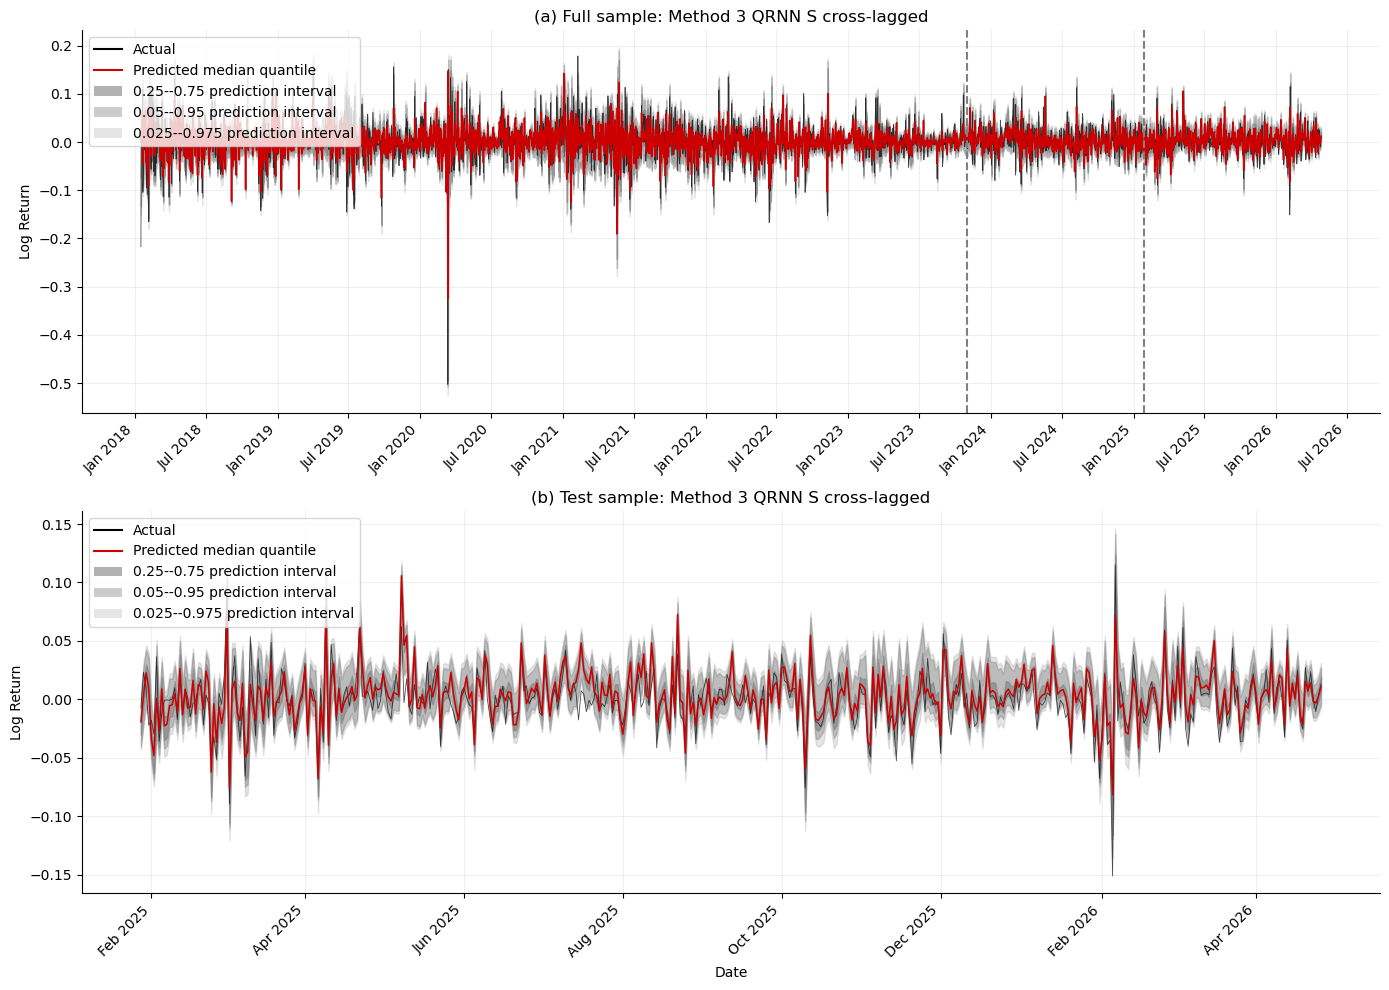


METHOD 3 QRNN S CROSS-LAGGED -- TEST RESULTS
                model  test_T  average_nll  average_hre  crossover  tail
Method 3 QRNN S Cross     454    -2.574828     0.083386          0     0

Per-level results:
 alpha       nll  hit_rate      hre    sigma
 0.025 -2.266587  0.079295 0.054295 0.000959
 0.050 -2.392292  0.143172 0.093172 0.001626
 0.250 -2.749733  0.381057 0.131057 0.004955
 0.500 -2.755151  0.647577 0.147577 0.008809
 0.750 -2.848968  0.845815 0.095815 0.005122
 0.950 -2.559100  0.988987 0.038987 0.001394
 0.975 -2.451961  0.997797 0.022797 0.000737

Learned-spacing diagnostics:
 alpha  reference_alpha direction  mean_delta  min_delta  max_delta  sd_delta  near_zero_count  near_zero_rate
 0.025             0.05     lower    0.004658   0.001932   0.016073  0.002549                0             0.0
 0.050             0.25     lower    0.009628   0.003016   0.046883  0.004497                0             0.0
 0.250             0.50     lower    0.006766   0.002796   0.0370

In [43]:
"""Plot and evaluate Method 3 QRNN S cross-lagged on the test sample.

Run after the tuning/data-preparation code. Expected notebook objects:
df, train_df, val_df, test_df, feature_cols, X_train and Method3SpacingModel.
"""

from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from matplotlib.lines import Line2D
from matplotlib.patches import Patch


LEVELS = [0.025, 0.050, 0.250, 0.500, 0.750, 0.950, 0.975]
ORDER = [0.500, 0.750, 0.950, 0.975, 0.250, 0.050, 0.025]
REFERENCE = {
    0.500: None,
    0.750: 0.500,
    0.950: 0.750,
    0.975: 0.950,
    0.250: 0.500,
    0.050: 0.250,
    0.025: 0.050,
}
DIRECTION = {
    0.500: None,
    0.750: "upper",
    0.950: "upper",
    0.975: "upper",
    0.250: "lower",
    0.050: "lower",
    0.025: "lower",
}

MODEL_DIR = Path("method3_spacing_qrnn_s_cross_results") / "qrnn_s_cross"
CHECKPOINT_PATH = MODEL_DIR / "method3_spacing_qrnn_s_cross_best.pt"
PLOT_PATH = MODEL_DIR / "method3_spacing_qrnn_s_cross.png"
METRICS_PATH = MODEL_DIR / "method3_spacing_qrnn_s_cross_test_metrics.csv"
SUMMARY_PATH = MODEL_DIR / "method3_spacing_qrnn_s_cross_test_summary.csv"
DELTA_PATH = MODEL_DIR / "method3_spacing_qrnn_s_cross_delta_summary.csv"
PREDICTIONS_PATH = MODEL_DIR / "method3_spacing_qrnn_s_cross_test_predictions.csv"


required_objects = (
    "df", "train_df", "val_df", "test_df", "feature_cols", "X_train"
)
missing = [name for name in required_objects if name not in globals()]
if missing:
    raise NameError("Run the data-preparation cells first. Missing: " + ", ".join(missing))

if "Method3SpacingModel" not in globals():
    from method3_spacing_qrnn_s_cross_tuning import Method3SpacingModel

if not CHECKPOINT_PATH.exists():
    raise FileNotFoundError(
        f"Checkpoint not found: {CHECKPOINT_PATH}. Run the tuning code first."
    )


# ---------------------------------------------------------------------------
# Reload all seven selected level models
# ---------------------------------------------------------------------------

checkpoint = torch.load(CHECKPOINT_PATH, map_location="cpu", weights_only=False)
if checkpoint.get("distribution") != "qrnn":
    raise ValueError("The checkpoint is not a QRNN checkpoint.")
if checkpoint.get("form") != "s" or checkpoint.get("lag") != "cross":
    raise ValueError("The checkpoint is not the QRNN S cross-lagged model.")

models = {}
for level in ORDER:
    model = Method3SpacingModel(
        input_dim=X_train.shape[1],
        config=checkpoint["configs"][level],
        distribution="qrnn",
        form="s",
        lag="cross",
        direction=checkpoint["direction"][level],
    )
    model.load_state_dict(checkpoint["model_state_dicts"][level])
    model.eval()
    models[level] = model


# ---------------------------------------------------------------------------
# Generate full-sample forecasts sequentially from the median outwards
# ---------------------------------------------------------------------------

X_all = torch.tensor(df[feature_cols].values, dtype=torch.float32)
y_all = torch.tensor(df["log_return"].values, dtype=torch.float32)
predictions, deltas, sigmas = {}, {}, {}

for level in ORDER:
    reference_level = REFERENCE[level]
    reference = None if reference_level is None else predictions[reference_level]
    with torch.no_grad():
        prediction, _, _, delta, sigma = models[level](y_all, X_all, reference)
    predictions[level] = prediction.detach()
    deltas[level] = None if delta is None else delta.detach()
    sigmas[level] = sigma.detach()

test_start = len(train_df) + len(val_df)
y_test = y_all[test_start:]
test_dates = test_df.index

if len(y_test) != len(test_dates):
    raise ValueError("The calculated test slice does not match test_df.")


# ---------------------------------------------------------------------------
# Plot full sample and test sample
# ---------------------------------------------------------------------------

prediction_np = {level: predictions[level].cpu().numpy() for level in LEVELS}
actual_np = df["log_return"].to_numpy()


def draw_panel(axis, dates, actual, start=None):
    def values(level):
        series = prediction_np[level]
        return series if start is None else series[start:]

    axis.plot(dates, actual, color="#000000", linewidth=0.6, alpha=0.70)
    axis.plot(dates, values(0.500), color="#CC0000", linewidth=1.1)
    axis.fill_between(dates, values(0.025), values(0.975), color="#808080", alpha=0.20)
    axis.fill_between(dates, values(0.050), values(0.950), color="#808080", alpha=0.40)
    axis.fill_between(dates, values(0.250), values(0.750), color="#808080", alpha=0.60)
    axis.set_ylabel("Log Return")
    axis.grid(True, alpha=0.20)
    axis.spines["top"].set_visible(False)
    axis.spines["right"].set_visible(False)


figure, axes = plt.subplots(2, 1, figsize=(14, 10))
draw_panel(axes[0], df.index, actual_np)
axes[0].axvline(train_df.index[-1], color="gray", linestyle="--")
axes[0].axvline(val_df.index[-1], color="gray", linestyle="--")
axes[0].set_title("(a) Full sample: Method 3 QRNN S cross-lagged")
axes[0].xaxis.set_major_locator(mdates.MonthLocator(interval=6))
axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))

draw_panel(axes[1], test_dates, test_df["log_return"].to_numpy(), start=test_start)
axes[1].set_title("(b) Test sample: Method 3 QRNN S cross-lagged")
axes[1].set_xlabel("Date")
axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=2))
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))

legend = [
    Line2D([0], [0], color="#000000", label="Actual"),
    Line2D([0], [0], color="#CC0000", label="Predicted median quantile"),
    Patch(facecolor="#808080", alpha=0.60, label="0.25--0.75 prediction interval"),
    Patch(facecolor="#808080", alpha=0.40, label="0.05--0.95 prediction interval"),
    Patch(facecolor="#808080", alpha=0.20, label="0.025--0.975 prediction interval"),
]
for axis in axes:
    axis.legend(handles=legend, loc="upper left")
    plt.setp(axis.xaxis.get_majorticklabels(), rotation=45, ha="right")

plt.tight_layout()
plt.savefig(PLOT_PATH, dpi=300, bbox_inches="tight")
plt.show()
plt.close()


# ---------------------------------------------------------------------------
# Test ALD NLL, hit rate and HRE
# ---------------------------------------------------------------------------


def ald_nll(y, quantile, sigma, alpha):
    residual = y - quantile
    alpha_tensor = torch.tensor(alpha, dtype=y.dtype, device=y.device)
    indicator = (residual < 0).to(y.dtype)
    check_loss = residual * (alpha_tensor - indicator)
    return (
        -torch.log(alpha_tensor * (1.0 - alpha_tensor))
        + torch.log(sigma)
        + check_loss / sigma
    ).mean()


metric_rows = []
for level in LEVELS:
    prediction_test = predictions[level][test_start:]
    hit_rate = (y_test <= prediction_test).float().mean().item()
    metric_rows.append({
        "alpha": level,
        "nll": ald_nll(y_test, prediction_test, sigmas[level], level).item(),
        "hit_rate": hit_rate,
        "hre": abs(hit_rate - level),
        "sigma": sigmas[level].item(),
    })

metrics_df = pd.DataFrame(metric_rows)
metrics_df.to_csv(METRICS_PATH, index=False)


# ---------------------------------------------------------------------------
# Crossover and learned-spacing diagnostics
# ---------------------------------------------------------------------------

test_matrix = torch.stack(
    [predictions[level][test_start:] for level in LEVELS], dim=1
)
violations = test_matrix[:, :-1] > test_matrix[:, 1:]
pair_counts = violations.sum(dim=0)
total_crossover = int(violations.sum().item())
tail_crossover = int((pair_counts[0] + pair_counts[-1]).item())

delta_rows = []
for level in LEVELS:
    if deltas[level] is None:
        continue
    delta_test = deltas[level][test_start:]
    delta_rows.append({
        "alpha": level,
        "reference_alpha": REFERENCE[level],
        "direction": DIRECTION[level],
        "mean_delta": delta_test.mean().item(),
        "min_delta": delta_test.min().item(),
        "max_delta": delta_test.max().item(),
        "sd_delta": delta_test.std(unbiased=False).item(),
        "near_zero_count": int((delta_test < 1e-6).sum().item()),
        "near_zero_rate": (delta_test < 1e-6).float().mean().item(),
    })

delta_df = pd.DataFrame(delta_rows)
delta_df.to_csv(DELTA_PATH, index=False)

summary_df = pd.DataFrame([{
    "model": "Method 3 QRNN S Cross",
    "test_T": len(y_test),
    "average_nll": metrics_df["nll"].mean(),
    "average_hre": metrics_df["hre"].mean(),
    "crossover": total_crossover,
    "tail": tail_crossover,
}])
summary_df.to_csv(SUMMARY_PATH, index=False)


# ---------------------------------------------------------------------------
# Detailed test predictions and adjacent gaps
# ---------------------------------------------------------------------------

prediction_table = pd.DataFrame({
    "date": test_dates,
    "actual": y_test.cpu().numpy(),
})
for level in LEVELS:
    prediction_table[f"q_{level:.3f}"] = predictions[level][test_start:].cpu().numpy()
for left, right in zip(LEVELS[:-1], LEVELS[1:]):
    prediction_table[f"gap_{left:.3f}_{right:.3f}"] = (
        predictions[right][test_start:] - predictions[left][test_start:]
    ).cpu().numpy()
prediction_table["min_adjacent_gap"] = prediction_table[
    [column for column in prediction_table if column.startswith("gap_")]
].min(axis=1)
prediction_table.to_csv(PREDICTIONS_PATH, index=False)


print("\nMETHOD 3 QRNN S CROSS-LAGGED -- TEST RESULTS")
print(summary_df.to_string(index=False))
print("\nPer-level results:")
print(metrics_df.to_string(index=False))
print("\nLearned-spacing diagnostics:")
print(delta_df.to_string(index=False))
print(f"\nPlot saved to: {PLOT_PATH}")
print(f"Detailed predictions saved to: {PREDICTIONS_PATH}")